# Bibliothèques

In [ ]:
import numpy as np
import pandas as pd 

from math import sqrt
from scipy import stats
from scipy.stats import entropy

import matplotlib.pyplot as plt
import seaborn as sns

# Données

In [ ]:
# Charger les données
data = pd.read_csv(r'database20250630_11h22.csv', sep=';', encoding='utf-8-sig')

In [ ]:
data.head()

,_ID_,_DATE_ETUDE_,ID_COMPTE,FL_ACHAT_PRODUIT,DT_COMMANDE,DT_PARUTION,DT_FACTURATION,LIB_DAF2,LIB_DAF3,REG_DAF4,...,RECENCE_DERNIERE_GP_AUTRE,RECENCE_DERNIERE_GP_PROG_BU,RECENCE_DERNIERE_GP_DIVERTO,RECENCE_DERNIERE_GP_REF_PAYANT,RECENCE_DERNIERE_RELATION_CLIENT,CD_DEPARTEMENT,REGION,ANNEE_ETUDE,MOIS_SAISON,SAISON
0,2022-01-01 | 100942,2022-01-01,100942,False,1900-01-01,1900-01-01,1900-01-01,Aucun achat,Aucun achat,Aucun achat,...,32,0,0,0,101,57,Grand Est,2022,1,HAUTE
1,2022-01-01 | 101085,2022-01-01,101085,False,1900-01-01,1900-01-01,1900-01-01,Aucun achat,Aucun achat,Aucun achat,...,0,0,166,0,166,89,Bourgogne-Franche-Comté,2022,1,HAUTE
2,2022-01-01 | 109133,2022-01-01,109133,False,1900-01-01,1900-01-01,1900-01-01,Aucun achat,Aucun achat,Aucun achat,...,93,0,0,0,93,75,Île-de-France,2022,1,HAUTE
3,2022-01-01 | 118932,2022-01-01,118932,False,1900-01-01,1900-01-01,1900-01-01,Aucun achat,Aucun achat,Aucun achat,...,0,0,0,0,365,75,Île-de-France,2022,1,HAUTE
4,2022-01-01 | 123105,2022-01-01,123105,False,1900-01-01,1900-01-01,1900-01-01,Aucun achat,Aucun achat,Aucun achat,...,578,0,0,0,365,75,Île-de-France,2022,1,HAUTE


# Statistiques exploratoires bivariées

### Variables quantitatives

| **N°** | **Test**                            | **Objectif**                                                                 | **Conditions d’application**                                          | **Hypothèse nulle (H₀)**        | **Interprétation si rejet de H₀ / seuils**                                                                     |
| ------ | ----------------------------------- | ---------------------------------------------------------------------------- | --------------------------------------------------------------------- | ------------------------------- | -------------------------------------------------------------------------------------------------------------- |
| **1**  | Shapiro-Wilk                        | Tester la **normalité** des variables (dans chaque groupe cible)             | Aucune                                                                | La distribution est **normale** | Si rejetée : utiliser des tests **non paramétriques**                                                          |
| **2A** | Bartlett                            | Tester l’**homogénéité des variances** entre groupes                         | **Normalité des données**                                             | Variances égales                | Si rejetée : le **T-test** classique n’est **pas fiable**                                                      |
| **2B** | Levene                              | Tester l’**homogénéité des variances** entre groupes                         | Données **non normales** OU présence **d’outliers** (non présent ici) | Variances égales                | Si rejetée : le **T-test** classique n’est **pas fiable**                                                      |
| **3A** | Test de Student (T-test)            | Comparer les **moyennes** entre G1 (`True`) et G2 (`False`)                  | **Normalité** + **homogénéité des variances**                         | Moyennes égales                 | Si p < 0.05 : la variable **discrimine** les groupes (ex : `CA_ANNUEL_ADDITI_N` plus élevé chez les acheteurs) |
| **3B** | Test de Welch                       | Comparer les **moyennes** (variances inégales)                               | **Normalité**, mais **non homogénéité des variances**                 | Moyennes égales                 | Idem T-test, mais **plus robuste**                                                                             |
| **3C** | Mann-Whitney-Wilcoxon (U)           | Comparer les **distributions** entre les 2 groupes (non paramétrique)        | Données **non normales**                                              | Distributions identiques        | Si p < 0.05 : la variable **discrimine** les groupes                                                           |
| **4**  | Corrélation point bisériale         | Estimer l’**association** entre une variable **quantitative** et **binaire** | —                                         | ρ = 0 (pas de corrélation)      | Donne la **force et direction** de l'association                                                               |
| **5**  | Distance de Kolmogorov-Smirnov (KS) | Mesurer la **distance entre deux distributions** (G1 vs G2)                  |  —                                                                | —        | KS < 0.1 : **Quasi-identiques** / 0.1–0.3 : **Modérées** / >0.3 : **Différences significatives**               |
| **6**  | Rapport de corrélation (Eta²)       | Mesurer la **force de relation** entre binaire et quantitative               |  —                                                                | —                               | Eta² < 0.01 : négligeable / 0.01–0.06 : faible / 0.06–0.14 : modérée / >0.14 : **forte**                       |


In [7]:
dt = data.copy()
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68476 entries, 0 to 68475
Columns: 157 entries, _ID_ to SAISON
dtypes: bool(26), float64(20), int64(40), object(71)
memory usage: 70.1+ MB


------------------------------------------------------------------------------------------
Analyse de la variable 'RECENCE_PARUTION'



c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


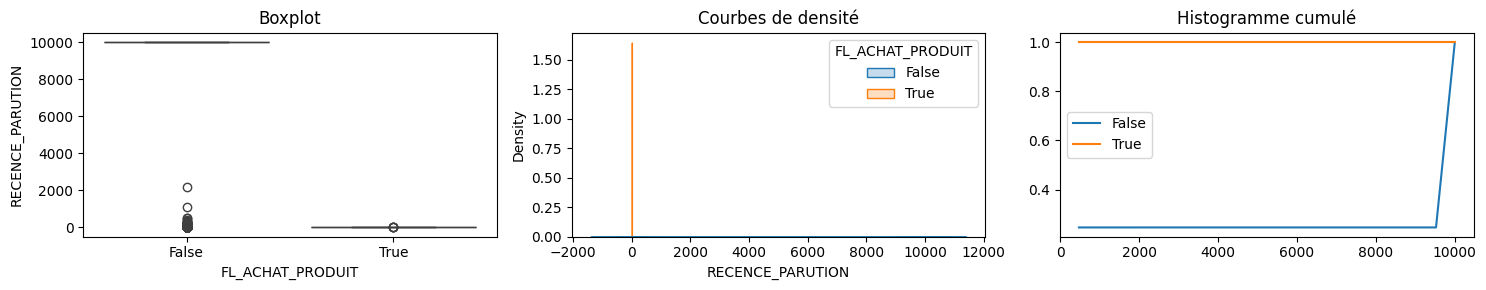

                    count         mean          std  min      25%      50%  \
FL_ACHAT_PRODUIT                                                             
False             64092.0  7536.611948  4308.712384 -1.0  10000.0  10000.0   
True               4384.0    -0.966925     1.120628 -1.0     -1.0     -1.0   

                      75%      max  
FL_ACHAT_PRODUIT                    
False             10000.0  10000.0  
True                 -1.0     49.0  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(7503.25), np.float64(7569.97))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(-1.0), np.float64(-0.93))

Test de Shapiro-Wilk - Stat: 0.5722, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 1432.9255, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 247530307.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: -0.4048, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


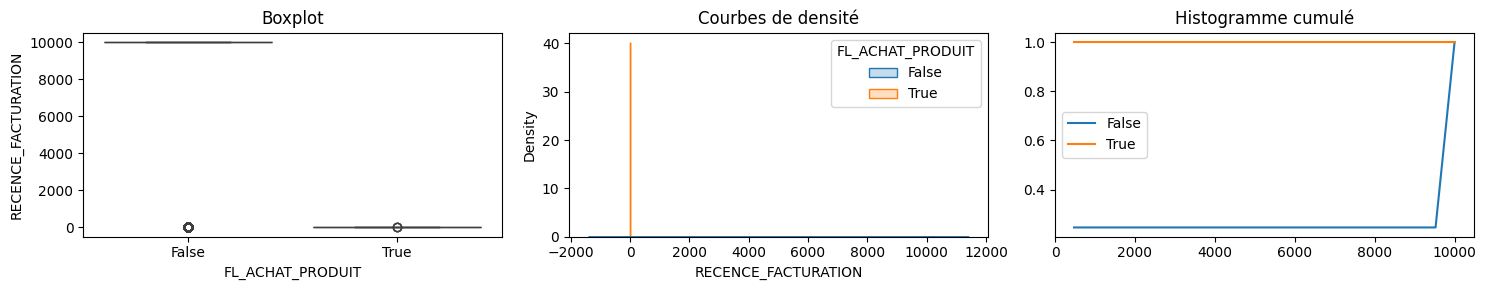

                    count         mean          std  min      25%      50%  \
FL_ACHAT_PRODUIT                                                             
False             64092.0  7536.269222  4309.296504 -1.0  10000.0  10000.0   
True               4384.0    -0.998631     0.052307 -1.0     -1.0     -1.0   

                      75%      max  
FL_ACHAT_PRODUIT                    
False             10000.0  10000.0  
True                 -1.0      1.0  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(7502.91), np.float64(7569.63))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(-1.0), np.float64(-1.0))

Test de Shapiro-Wilk - Stat: 0.5722, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 1432.9726, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 246736332.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: -0.4047, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


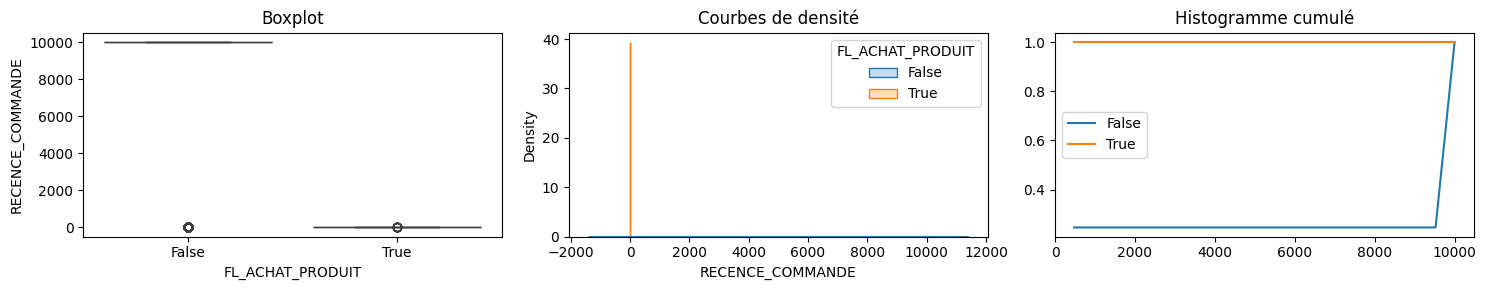

                    count         mean          std  min      25%      50%  \
FL_ACHAT_PRODUIT                                                             
False             64092.0  7536.265961  4309.302207 -1.0  10000.0  10000.0   
True               4384.0    -0.997263     0.052253 -1.0     -1.0     -1.0   

                      75%      max  
FL_ACHAT_PRODUIT                    
False             10000.0  10000.0  
True                 -1.0      0.0  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(7502.9), np.float64(7569.63))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(-1.0), np.float64(-1.0))

Test de Shapiro-Wilk - Stat: 0.5722, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 1432.9710, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 246597330.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: -0.4047, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-S

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


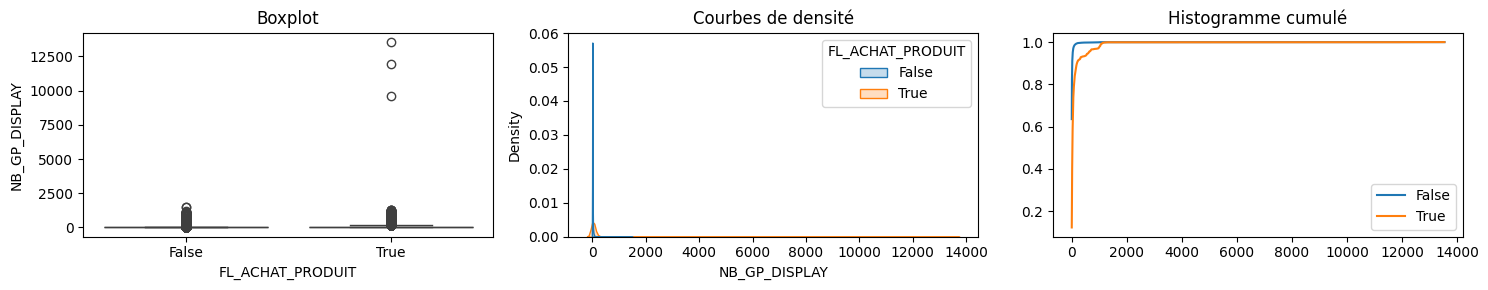

                    count        mean         std  min  25%   50%   75%  \
FL_ACHAT_PRODUIT                                                          
False             64092.0    8.947716   49.244110  0.0  0.0   0.0   4.0   
True               4384.0  100.448221  371.242912  0.0  7.0  22.0  62.0   

                      max  
FL_ACHAT_PRODUIT           
False              1493.0  
True              13542.0  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(8.57), np.float64(9.33))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(89.46), np.float64(111.44))

Test de Shapiro-Wilk - Stat: 0.0914, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 2628.7072, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 45686347.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.2080, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.5692, p-value: 0.0000 → Test signif

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


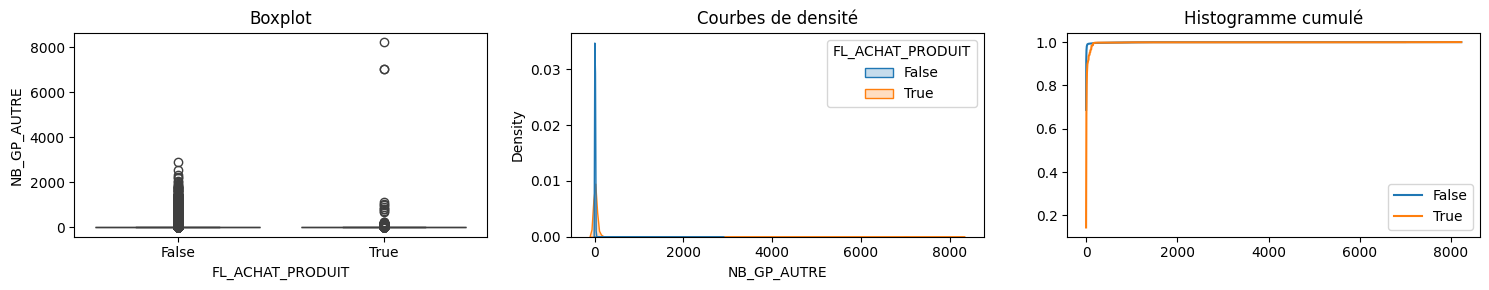

                    count       mean         std  min  25%  50%   75%     max
FL_ACHAT_PRODUIT                                                             
False             64092.0   5.141297   63.238191  0.0  0.0  0.0   1.0  2890.0
True               4384.0  20.158759  199.809906  0.0  2.0  4.0  11.0  8225.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(4.65), np.float64(5.63))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(14.24), np.float64(26.08))

Test de Shapiro-Wilk - Stat: 0.0419, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 116.9993, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 48796388.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0463, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.5556, p-value: 0.0000 → Test significatif à 5%
Statistique KS : 0.5556202768055591
    Distributions significativement différentes
Eta2 : 

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


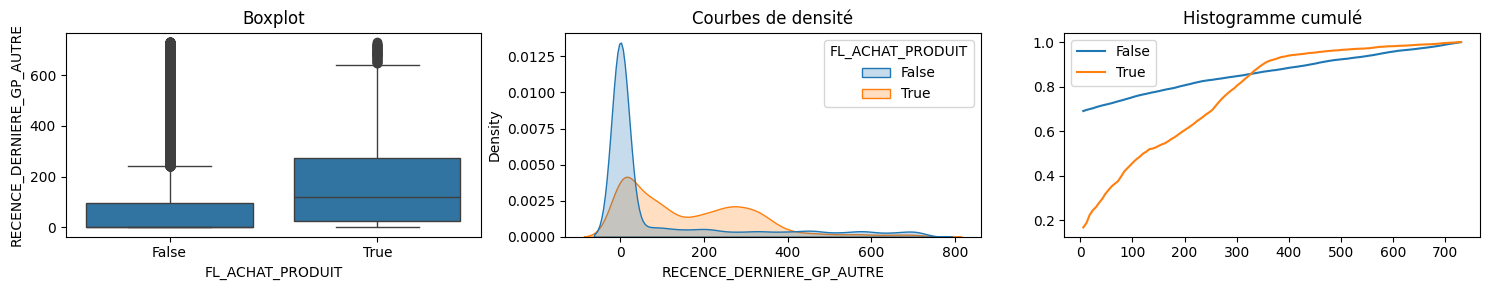

                    count        mean         std  min   25%    50%    75%  \
FL_ACHAT_PRODUIT                                                             
False             64092.0   99.322880  190.489787  0.0   0.0    0.0   97.0   
True               4384.0  165.235173  154.407623  0.0  26.0  121.0  274.0   

                    max  
FL_ACHAT_PRODUIT         
False             730.0  
True              729.0  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(97.85), np.float64(100.8))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(160.66), np.float64(169.81))

Test de Shapiro-Wilk - Stat: 0.6154, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 90.6548, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 76569817.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0853, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.5427, p-value: 0.0000 → Test s

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


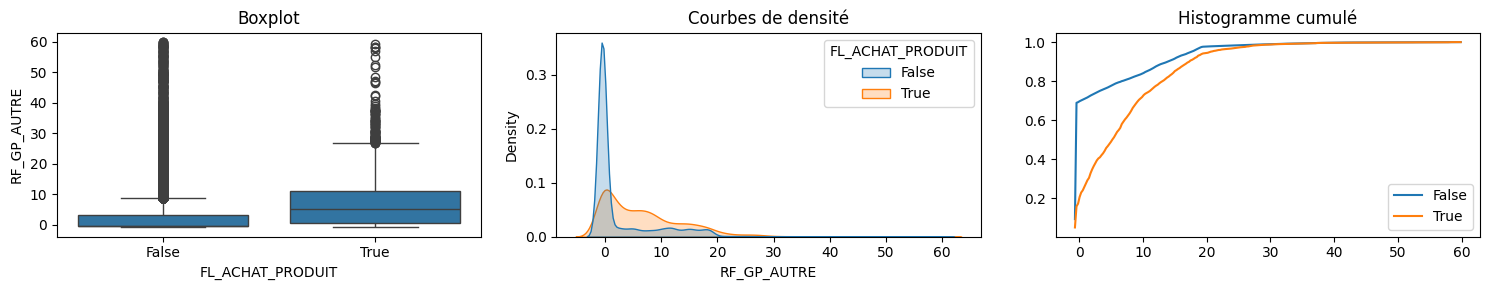

                    count      mean       std       min       25%       50%  \
FL_ACHAT_PRODUIT                                                              
False             64092.0  3.025981  7.010781 -0.916667 -0.459459 -0.459459   
True               4384.0  6.962200  7.674954 -0.916667  0.648649  5.189189   

                        75%        max  
FL_ACHAT_PRODUIT                        
False              3.222222  59.833333  
True              11.108859  59.083333  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(2.97), np.float64(3.08))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(6.73), np.float64(7.19))

Test de Shapiro-Wilk - Stat: 0.6119, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 432.2386, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 76601090.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.1353, p-value: 0.0000 → Test significatif à 5%
Test de 

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


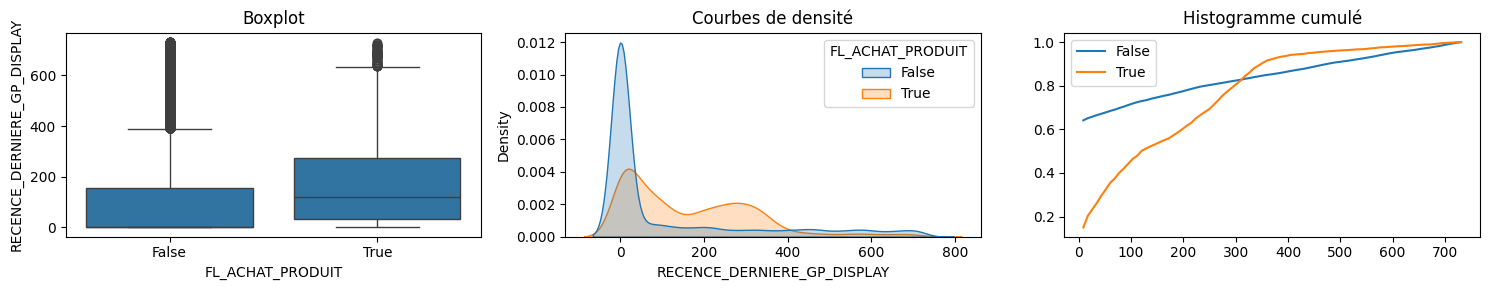

                    count        mean         std  min    25%    50%    75%  \
FL_ACHAT_PRODUIT                                                              
False             64092.0  114.780753  200.494008  0.0   0.00    0.0  156.0   
True               4384.0  165.680885  154.936081  0.0  31.75  119.0  273.0   

                    max  
FL_ACHAT_PRODUIT         
False             731.0  
True              729.0  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(113.23), np.float64(116.33))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(161.09), np.float64(170.27))

Test de Shapiro-Wilk - Stat: 0.6556, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 14.5954, p-value: 0.0001 → Test significatif à 5%
Test de Mann-Whitney - Stat: 83325619.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0628, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.5128, p-value: 0.0000 → 

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


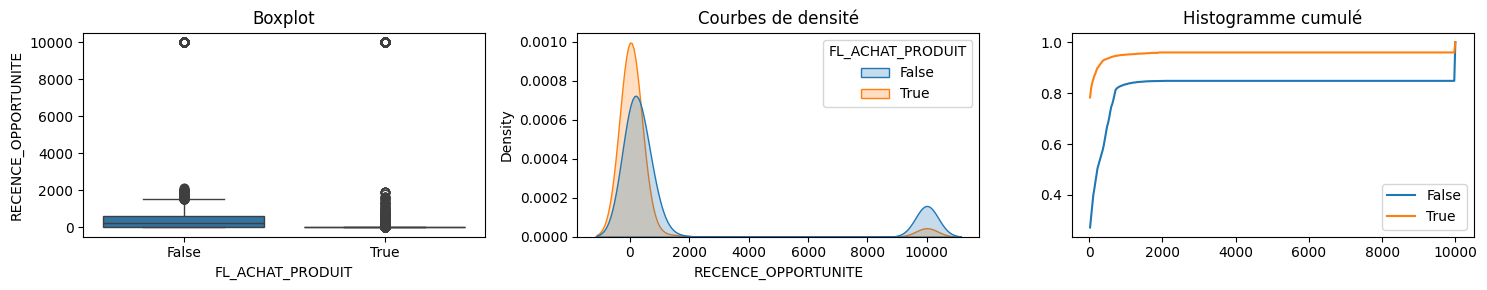

                    count         mean          std  min   25%    50%    75%  \
FL_ACHAT_PRODUIT                                                               
False             64092.0  1733.294421  3511.216439 -1.0  12.0  225.0  615.0   
True               4384.0   453.305201  1971.852562 -1.0  -1.0   -1.0   10.0   

                      max  
FL_ACHAT_PRODUIT           
False             10000.0  
True              10000.0  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(1706.11), np.float64(1760.48))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(394.92), np.float64(511.69))

Test de Shapiro-Wilk - Stat: 0.4787, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 547.0449, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 219263696.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: -0.0909, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.5108, p

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


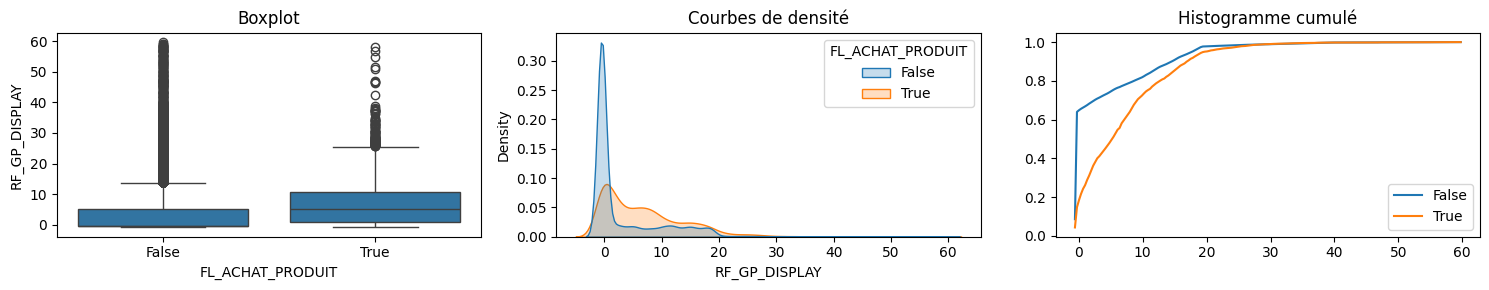

                    count      mean       std       min       25%       50%  \
FL_ACHAT_PRODUIT                                                              
False             64092.0  3.436914  7.084470 -0.916667 -0.459459 -0.459459   
True               4384.0  6.848116  7.336988 -0.916667  0.783784  5.189189   

                        75%        max  
FL_ACHAT_PRODUIT                        
False              5.243243  59.750000  
True              10.724099  58.166667  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(3.38), np.float64(3.49))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(6.63), np.float64(7.07))

Test de Shapiro-Wilk - Stat: 0.6560, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 232.0230, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 80949279.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.1168, p-value: 0.0000 → Test significatif à 5%
Test de 

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


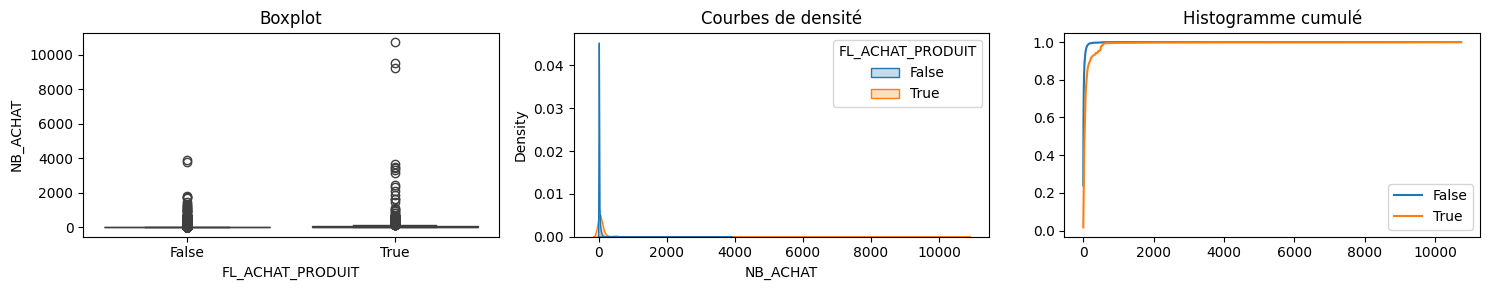

                    count       mean         std  min   25%   50%   75%  \
FL_ACHAT_PRODUIT                                                          
False             64092.0  16.643076   48.468479  1.0   2.0   5.0  15.0   
True               4384.0  90.319571  314.456739  1.0  15.0  35.0  76.0   

                      max  
FL_ACHAT_PRODUIT           
False              3915.0  
True              10745.0  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(16.27), np.float64(17.02))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(81.01), np.float64(99.63))

Test de Shapiro-Wilk - Stat: 0.1361, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 1784.5270, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 50676772.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.1917, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.5011, p-value: 0.0000 → Test signi

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


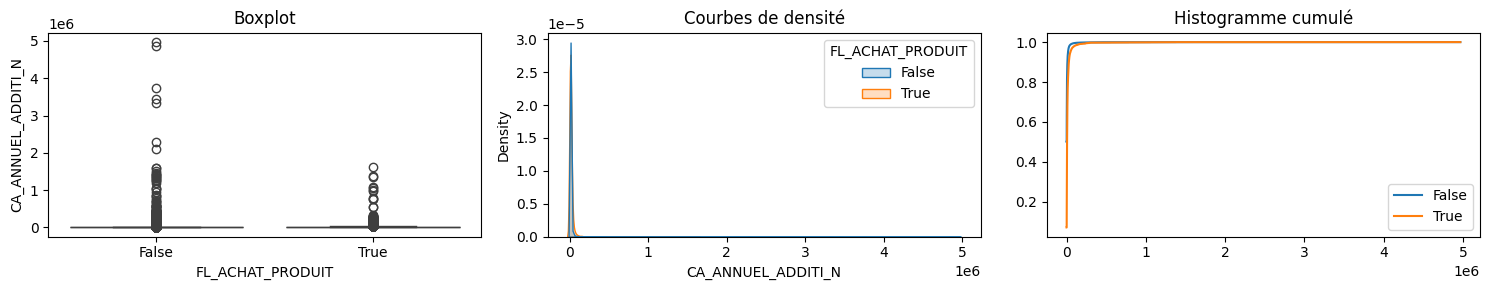

                    count          mean           std  min      25%     50%  \
FL_ACHAT_PRODUIT                                                              
False             64092.0   5568.017365  48746.826431  0.0     0.00     0.0   
True               4384.0  16161.480080  59852.041663  0.0  2938.37  6182.2   

                        75%         max  
FL_ACHAT_PRODUIT                         
False              4063.400  4967271.14  
True              13317.685  1621954.74  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(5190.62), np.float64(5945.42))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(14389.28), np.float64(17933.68))

Test de Shapiro-Wilk - Stat: 0.0625, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 97.9557, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 63252259.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0523, p-value: 0.0000 → Test significa

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


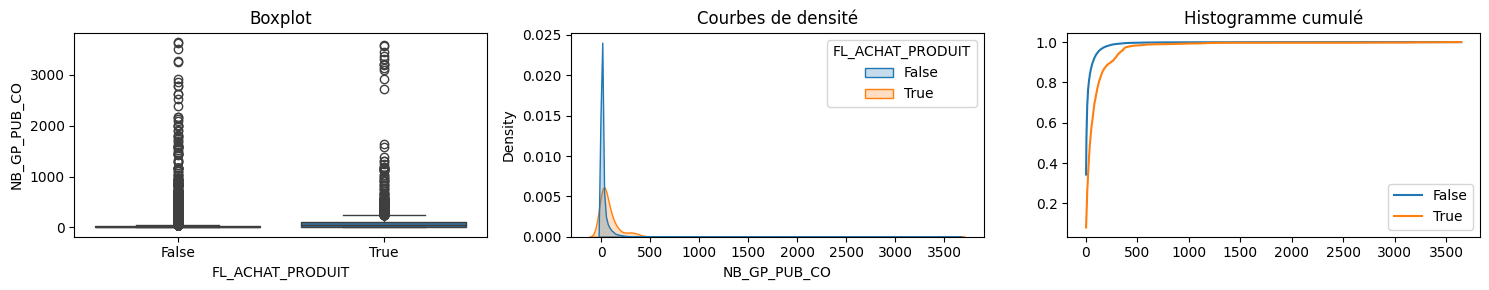

                    count       mean         std  min   25%   50%    75%  \
FL_ACHAT_PRODUIT                                                           
False             64092.0  25.180725   82.857047  0.0   0.0   4.0   19.0   
True               4384.0  93.724681  212.376029  0.0  12.0  39.0  103.0   

                     max  
FL_ACHAT_PRODUIT          
False             3647.0  
True              3589.0  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(24.54), np.float64(25.82))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(87.44), np.float64(100.01))

Test de Shapiro-Wilk - Stat: 0.2611, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 1386.5539, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 65082415.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.1713, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.4278, p-value: 0.0000 → Test sign

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


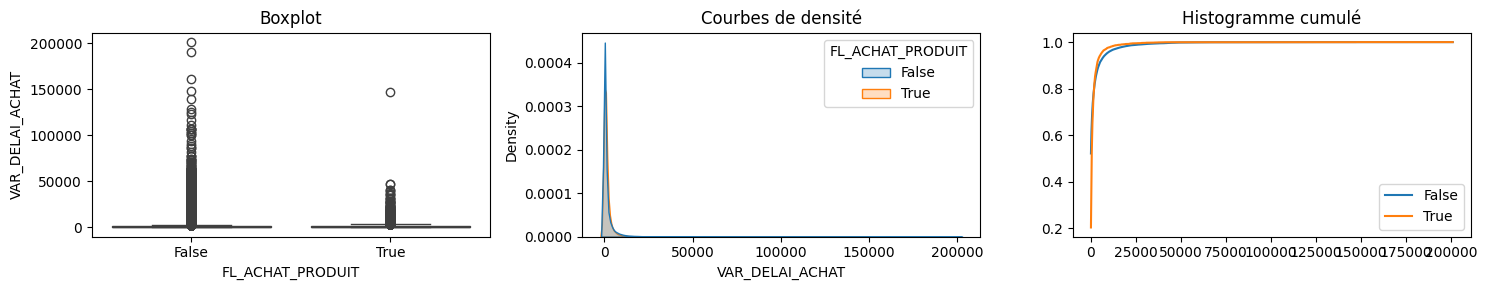

                    count         mean          std  min         25%  \
FL_ACHAT_PRODUIT                                                       
False             64092.0  1795.660319  5623.069551 -1.0    0.000000   
True               4384.0  1471.778801  4005.363373 -1.0  117.699042   

                         50%          75%            max  
FL_ACHAT_PRODUIT                                          
False              22.153846  1171.219663  200978.000000  
True              465.355517  1353.779313  147408.333333  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(1752.13), np.float64(1839.19))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(1353.18), np.float64(1590.38))

Test de Shapiro-Wilk - Stat: 0.3288, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 30.3966, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 98523816.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: -0

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


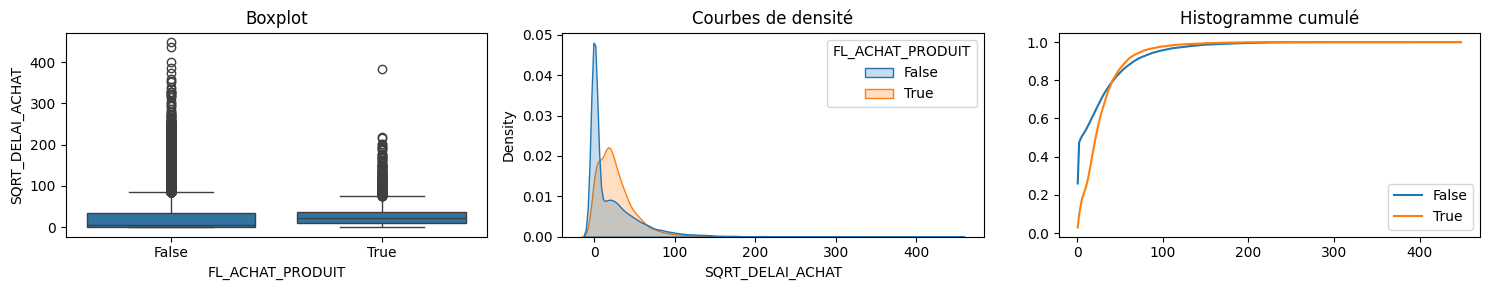

                    count       mean        std  min        25%        50%  \
FL_ACHAT_PRODUIT                                                             
False             64092.0  22.892547  35.669078 -1.0   0.333333   4.706787   
True               4384.0  27.698641  26.548282 -1.0  10.848919  21.572099   

                        75%         max  
FL_ACHAT_PRODUIT                         
False             34.223087  448.305699  
True              36.793740  383.937929  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(22.62), np.float64(23.17))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(26.91), np.float64(28.48))

Test de Shapiro-Wilk - Stat: 0.7073, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 105.9992, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 99081103.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0334, p-value: 0.0000 → Test significatif à 5%
Test

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


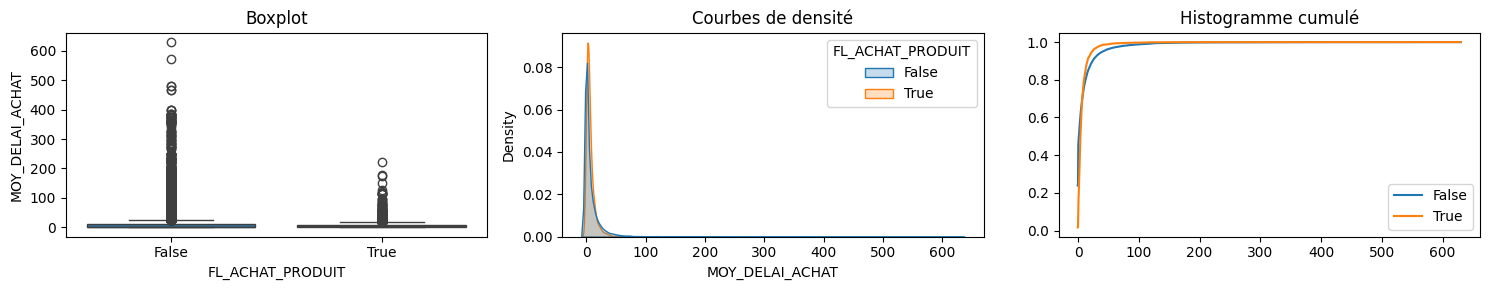

                    count      mean        std  min       25%       50%  \
FL_ACHAT_PRODUIT                                                          
False             64092.0  8.897503  22.725945 -1.0  0.000000  1.305556   
True               4384.0  6.974953  11.417131 -1.0  1.685393  3.937500   

                       75%         max  
FL_ACHAT_PRODUIT                        
False             9.166667  630.000000  
True              8.131548  221.666667  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(8.72), np.float64(9.07))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(6.64), np.float64(7.31))

Test de Shapiro-Wilk - Stat: 0.4262, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 138.3525, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 106788402.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: -0.0212, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smi

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


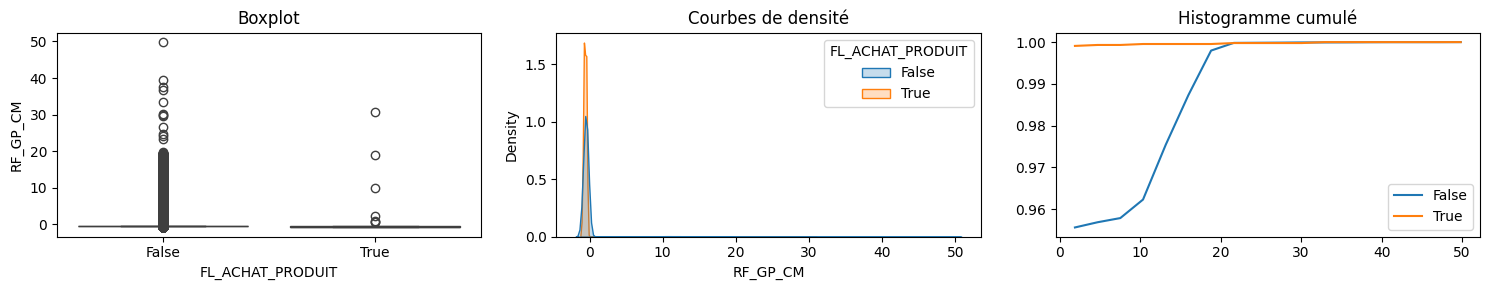

                    count      mean       std       min       25%       50%  \
FL_ACHAT_PRODUIT                                                              
False             64092.0  0.110070  3.036402 -0.916667 -0.459459 -0.459459   
True               4384.0 -0.617765  0.605556 -0.916667 -0.722222 -0.722222   

                       75%        max  
FL_ACHAT_PRODUIT                       
False            -0.459459  49.833333  
True             -0.459459  30.722222  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(0.09), np.float64(0.13))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(-0.64), np.float64(-0.6))

Test de Shapiro-Wilk - Stat: 0.2288, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 140.1615, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 195294275.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: -0.0605, p-value: 0.0000 → Test significatif à 5%
Test de K

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


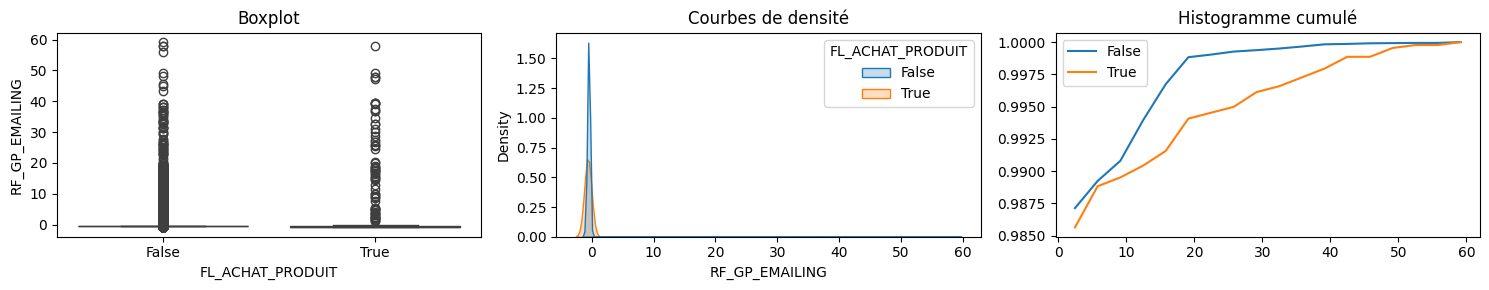

                    count      mean       std       min       25%       50%  \
FL_ACHAT_PRODUIT                                                              
False             64092.0 -0.342480  1.767987 -0.916667 -0.459459 -0.459459   
True               4384.0 -0.323163  3.041490 -0.916667 -0.722222 -0.722222   

                       75%        max  
FL_ACHAT_PRODUIT                       
False            -0.459459  59.166667  
True             -0.459459  57.916667  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(-0.36), np.float64(-0.33))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(-0.41), np.float64(-0.23))

Test de Shapiro-Wilk - Stat: 0.1040, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 51.0165, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 190348849.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0025, p-value: 0.5094 → Test non significatif à 5%
Test

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


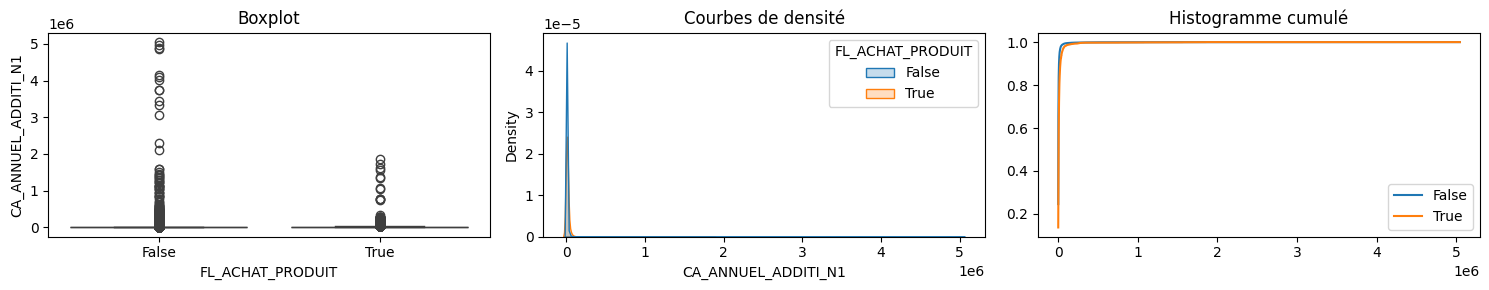

                    count          mean           std  min        25%  \
FL_ACHAT_PRODUIT                                                        
False             64092.0   6072.004640  66490.285021  0.0   190.0000   
True               4384.0  14862.194427  71209.431950  0.0  1518.7325   

                      50%        75%         max  
FL_ACHAT_PRODUIT                                  
False              989.00   3598.895  5045274.39  
True              4459.13  11646.145  1857839.29  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(5557.24), np.float64(6586.77))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(12753.71), np.float64(16970.68))

Test de Shapiro-Wilk - Stat: 0.0446, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 50.7876, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 85689600.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0322, p-value: 0.0000 → Te

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


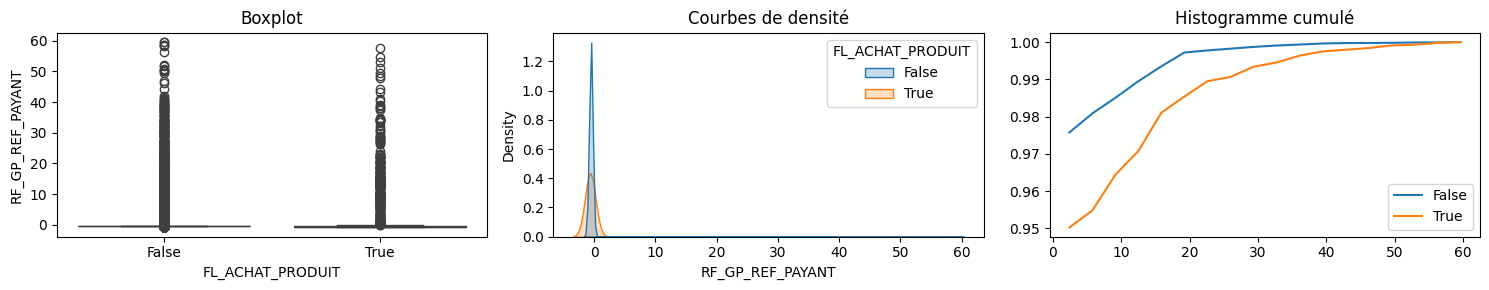

                    count      mean       std       min       25%       50%  \
FL_ACHAT_PRODUIT                                                              
False             64092.0 -0.189478  2.435981 -0.916667 -0.459459 -0.459459   
True               4384.0  0.250209  4.528656 -0.916667 -0.722222 -0.722222   

                       75%        max  
FL_ACHAT_PRODUIT                       
False            -0.459459  59.583333  
True             -0.459459  57.500000  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(-0.21), np.float64(-0.17))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(0.12), np.float64(0.38))

Test de Shapiro-Wilk - Stat: 0.1483, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 240.8342, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 183075331.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0410, p-value: 0.0000 → Test significatif à 5%
Test de K

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


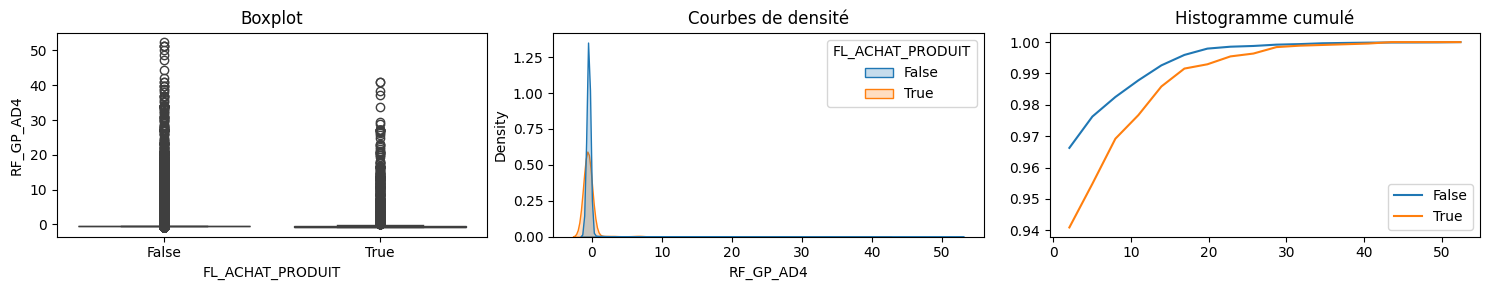

                    count      mean       std       min       25%       50%  \
FL_ACHAT_PRODUIT                                                              
False             64092.0 -0.147530  2.272803 -0.916667 -0.459459 -0.459459   
True               4384.0  0.057503  3.221214 -0.916667 -0.722222 -0.722222   

                       75%        max  
FL_ACHAT_PRODUIT                       
False            -0.459459  52.416667  
True             -0.459459  41.000000  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(-0.17), np.float64(-0.13))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(-0.04), np.float64(0.15))

Test de Shapiro-Wilk - Stat: 0.1884, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 122.9932, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 181812010.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0214, p-value: 0.0000 → Test significatif à 5%
Test de 

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


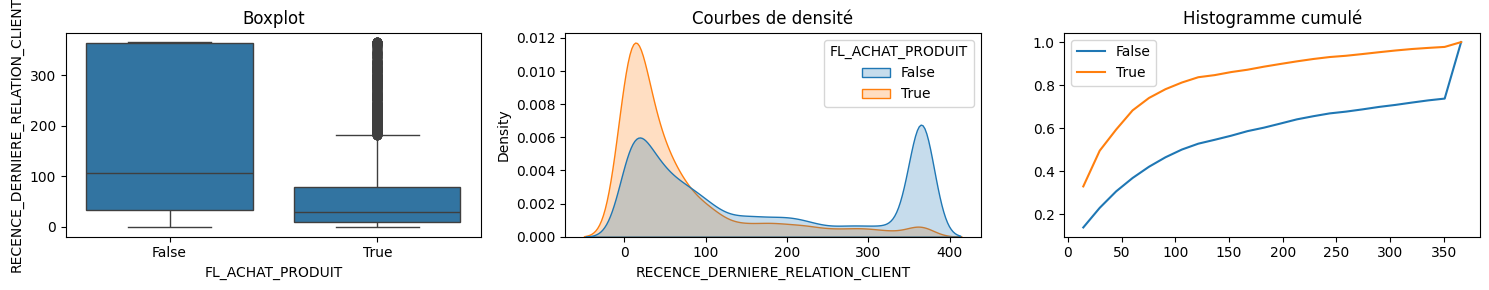

                    count        mean         std  min   25%    50%    75%  \
FL_ACHAT_PRODUIT                                                             
False             64092.0  164.124867  142.775499 -1.0  33.0  106.0  365.0   
True               4384.0   65.610173   86.791979 -1.0  10.0   30.0   79.0   

                    max  
FL_ACHAT_PRODUIT         
False             366.0  
True              366.0  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(163.02), np.float64(165.23))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(63.04), np.float64(68.18))

Test de Shapiro-Wilk - Stat: 0.8182, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 2564.3697, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 201232984.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: -0.1699, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.3217, p-value: 0.0000 → Te

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


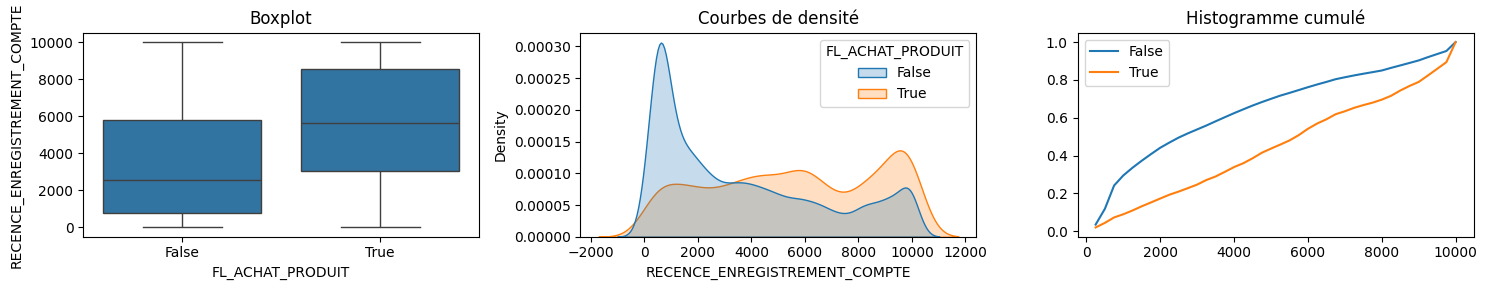

                    count         mean          std   min     25%     50%  \
FL_ACHAT_PRODUIT                                                            
False             64092.0  3591.021266  3111.411579   2.0   786.0  2549.0   
True               4384.0  5587.938412  3098.851888  16.0  3034.0  5663.0   

                      75%      max  
FL_ACHAT_PRODUIT                    
False             5794.25  10000.0  
True              8535.25  10000.0  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(3566.93), np.float64(3615.11))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(5496.18), np.float64(5679.69))

Test de Shapiro-Wilk - Stat: 0.8810, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 10.8102, p-value: 0.0010 → Test significatif à 5%
Test de Mann-Whitney - Stat: 89513294.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.1552, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Sm

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


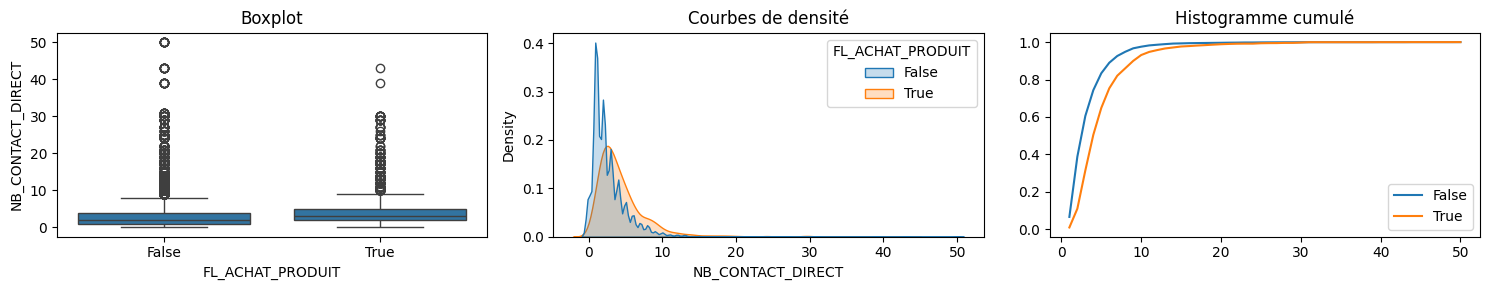

                    count      mean       std  min  25%  50%  75%   max
FL_ACHAT_PRODUIT                                                       
False             64092.0  2.762513  2.801456  0.0  1.0  2.0  4.0  50.0
True               4384.0  4.481068  3.788994  0.0  2.0  3.0  5.0  43.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(2.74), np.float64(2.78))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(4.37), np.float64(4.59))

Test de Shapiro-Wilk - Stat: 0.6932, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 314.2804, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 86664867.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.1448, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.2915, p-value: 0.0000 → Test significatif à 5%
Statistique KS : 0.29151115344684714
     Distributions modérément différentes
Eta2 : 1.2410352414388604e-06
    Rela

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


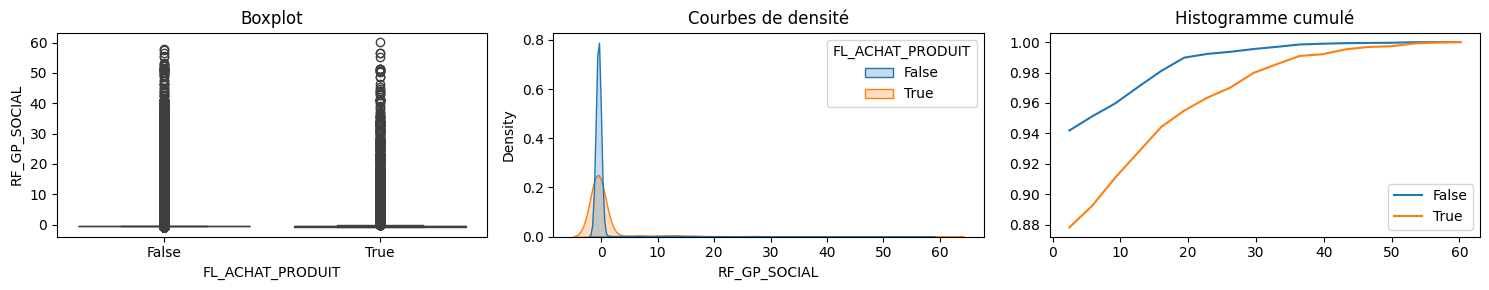

                    count      mean       std       min       25%       50%  \
FL_ACHAT_PRODUIT                                                              
False             64092.0  0.354745  4.063541 -0.916667 -0.459459 -0.459459   
True               4384.0  1.673193  7.329303 -0.916667 -0.722222 -0.459459   

                       75%        max  
FL_ACHAT_PRODUIT                       
False            -0.459459  57.750000  
True             -0.459459  60.166667  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(0.32), np.float64(0.39))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(1.46), np.float64(1.89))

Test de Shapiro-Wilk - Stat: 0.2514, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 488.6803, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 168691932.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0740, p-value: 0.0000 → Test significatif à 5%
Test de Kol

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


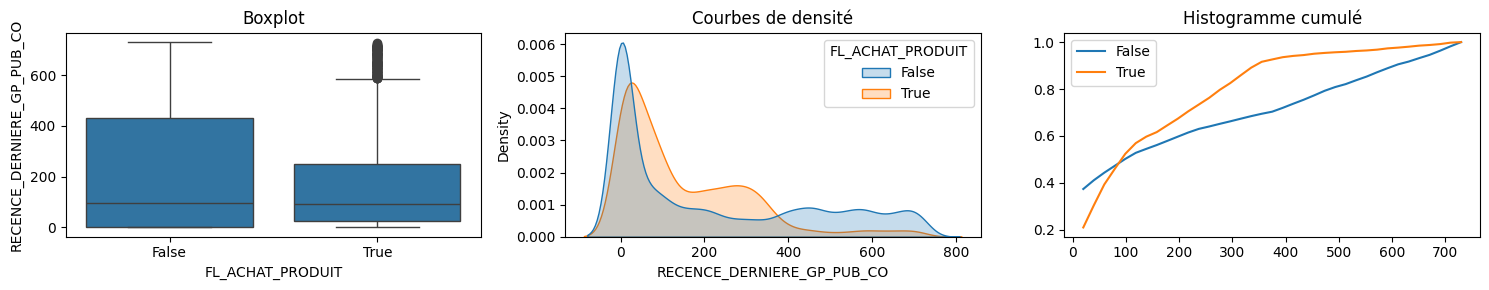

                    count        mean         std  min   25%   50%    75%  \
FL_ACHAT_PRODUIT                                                            
False             64092.0  214.241575  241.426427  0.0   0.0  97.0  430.0   
True               4384.0  150.210766  155.672765  0.0  27.0  91.0  251.0   

                    max  
FL_ACHAT_PRODUIT         
False             730.0  
True              726.0  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(212.37), np.float64(216.11))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(145.6), np.float64(154.82))

Test de Shapiro-Wilk - Stat: 0.8183, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 879.4667, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 139234585.0000, p-value: 0.3138 → Test non significatif à 5%
Corrélation point bisériale - Stat: -0.0660, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.2523, p-value: 0.0000 → Te

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


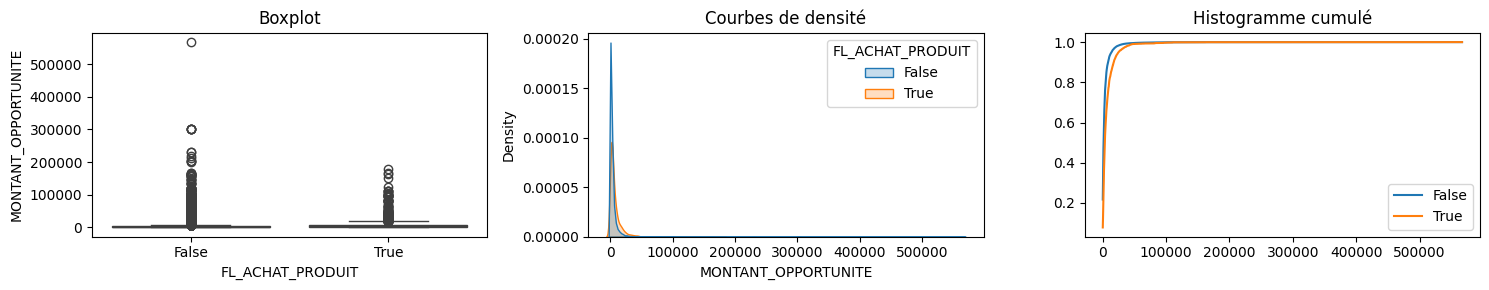

                    count         mean           std  min      25%       50%  \
FL_ACHAT_PRODUIT                                                               
False             64092.0  3540.590391   8536.481680  0.0   285.00  1413.000   
True               4384.0  7127.030646  11759.431882  0.0  1285.01  3329.685   

                        75%        max  
FL_ACHAT_PRODUIT                        
False             3612.9700  567037.00  
True              8411.7425  179381.02  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(3474.5), np.float64(3606.68))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(6778.84), np.float64(7475.22))

Test de Shapiro-Wilk - Stat: 0.3672, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 395.0494, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 92932001.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0995, p-value: 0.0000 → Test significati

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


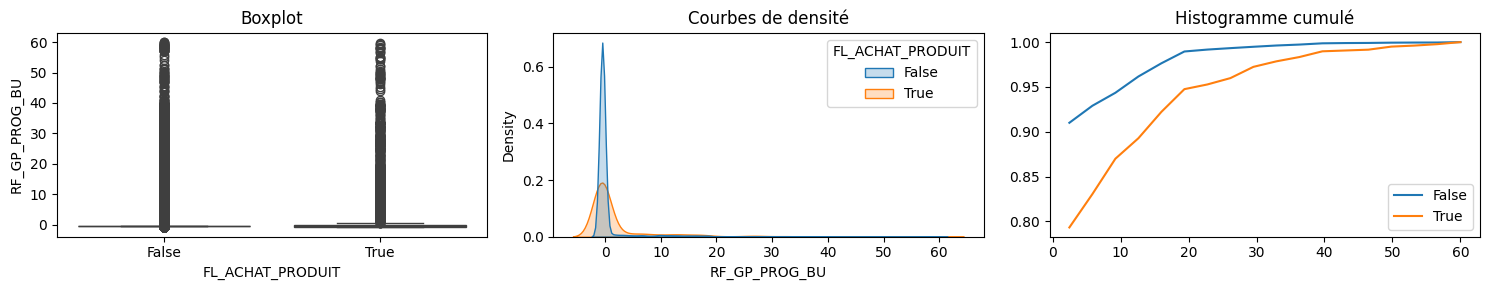

                    count      mean       std       min       25%       50%  \
FL_ACHAT_PRODUIT                                                              
False             64092.0  0.722994  4.619220 -0.916667 -0.459459 -0.459459   
True               4384.0  2.844690  8.664281 -0.916667 -0.722222 -0.459459   

                       75%        max  
FL_ACHAT_PRODUIT                       
False            -0.459459  60.000000  
True             -0.222222  59.583333  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(0.69), np.float64(0.76))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(2.59), np.float64(3.1))

Test de Shapiro-Wilk - Stat: 0.3230, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 861.6599, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 153352709.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.1038, p-value: 0.0000 → Test significatif à 5%
Test de Kolm

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


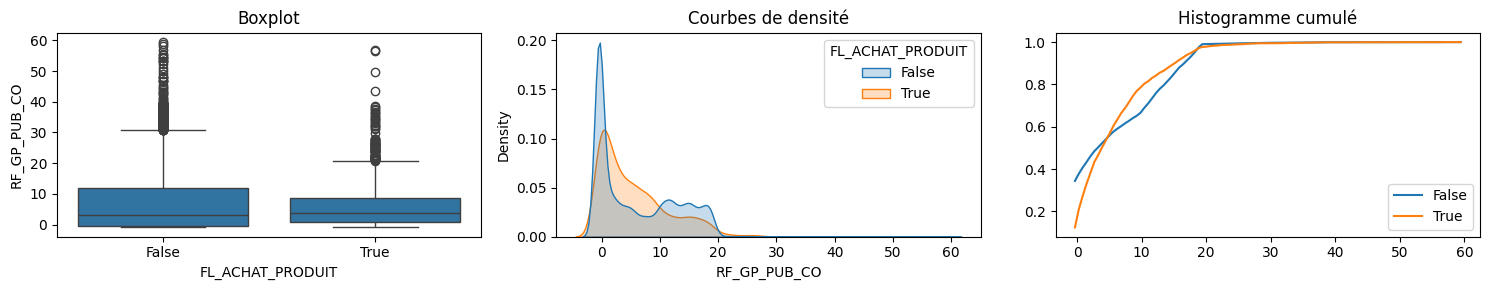

                    count      mean       std       min       25%       50%  \
FL_ACHAT_PRODUIT                                                              
False             64092.0  6.013271  7.062795 -0.916667 -0.459459  3.166667   
True               4384.0  5.665138  6.306140 -0.916667  0.722222  3.833333   

                       75%        max  
FL_ACHAT_PRODUIT                       
False             12.00000  59.416667  
True               8.72973  57.000000  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(5.96), np.float64(6.07))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(5.48), np.float64(5.85))

Test de Shapiro-Wilk - Stat: 0.8436, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 273.8769, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 132592070.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: -0.0121, p-value: 0.0015 → Test significatif à 5%
Test de Ko

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


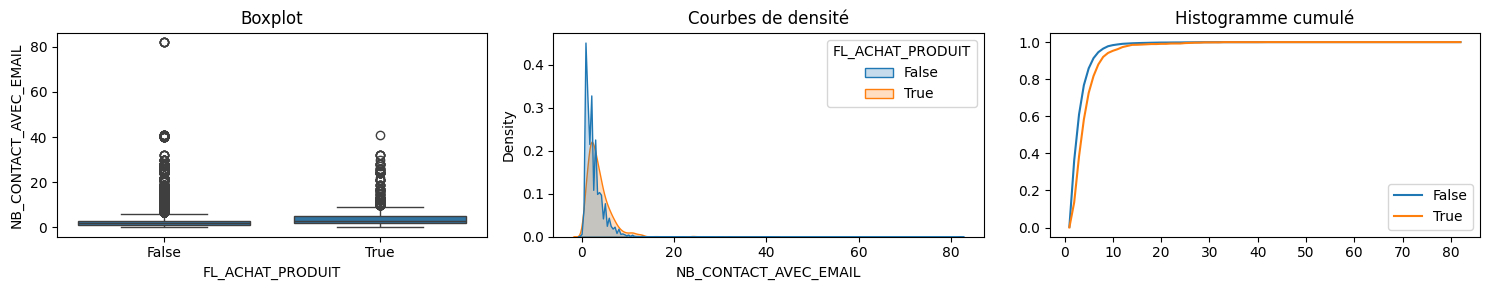

                    count      mean       std  min  25%  50%  75%   max
FL_ACHAT_PRODUIT                                                       
False             64092.0  2.693706  2.520411  0.0  1.0  2.0  3.0  82.0
True               4384.0  3.886405  3.320558  0.0  2.0  3.0  5.0  41.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(2.67), np.float64(2.71))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(3.79), np.float64(3.98))

Test de Shapiro-Wilk - Stat: 0.6220, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 205.0224, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 96965924.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.1125, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.2263, p-value: 0.0000 → Test significatif à 5%
Statistique KS : 0.22634873694338115
     Distributions modérément différentes
Eta2 : 7.482214034768686e-07
    Relat

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


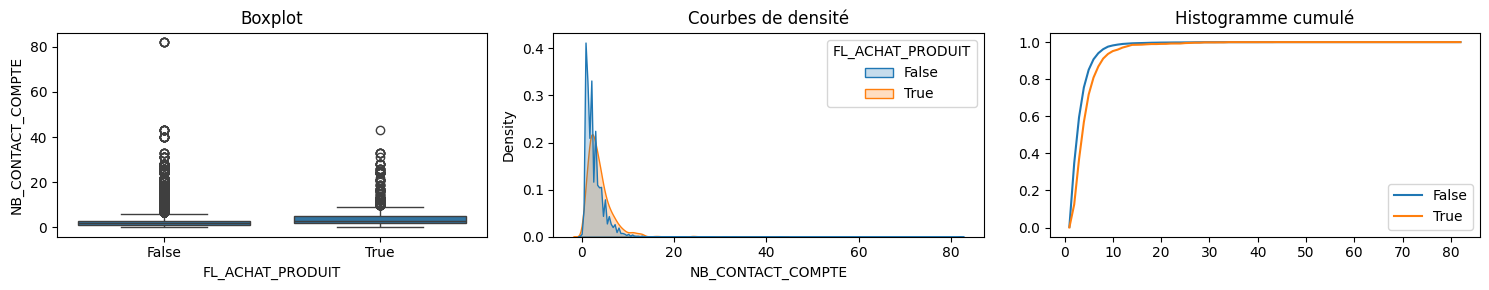

                    count      mean       std  min  25%  50%  75%   max
FL_ACHAT_PRODUIT                                                       
False             64092.0  2.767007  2.573710  0.0  1.0  2.0  3.0  82.0
True               4384.0  3.980383  3.372877  0.0  2.0  3.0  5.0  43.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(2.75), np.float64(2.79))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(3.88), np.float64(4.08))

Test de Shapiro-Wilk - Stat: 0.6296, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 193.6681, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 97074199.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.1121, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.2263, p-value: 0.0000 → Test significatif à 5%
Statistique KS : 0.22626982722373085
     Distributions modérément différentes
Eta2 : 7.476998047594189e-07
    Relat

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


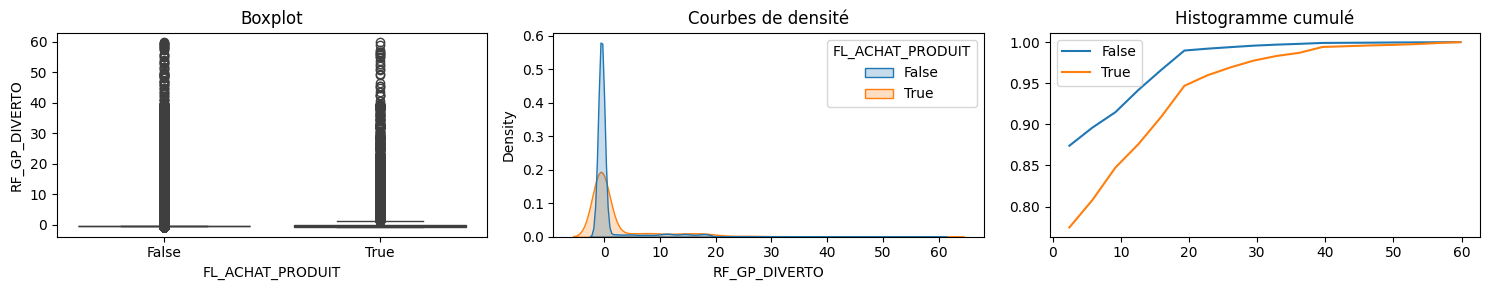

                    count      mean       std       min       25%       50%  \
FL_ACHAT_PRODUIT                                                              
False             64092.0  1.186721  5.101431 -0.916667 -0.459459 -0.459459   
True               4384.0  3.082279  8.359671 -0.916667 -0.722222 -0.459459   

                       75%        max  
FL_ACHAT_PRODUIT                       
False            -0.459459  59.750000  
True              0.000000  59.833333  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(1.15), np.float64(1.23))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(2.83), np.float64(3.33))

Test de Shapiro-Wilk - Stat: 0.4062, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 596.2048, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 154129271.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0861, p-value: 0.0000 → Test significatif à 5%
Test de Kol

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


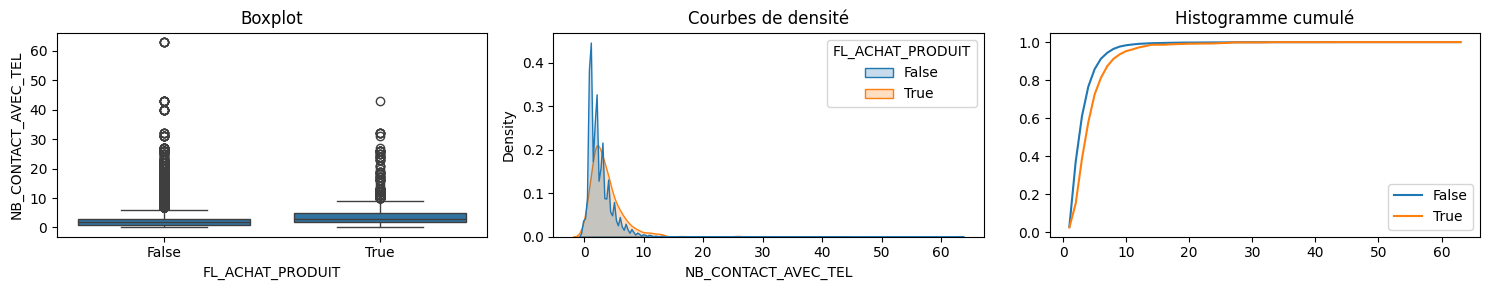

                    count      mean       std  min  25%  50%  75%   max
FL_ACHAT_PRODUIT                                                       
False             64092.0  2.658756  2.503707  0.0  1.0  2.0  3.0  63.0
True               4384.0  3.864735  3.354579  0.0  2.0  3.0  5.0  43.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(2.64), np.float64(2.68))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(3.77), np.float64(3.96))

Test de Shapiro-Wilk - Stat: 0.6647, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 245.7315, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 98612869.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.1143, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.2233, p-value: 0.0000 → Test significatif à 5%
Statistique KS : 0.22329725267191186
     Distributions modérément différentes
Eta2 : 7.281833505037064e-07
    Relat

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


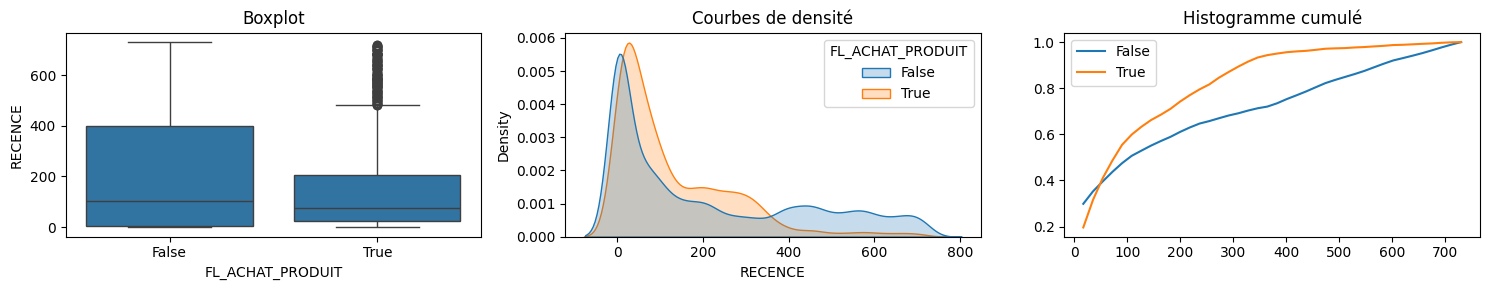

                    count        mean        std  min   25%    50%    75%  \
FL_ACHAT_PRODUIT                                                            
False             64092.0  207.137100  226.36460 -1.0   4.0  104.0  398.0   
True               4384.0  129.275319  137.52875 -1.0  25.0   76.0  207.0   

                    max  
FL_ACHAT_PRODUIT         
False             730.0  
True              720.0  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(205.38), np.float64(208.89))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(125.2), np.float64(133.35))

Test de Shapiro-Wilk - Stat: 0.8340, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 1060.3130, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 148733144.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: -0.0856, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.2231, p-value: 0.0000 → Test 

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


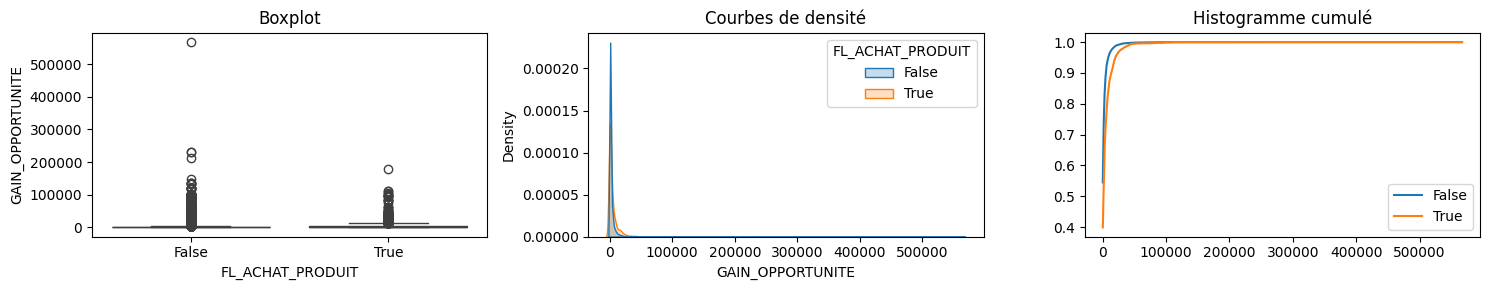

                    count         mean          std  min  25%      50%  \
FL_ACHAT_PRODUIT                                                         
False             64092.0  1875.243593  5976.327405  0.0  0.0     0.00   
True               4384.0  4620.615812  9504.678539  0.0  0.0  1171.21   

                      75%        max  
FL_ACHAT_PRODUIT                      
False             1747.75  567037.00  
True              5178.84  179381.02  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(1828.97), np.float64(1921.51))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(4339.19), np.float64(4902.05))

Test de Shapiro-Wilk - Stat: 0.3102, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 719.5393, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 107845106.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.1067, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smir

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


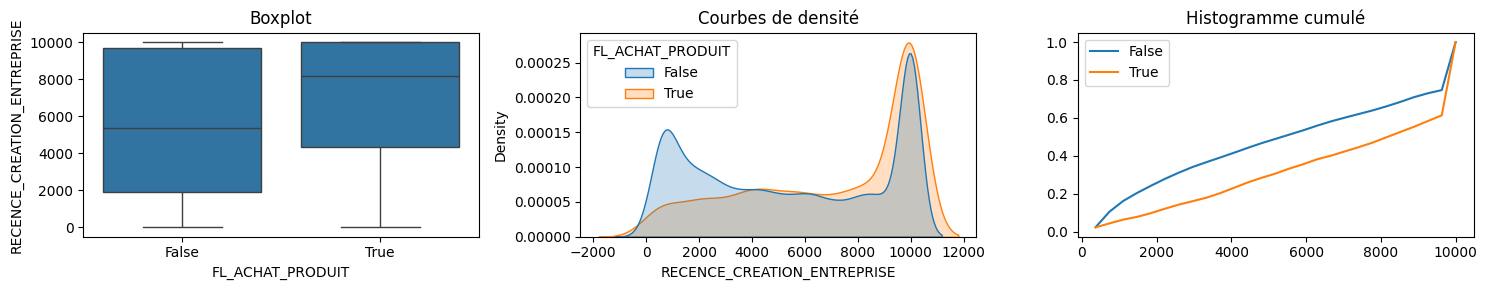

                    count         mean          std  min      25%     50%  \
FL_ACHAT_PRODUIT                                                            
False             64092.0  5482.530737  3590.789003 -1.0  1931.00  5355.0   
True               4384.0  7005.589416  3219.375236 -1.0  4319.75  8165.5   

                      75%      max  
FL_ACHAT_PRODUIT                    
False              9698.0  10000.0  
True              10000.0  10000.0  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(5454.73), np.float64(5510.33))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(6910.26), np.float64(7100.91))

Test de Shapiro-Wilk - Stat: 0.8748, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 439.2767, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 106486418.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.1039, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


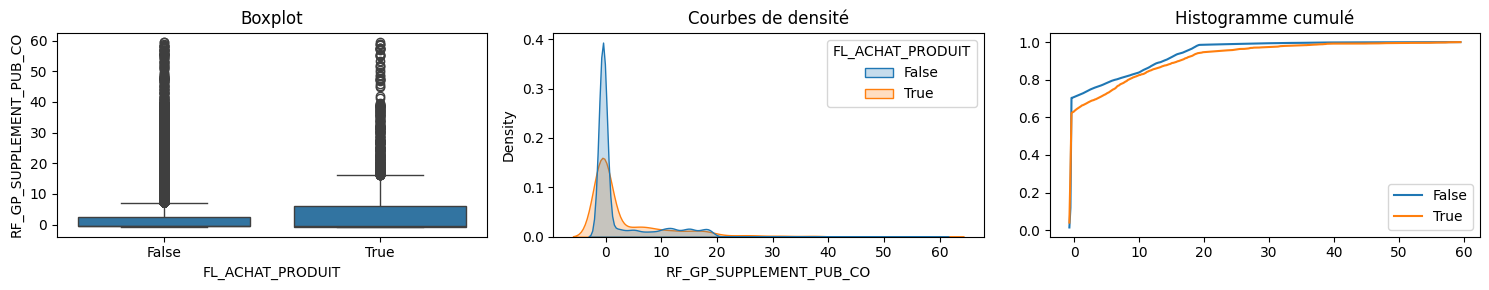

                    count      mean       std       min       25%       50%  \
FL_ACHAT_PRODUIT                                                              
False             64092.0  2.812555  6.549576 -0.916667 -0.459459 -0.459459   
True               4384.0  4.083121  8.851503 -0.916667 -0.722222 -0.459459   

                       75%        max  
FL_ACHAT_PRODUIT                       
False             2.611111  59.500000  
True              6.089527  59.416667  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(2.76), np.float64(2.86))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(3.82), np.float64(4.35))

Test de Shapiro-Wilk - Stat: 0.5889, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 174.8335, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 149132590.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0462, p-value: 0.0000 → Test significatif à 5%
Test de Kol

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


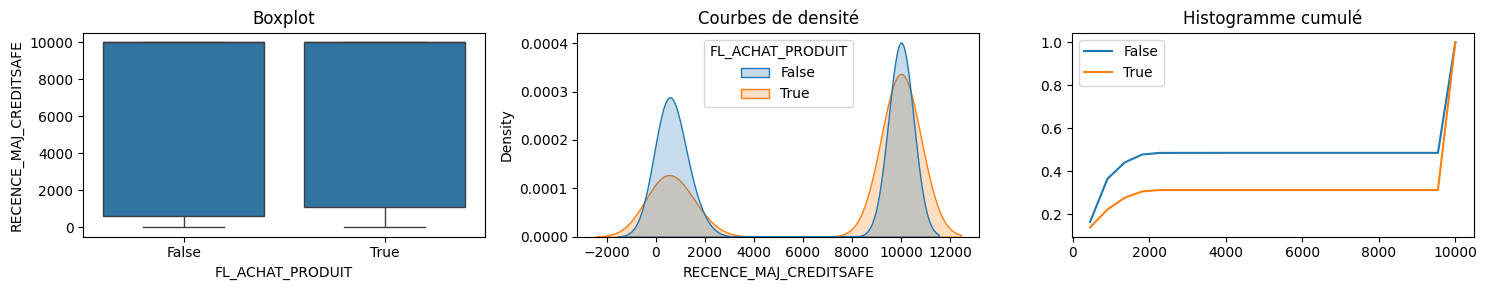

                    count         mean          std  min     25%      50%  \
FL_ACHAT_PRODUIT                                                            
False             64092.0  5469.040567  4677.993798 -1.0   607.0  10000.0   
True               4384.0  7068.285812  4359.033254 -1.0  1097.5  10000.0   

                      75%      max  
FL_ACHAT_PRODUIT                    
False             10000.0  10000.0  
True              10000.0  10000.0  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(5432.82), np.float64(5505.26))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(6939.22), np.float64(7197.36))

Test de Shapiro-Wilk - Stat: 0.6719, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 483.6420, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 117971381.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0837, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


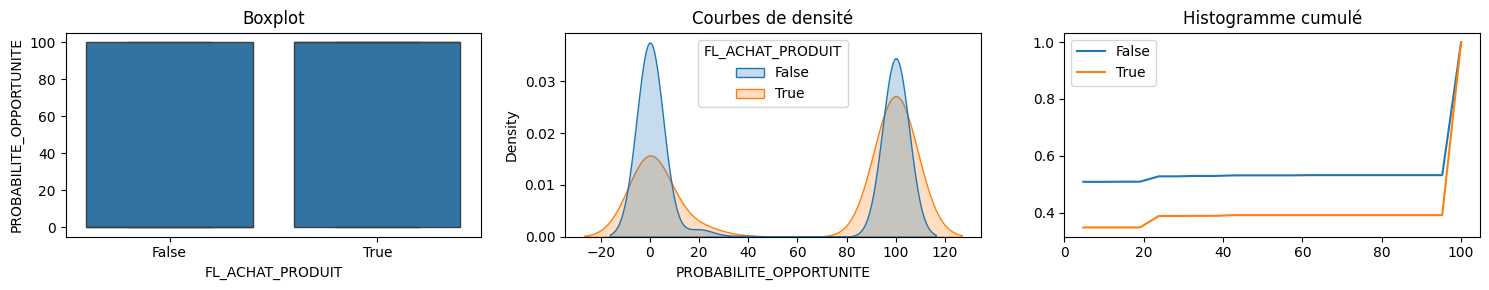

                    count       mean        std  min  25%    50%    75%    max
FL_ACHAT_PRODUIT                                                              
False             64092.0  47.328372  49.524023  0.0  0.0    0.0  100.0  100.0
True               4384.0  61.756387  47.861586  0.0  0.0  100.0  100.0  100.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(46.94), np.float64(47.71))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(60.34), np.float64(63.17))

Test de Shapiro-Wilk - Stat: 0.6468, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 138.6659, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 118807537.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0713, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.1609, p-value: 0.0000 → Test significatif à 5%
Statistique KS : 0.16086226813098503
     Distributions modérément différentes
Eta2 

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


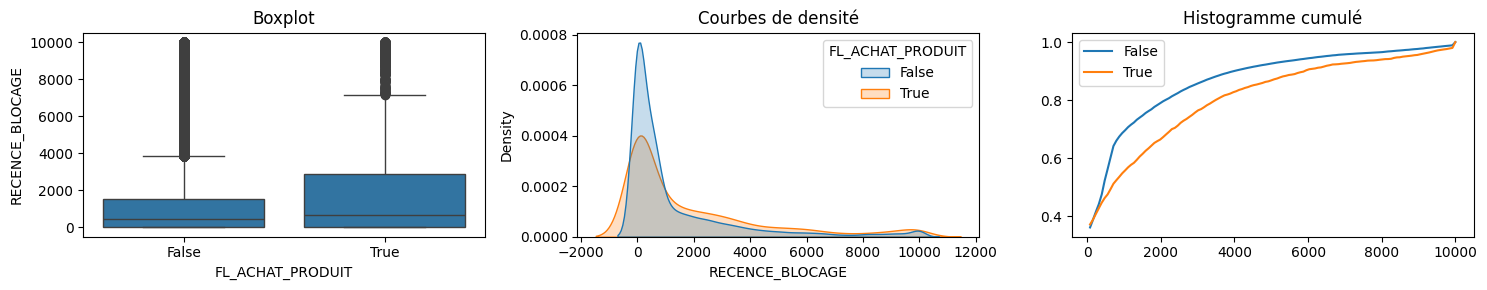

                    count         mean          std  min  25%    50%      75%  \
FL_ACHAT_PRODUIT                                                                
False             64092.0  1299.883355  2149.648295 -1.0 -1.0  441.0  1532.00   
True               4384.0  1902.791515  2631.086512 -1.0 -1.0  667.5  2860.25   

                      max  
FL_ACHAT_PRODUIT           
False             10000.0  
True              10000.0  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(1283.24), np.float64(1316.53))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(1824.89), np.float64(1980.7))

Test de Shapiro-Wilk - Stat: 0.6532, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 358.8984, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 127771845.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0674, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.140

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


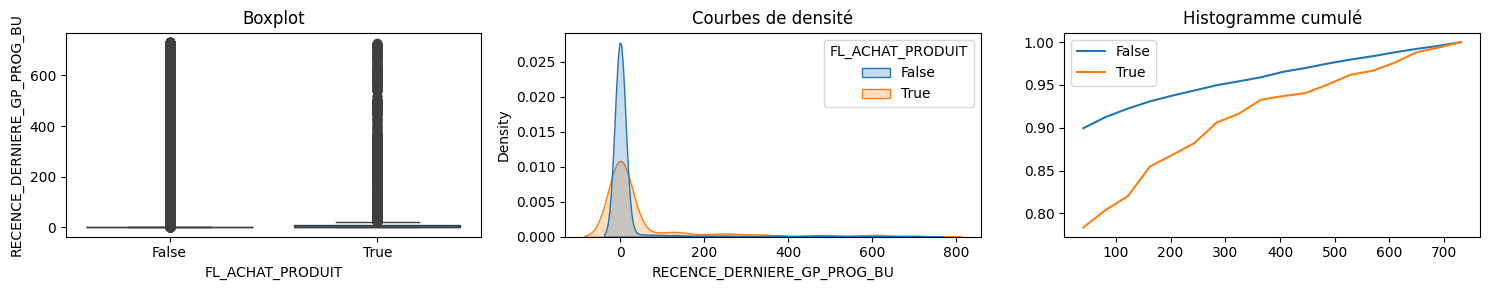

                    count       mean         std  min  25%  50%  75%    max
FL_ACHAT_PRODUIT                                                           
False             64092.0  32.528802  115.940863  0.0  0.0  0.0  0.0  731.0
True               4384.0  66.077555  153.400607  0.0  0.0  0.0  9.0  727.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(31.63), np.float64(33.43))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(61.54), np.float64(70.62))

Test de Shapiro-Wilk - Stat: 0.3276, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 327.8205, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 121393885.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0690, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.1368, p-value: 0.0000 → Test significatif à 5%
Statistique KS : 0.13678721589084308
     Distributions modérément différentes
Eta2 : 2.73253166

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


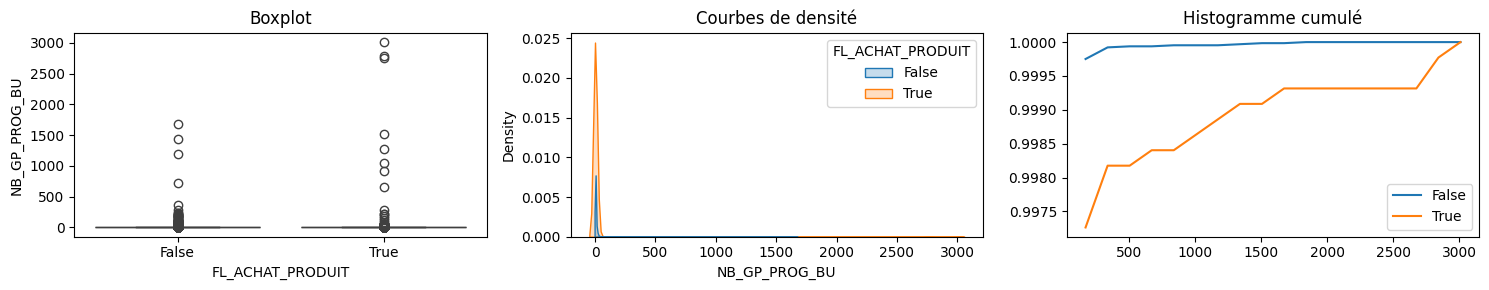

                    count      mean        std  min  25%  50%  75%     max
FL_ACHAT_PRODUIT                                                          
False             64092.0  0.812769  11.437748  0.0  0.0  0.0  0.0  1674.0
True               4384.0  5.212819  84.003779  0.0  0.0  0.0  1.0  3011.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(0.72), np.float64(0.9))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(2.73), np.float64(7.7))

Test de Shapiro-Wilk - Stat: 0.0151, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 138.3670, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 120479617.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0449, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.1365, p-value: 0.0000 → Test significatif à 5%
Statistique KS : 0.13653909799371433
     Distributions modérément différentes
Eta2 : 2.7226275966297923e-

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


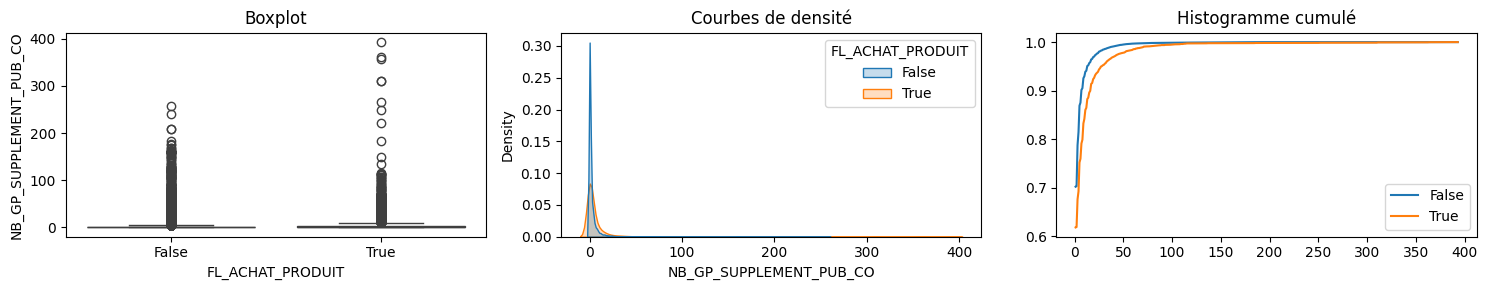

                    count      mean        std  min  25%  50%  75%    max
FL_ACHAT_PRODUIT                                                         
False             64092.0  2.569509   8.411459  0.0  0.0  0.0  2.0  258.0
True               4384.0  5.787181  18.464403  0.0  0.0  0.0  4.0  393.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(2.5), np.float64(2.63))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(5.24), np.float64(6.33))

Test de Shapiro-Wilk - Stat: 0.2953, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 482.5089, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 124311390.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0836, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.1225, p-value: 0.0000 → Test significatif à 5%
Statistique KS : 0.12249173006777203
     Distributions modérément différentes
Eta2 : 2.1912288820905807e-07


c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


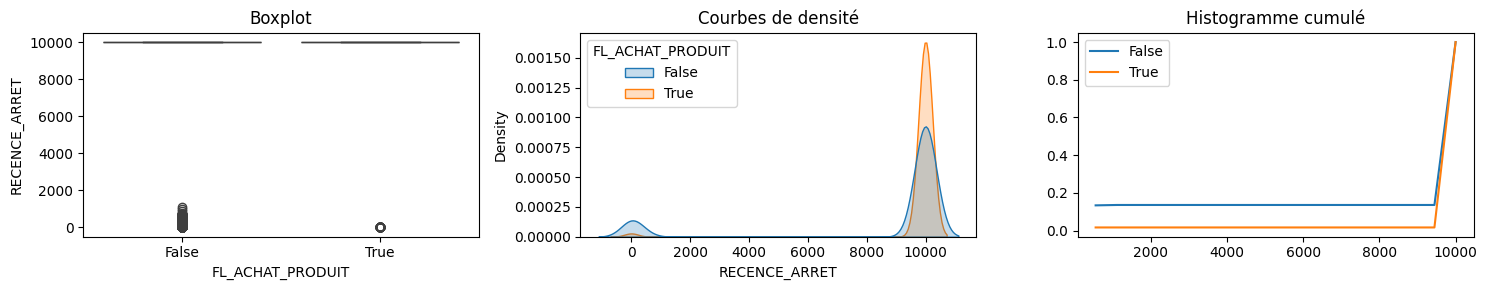

                    count         mean          std  min      25%      50%  \
FL_ACHAT_PRODUIT                                                             
False             64092.0  8649.622387  3405.085228 -1.0  10000.0  10000.0   
True               4384.0  9833.468750  1279.890633 -1.0  10000.0  10000.0   

                      75%      max  
FL_ACHAT_PRODUIT                    
False             10000.0  10000.0  
True              10000.0  10000.0  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(8623.26), np.float64(8675.98))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(9795.57), np.float64(9871.37))

Test de Shapiro-Wilk - Stat: 0.3942, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 524.8357, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 123813713.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0872, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogo

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


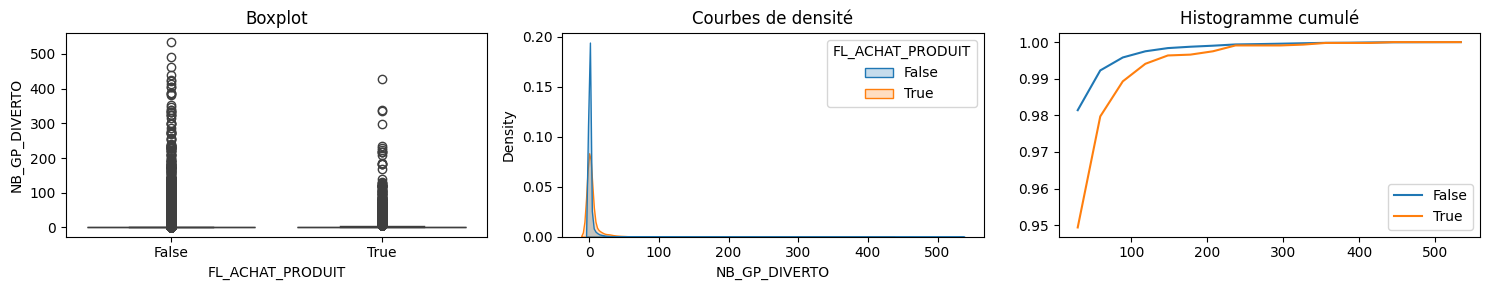

                    count      mean        std  min  25%  50%  75%    max
FL_ACHAT_PRODUIT                                                         
False             64092.0  2.372059  13.805550  0.0  0.0  0.0  0.0  534.0
True               4384.0  5.609033  20.504074  0.0  0.0  0.0  2.0  427.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(2.27), np.float64(2.48))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(5.0), np.float64(6.22))

Test de Shapiro-Wilk - Stat: 0.1642, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 209.4193, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 123507804.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0552, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.1140, p-value: 0.0000 → Test significatif à 5%
Statistique KS : 0.11396301723662738
     Distributions modérément différentes
Eta2 : 1.8967150793445656e-07


c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


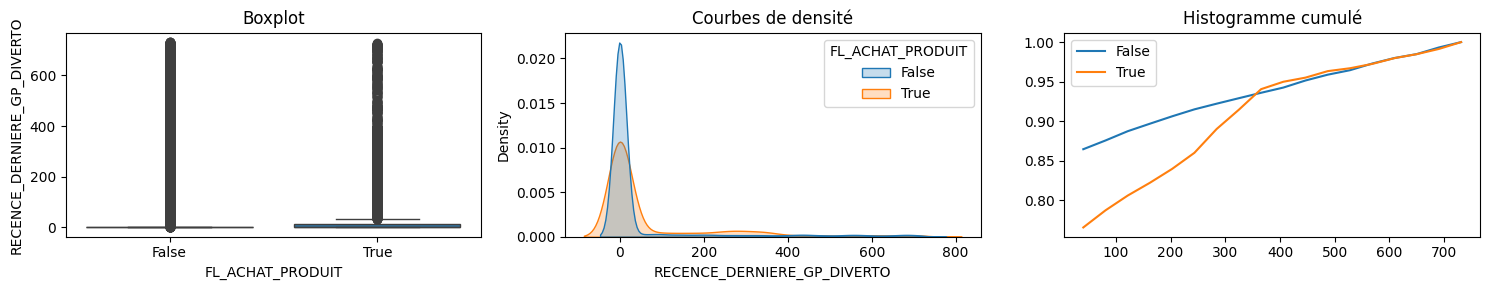

                    count      mean         std  min  25%  50%   75%    max
FL_ACHAT_PRODUIT                                                           
False             64092.0  48.44252  143.193432  0.0  0.0  0.0   0.0  731.0
True               4384.0  70.62021  152.443808  0.0  0.0  0.0  13.0  729.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(47.33), np.float64(49.55))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(66.11), np.float64(75.13))

Test de Shapiro-Wilk - Stat: 0.3967, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 97.5956, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 125278318.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0377, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.1140, p-value: 0.0000 → Test significatif à 5%
Statistique KS : 0.11396301723662738
     Distributions modérément différentes
Eta2 : 1.896715079

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


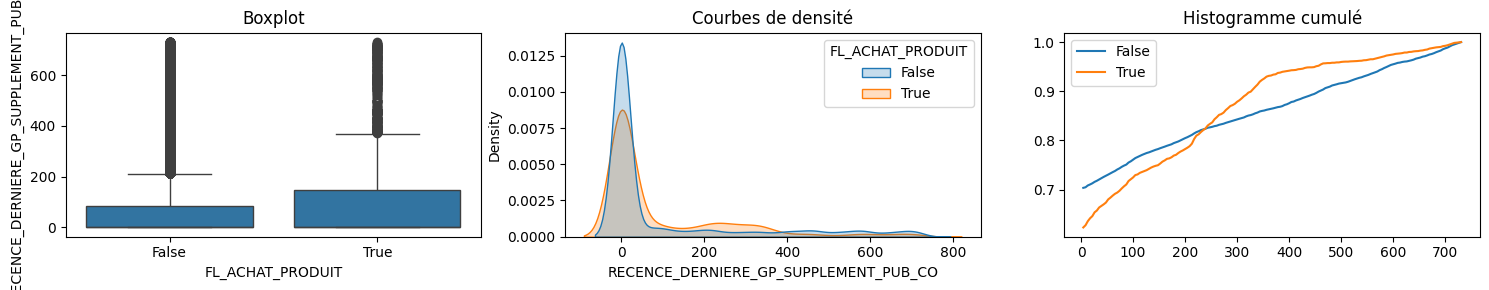

                    count        mean         std  min  25%  50%    75%    max
FL_ACHAT_PRODUIT                                                              
False             64092.0  100.352509  195.008161  0.0  0.0  0.0   85.0  730.0
True               4384.0   92.083485  161.565251  0.0  0.0  0.0  148.0  730.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(98.84), np.float64(101.86))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(87.3), np.float64(96.87))

Test de Shapiro-Wilk - Stat: 0.5830, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 7.5291, p-value: 0.0061 → Test significatif à 5%
Test de Mann-Whitney - Stat: 132620816.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: -0.0105, p-value: 0.0061 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.0840, p-value: 0.0000 → Test significatif à 5%
Statistique KS : 0.08398404312505159
     Distributions quasi-identiques
Eta2 : 1.030

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


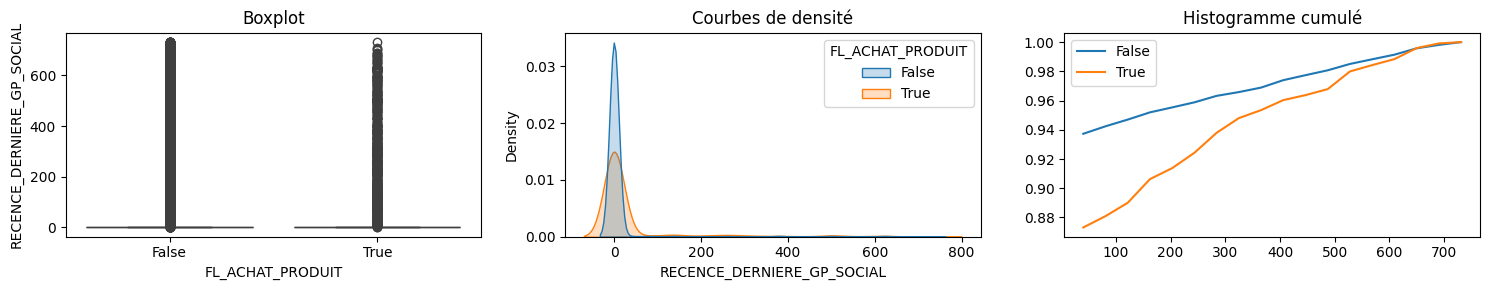

                    count       mean         std  min  25%  50%  75%    max
FL_ACHAT_PRODUIT                                                           
False             64092.0  22.477127   99.383268  0.0  0.0  0.0  0.0  731.0
True               4384.0  40.648038  123.633665  0.0  0.0  0.0  0.0  731.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(21.71), np.float64(23.25))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(36.99), np.float64(44.31))

Test de Shapiro-Wilk - Stat: 0.2484, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 132.5263, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 130261575.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0440, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.0738, p-value: 0.0000 → Test significatif à 5%
Statistique KS : 0.07383758850757882
     Distributions quasi-identiques
Eta2 : 7.96213021368699

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


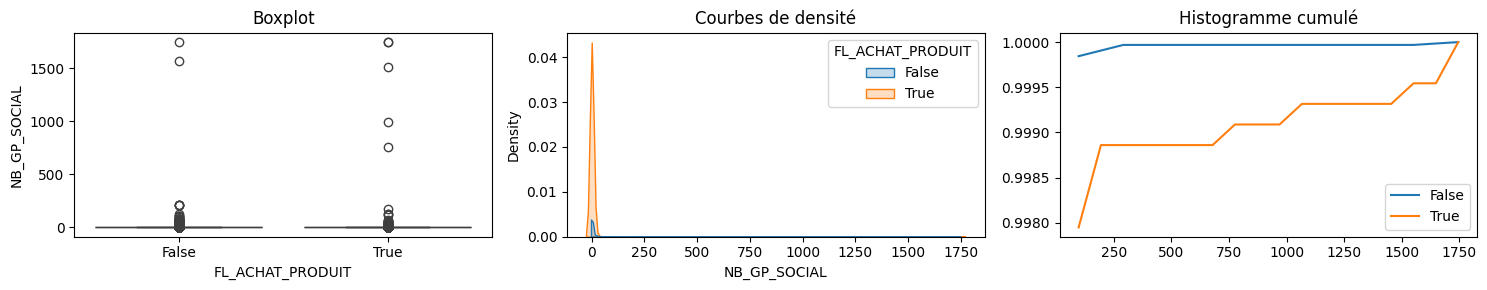

                    count      mean        std  min  25%  50%  75%     max
FL_ACHAT_PRODUIT                                                          
False             64092.0  0.452521   9.826871  0.0  0.0  0.0  0.0  1746.0
True               4384.0  2.504790  47.907465  0.0  0.0  0.0  0.0  1746.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(0.38), np.float64(0.53))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(1.09), np.float64(3.92))

Test de Shapiro-Wilk - Stat: 0.0117, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 72.8305, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 130025149.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0326, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.0736, p-value: 0.0000 → Test significatif à 5%
Statistique KS : 0.07364815108391176
     Distributions quasi-identiques
Eta2 : 7.921327406638901e-08
   

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


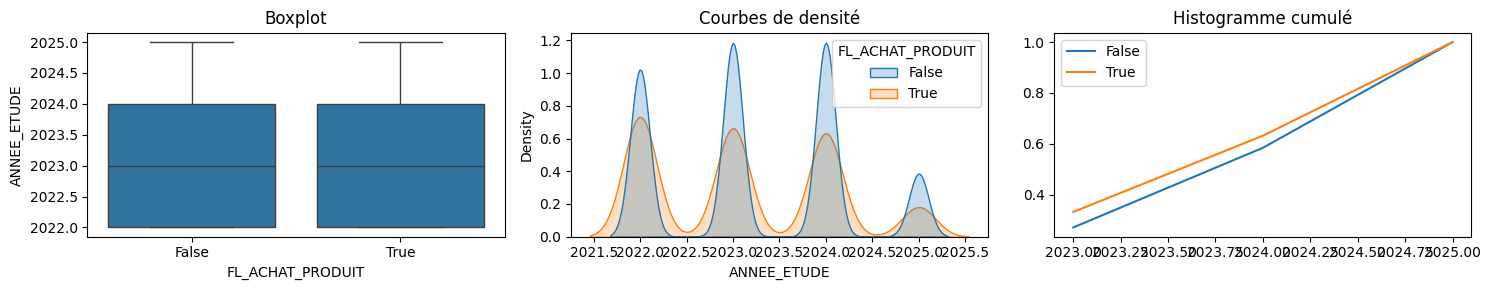

                    count         mean       std     min     25%     50%  \
FL_ACHAT_PRODUIT                                                           
False             64092.0  2023.247706  0.965390  2022.0  2022.0  2023.0   
True               4384.0  2023.118841  0.965653  2022.0  2022.0  2023.0   

                     75%     max  
FL_ACHAT_PRODUIT                  
False             2024.0  2025.0  
True              2024.0  2025.0  

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(2023.24), np.float64(2023.26))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(2023.09), np.float64(2023.15))

Test de Shapiro-Wilk - Stat: 0.8672, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 0.5001, p-value: 0.4794 → Test non significatif à 5%
Test de Mann-Whitney - Stat: 150876809.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: -0.0327, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov -

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


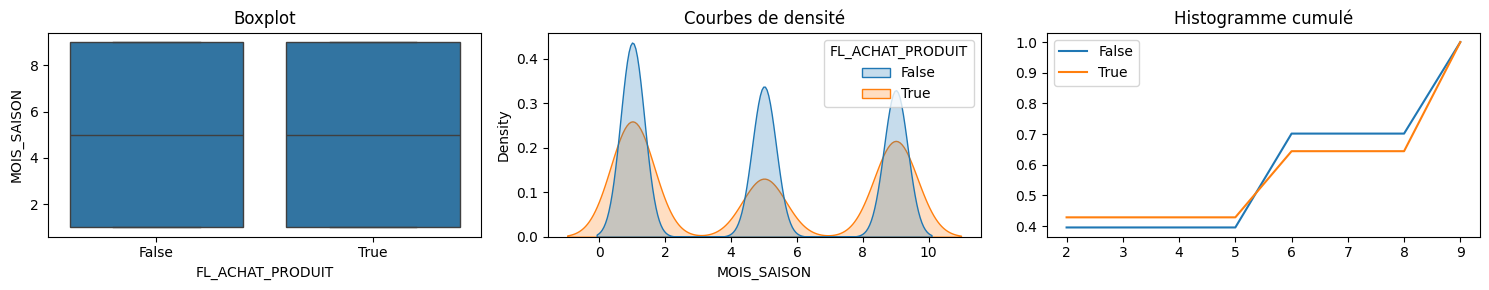

                    count      mean       std  min  25%  50%  75%  max
FL_ACHAT_PRODUIT                                                      
False             64092.0  4.612245  3.309246  1.0  1.0  5.0  9.0  9.0
True               4384.0  4.709854  3.530737  1.0  1.0  5.0  9.0  9.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(4.59), np.float64(4.64))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(4.61), np.float64(4.81))

Test de Shapiro-Wilk - Stat: 0.7813, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 159.8783, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 138866184.0000, p-value: 0.1723 → Test non significatif à 5%
Corrélation point bisériale - Stat: 0.0072, p-value: 0.0600 → Test non significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.0574, p-value: 0.0000 → Test significatif à 5%
Statistique KS : 0.05739343216024784
     Distributions quasi-identiques
Eta2 : 4.8105936511255727e-08
    Relat

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


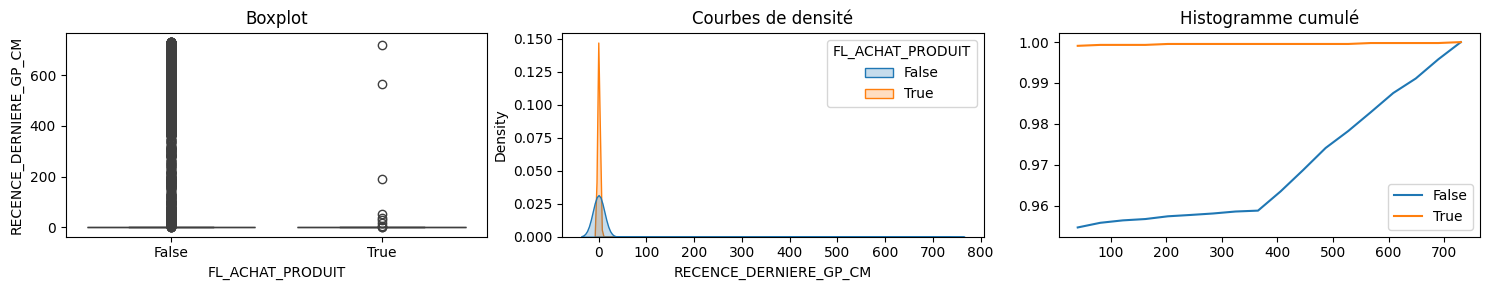

                    count       mean         std  min  25%  50%  75%    max
FL_ACHAT_PRODUIT                                                           
False             64092.0  23.047869  110.343051  0.0  0.0  0.0  0.0  730.0
True               4384.0   0.370666   14.173131  0.0  0.0  0.0  0.0  720.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(22.19), np.float64(23.9))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(-0.05), np.float64(0.79))

Test de Shapiro-Wilk - Stat: 0.2005, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 184.9541, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 146682508.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: -0.0519, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.0445, p-value: 0.0000 → Test significatif à 5%
Statistique KS : 0.04452821525717365
     Distributions quasi-identiques
Eta2 : 2.895641990500781

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


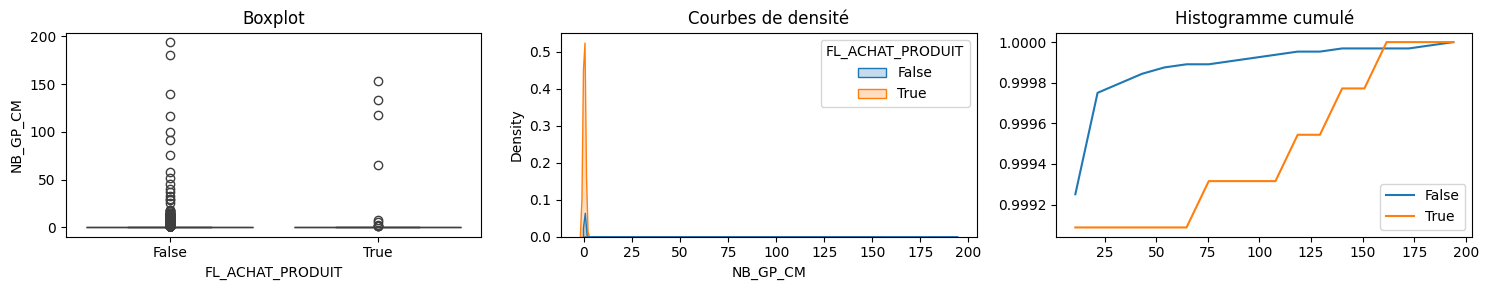

                    count      mean       std  min  25%  50%  75%    max
FL_ACHAT_PRODUIT                                                        
False             64092.0  0.097454  1.584105  0.0  0.0  0.0  0.0  194.0
True               4384.0  0.111542  3.678391  0.0  0.0  0.0  0.0  153.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(0.09), np.float64(0.11))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(0.0), np.float64(0.22))

Test de Shapiro-Wilk - Stat: 0.0232, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 0.2533, p-value: 0.6147 → Test non significatif à 5%
Test de Mann-Whitney - Stat: 146664191.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0019, p-value: 0.6147 → Test non significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.0440, p-value: 0.0000 → Test significatif à 5%
Statistique KS : 0.04401180716041864
     Distributions quasi-identiques
Eta2 : 2.8288680590145093e-08
    

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


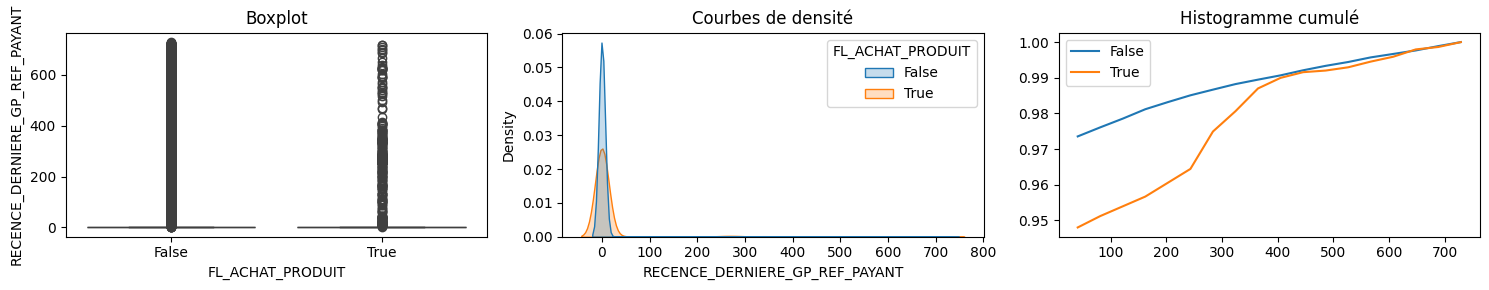

                    count       mean        std  min  25%  50%  75%    max
FL_ACHAT_PRODUIT                                                          
False             64092.0   8.634759  61.337426  0.0  0.0  0.0  0.0  729.0
True               4384.0  16.072765  76.970842  0.0  0.0  0.0  0.0  717.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(8.16), np.float64(9.11))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(13.79), np.float64(18.35))

Test de Shapiro-Wilk - Stat: 0.1317, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 58.1980, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 136089948.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0291, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.0314, p-value: 0.0006 → Test significatif à 5%
Statistique KS : 0.03142409109897226
     Distributions quasi-identiques
Eta2 : 1.442114506463781e-08
 

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


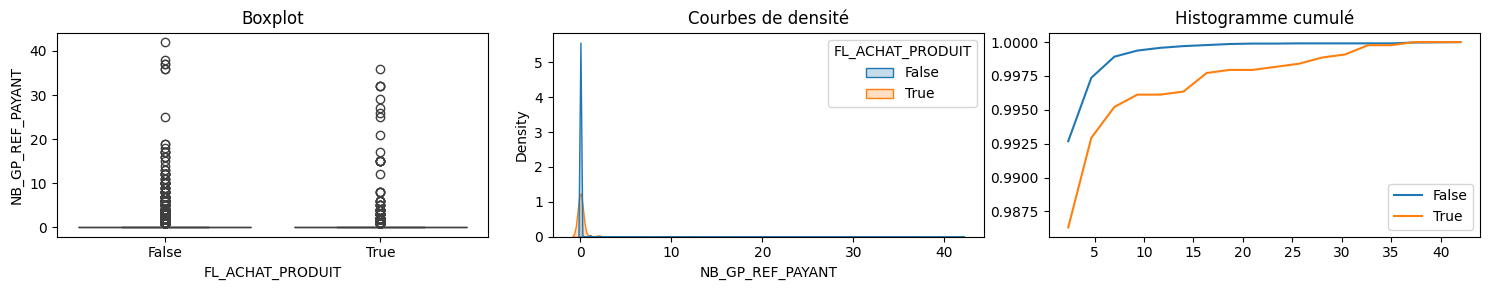

                    count     mean       std  min  25%  50%  75%   max
FL_ACHAT_PRODUIT                                                      
False             64092.0  0.06809  0.634505  0.0  0.0  0.0  0.0  42.0
True               4384.0  0.20438  1.567907  0.0  0.0  0.0  0.0  36.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(0.06), np.float64(0.07))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(0.16), np.float64(0.25))

Test de Shapiro-Wilk - Stat: 0.0768, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 142.6831, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 136042523.5000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0456, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.0314, p-value: 0.0006 → Test significatif à 5%
Statistique KS : 0.03140848852766853
     Distributions quasi-identiques
Eta2 : 1.4406827954850728e-08
    Relation négl

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


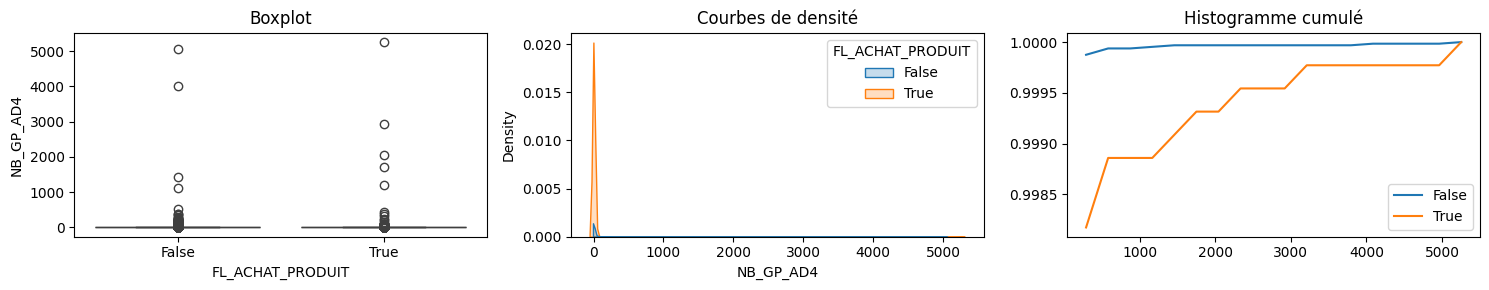

                    count      mean         std  min  25%  50%  75%     max
FL_ACHAT_PRODUIT                                                           
False             64092.0  1.055155   27.503855  0.0  0.0  0.0  0.0  5052.0
True               4384.0  4.544024  101.785134  0.0  0.0  0.0  0.0  5254.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(0.84), np.float64(1.27))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(1.53), np.float64(7.56))

Test de Shapiro-Wilk - Stat: 0.0106, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 36.4255, p-value: 0.0000 → Test significatif à 5%
Test de Mann-Whitney - Stat: 136611360.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0231, p-value: 0.0000 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.0299, p-value: 0.0013 → Test significatif à 5%
Statistique KS : 0.029860730537443647
     Distributions quasi-identiques
Eta2 : 1.3021923892552633e-

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


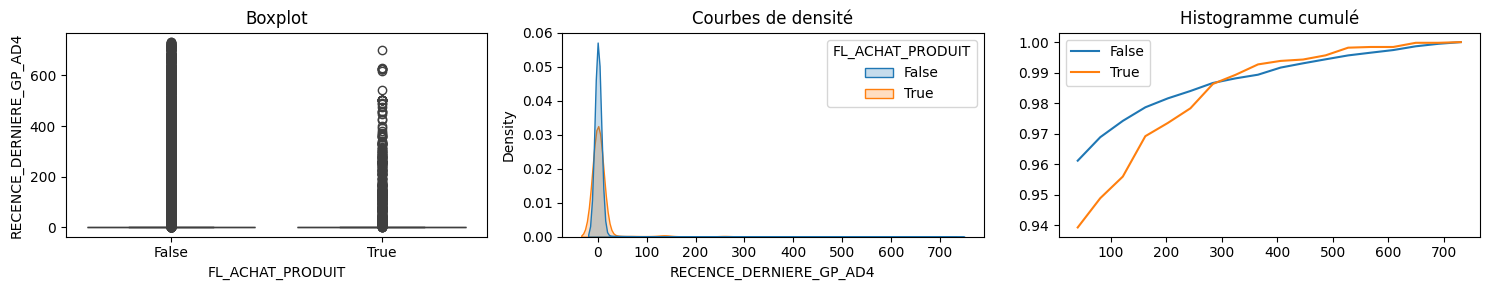

                    count       mean        std  min  25%  50%  75%    max
FL_ACHAT_PRODUIT                                                          
False             64092.0   9.937106  60.474880  0.0  0.0  0.0  0.0  731.0
True               4384.0  13.143476  60.720611  0.0  0.0  0.0  0.0  701.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(9.47), np.float64(10.41))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(11.35), np.float64(14.94))

Test de Shapiro-Wilk - Stat: 0.1612, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 11.5289, p-value: 0.0007 → Test significatif à 5%
Test de Mann-Whitney - Stat: 136642198.0000, p-value: 0.0000 → Test significatif à 5%
Corrélation point bisériale - Stat: 0.0130, p-value: 0.0007 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.0274, p-value: 0.0041 → Test significatif à 5%
Statistique KS : 0.027446061797115617
     Distributions quasi-identiques
Eta2 : 1.100105587353075e-08

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


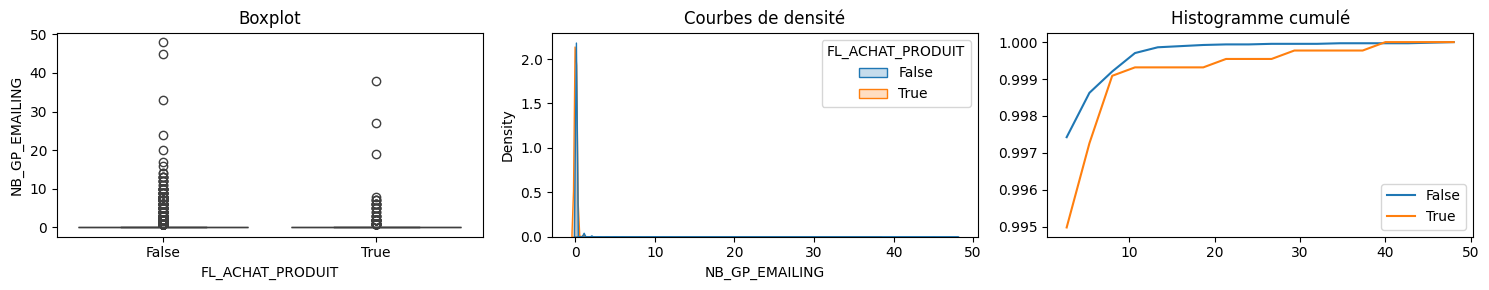

                    count      mean       std  min  25%  50%  75%   max
FL_ACHAT_PRODUIT                                                       
False             64092.0  0.032828  0.487137  0.0  0.0  0.0  0.0  48.0
True               4384.0  0.056113  0.849662  0.0  0.0  0.0  0.0  38.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(0.03), np.float64(0.04))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(0.03), np.float64(0.08))

Test de Shapiro-Wilk - Stat: 0.0379, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 8.2917, p-value: 0.0040 → Test significatif à 5%
Test de Mann-Whitney - Stat: 140208848.5000, p-value: 0.2928 → Test non significatif à 5%
Corrélation point bisériale - Stat: 0.0110, p-value: 0.0040 → Test significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.0027, p-value: 1.0000 → Test non significatif à 5%
Statistique KS : 0.0026905751586109306
     Distributions quasi-identiques
Eta2 : 1.0572180219307903e-10
    R

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


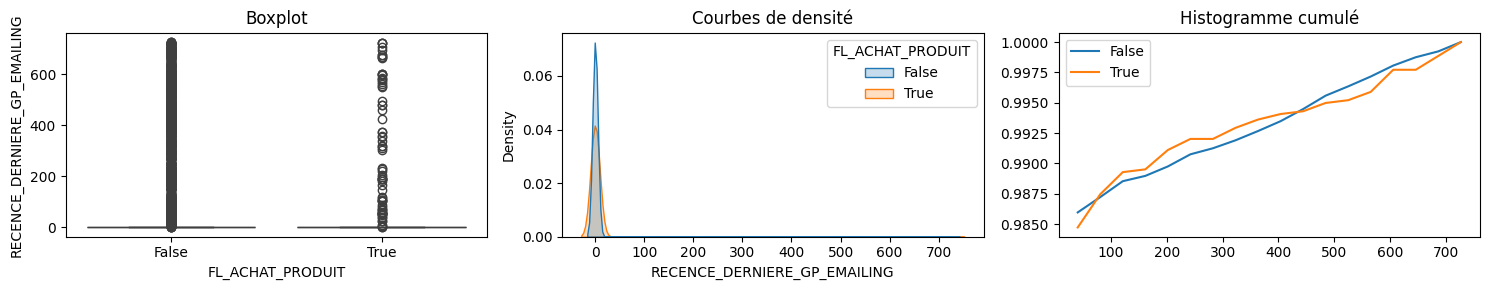

                    count      mean        std  min  25%  50%  75%    max
FL_ACHAT_PRODUIT                                                         
False             64092.0  5.130344  49.032333  0.0  0.0  0.0  0.0  727.0
True               4384.0  5.174042  50.411431  0.0  0.0  0.0  0.0  724.0

Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = False: (np.float64(4.75), np.float64(5.51))
Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = True: (np.float64(3.68), np.float64(6.67))

Test de Shapiro-Wilk - Stat: 0.0801, p-value: 0.0000 → Test significatif à 5%
Test de Levene - Stat: 0.0032, p-value: 0.9546 → Test non significatif à 5%
Test de Mann-Whitney - Stat: 140217576.5000, p-value: 0.3081 → Test non significatif à 5%
Corrélation point bisériale - Stat: 0.0002, p-value: 0.9546 → Test non significatif à 5%
Test de Kolmogorov-Smirnov - Stat: 0.0020, p-value: 1.0000 → Test non significatif à 5%
Statistique KS : 0.0019791064487135746
     Distributions quasi-identiques
Eta2 : 5.7202183823

c:\Users\prince.mezuirotimi\OneDrive - Gedeon - SIPAOF\Documents\INTRASIPA\PROJETS\ADDITI - SCORING APPETENCE PRODUIT\venv-ScAppetence\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68476.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
columns_quanti = dt.drop('ID_COMPTE', axis=1).select_dtypes(include=['float64', 'int64', 'Int64']).columns
resultats = {}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
        
    for column in columns_quanti:
        df = dt.copy()

        # Supprimer les lignes avec des NaN dans la colonne
        df = df.dropna(subset=[column])

        # Supprimer les valeurs infinies
        df = df[np.isfinite(df[column])]

        # Distance de Kolmogorov-Smirnov
        ks_stat, ks_p = stats.ks_2samp(df[column][df['FL_ACHAT_PRODUIT'] == False],
                                       df[column][df['FL_ACHAT_PRODUIT'] == True])

        # Rapport de corrélation Eta2
        eta2 = (ks_stat ** 2) / (ks_stat ** 2 + len(df[column]) - 2)

        # Sauvegarde des résultats
        resultats[column] = {
            'data': df,  # Je garde la data filtrée pour réafficher ensuite
            'ks_stat': ks_stat,
            'ks_p': ks_p,
            'eta2': eta2
        }

# Tri des variables par eta2 décroissant
resultats_tries = dict(sorted(resultats.items(), key=lambda item: item[1]['eta2'], reverse=True))

# Affichage final trié
for variable, infos in resultats_tries.items():
    print(f"Variable : {variable}")
    df = infos['data']
    ks_stat = infos['ks_stat']
    ks_p = infos['ks_p']
    eta2 = infos['eta2']

    print('---' * 30)
    print(f"Analyse de la variable '{variable}'\n")

    # Etude bivariée : Graphiques
    fig, axes = plt.subplots(1, 3, figsize=(15, 3))
    sns.boxplot(x='FL_ACHAT_PRODUIT', y=variable, data=df, ax=axes[0])
    axes[0].set_title('Boxplot')

    sns.kdeplot(data=df, x=variable, hue='FL_ACHAT_PRODUIT', fill=True, common_norm=False, ax=axes[1])
    axes[1].set_title('Courbes de densité')

    bins = np.histogram_bin_edges(df[variable], bins='auto')
    for label in df['FL_ACHAT_PRODUIT'].unique():
        subset = df[df['FL_ACHAT_PRODUIT'] == label][variable]
        counts, _ = np.histogram(subset, bins=bins)
        cum_counts = np.cumsum(counts) / counts.sum()
        axes[2].plot(bins[1:], cum_counts, label=str(label))
    axes[2].set_title('Histogramme cumulé')
    axes[2].legend()
    plt.tight_layout()
    plt.show()

    # Descriptif par groupe
    print(df.groupby('FL_ACHAT_PRODUIT')[variable].describe())
    print()

    # Intervalles de confiance
    for group in df['FL_ACHAT_PRODUIT'].unique():
        group_data = df[df['FL_ACHAT_PRODUIT'] == group][variable]
        conf_int = stats.t.interval(0.95, len(group_data)-1, loc=np.mean(group_data), scale=stats.sem(group_data))
        print(f"Intervalle de confiance pour 'FL_ACHAT_PRODUIT' = {group}: {(conf_int[0].round(2), conf_int[1].round(2))}")
    print()

    # Test de normalité
    shapiro_stat, shapiro_p = stats.shapiro(df[variable])
    normalite = shapiro_p >= 0.05
    significatif_shapiro = "non significatif" if normalite else "significatif"
    print(f'Test de Shapiro-Wilk - Stat: {shapiro_stat:.4f}, p-value: {shapiro_p:.4f} → Test {significatif_shapiro} à 5%')

    if normalite:
        bartlett_stat, bartlett_p = stats.bartlett(df[variable][df['FL_ACHAT_PRODUIT'] == False],
                                                   df[variable][df['FL_ACHAT_PRODUIT'] == True])
        equal_var = bartlett_p >= 0.05
        significatif_bartlett = "non significatif" if equal_var else "significatif"
        print(f'Test de Bartlett - Stat: {bartlett_stat:.4f}, p-value: {bartlett_p:.4f} → Test {significatif_bartlett} à 5%')
    else:
        levene_stat, levene_p = stats.levene(df[variable][df['FL_ACHAT_PRODUIT'] == False],
                                             df[variable][df['FL_ACHAT_PRODUIT'] == True])
        equal_var = levene_p >= 0.05
        significatif_levene = "non significatif" if equal_var else "significatif"
        print(f'Test de Levene - Stat: {levene_stat:.4f}, p-value: {levene_p:.4f} → Test {significatif_levene} à 5%')

    if normalite and equal_var:
        t_stat, t_p = stats.ttest_ind(df[variable][df['FL_ACHAT_PRODUIT'] == False],
                                      df[variable][df['FL_ACHAT_PRODUIT'] == True])
        significatif_t = "significatif" if t_p < 0.05 else "non significatif"
        print(f'Test de Student - Stat: {t_stat:.4f}, p-value: {t_p:.4f} → Test {significatif_t} à 5%')
    elif normalite and not equal_var:
        welch_stat, welch_p = stats.ttest_ind(df[variable][df['FL_ACHAT_PRODUIT'] == False],
                                              df[variable][df['FL_ACHAT_PRODUIT'] == True],
                                              equal_var=False)
        significatif_welch = "significatif" if welch_p < 0.05 else "non significatif"
        print(f'Test de Welch - Stat: {welch_stat:.4f}, p-value: {welch_p:.4f} → Test {significatif_welch} à 5%')
    else:
        mannwhitney_stat, mannwhitney_p = stats.mannwhitneyu(df[variable][df['FL_ACHAT_PRODUIT'] == False],
                                                             df[variable][df['FL_ACHAT_PRODUIT'] == True])
        significatif_mannwhitney = "significatif" if mannwhitney_p < 0.05 else "non significatif"
        print(f'Test de Mann-Whitney - Stat: {mannwhitney_stat:.4f}, p-value: {mannwhitney_p:.4f} → Test {significatif_mannwhitney} à 5%')

    corr, p_corr = stats.pointbiserialr(df['FL_ACHAT_PRODUIT'], df[variable])
    significatif_corr = "significatif" if p_corr < 0.05 else "non significatif"
    print(f"Corrélation point bisériale - Stat: {corr:.4f}, p-value: {p_corr:.4f} → Test {significatif_corr} à 5%")

    significatif_ks = "significatif" if ks_p < 0.05 else "non significatif"
    print(f'Test de Kolmogorov-Smirnov - Stat: {ks_stat:.4f}, p-value: {ks_p:.4f} → Test {significatif_ks} à 5%')

    print(f"Statistique KS : {ks_stat}")
    if ks_stat < 0.1:
        print("     Distributions quasi-identiques")
    elif 0.1 <= ks_stat <= 0.3:
        print("     Distributions modérément différentes")
    else:
        print("    Distributions significativement différentes")

    print(f"Eta2 : {eta2}")
    if eta2 < 0.01:
        print(f"    Relation négligeable")
    elif 0.01 <= eta2 < 0.06:
        print(f"    Relation faible")
    elif 0.06 <= eta2 < 0.14:
        print(f"    Relation modérée")
    else:
        print(f"    Relation forte")
    print('\n\n')


### Variables qualitatives

| **N°** | **Test**                   | **Objectif**                                                                           | **Conditions d’application**                                                  | **Hypothèse nulle (H₀)** | **Interprétation si rejet de H₀ / seuils**                                                 |
| ------ | -------------------------- | -------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------- | ------------------------ | ------------------------------------------------------------------------------------------ |
| **1A** | Khi-deux d’indépendance    | Tester l’**indépendance** entre la variable qualitative et la cible                    | Effectifs théoriques ≥ 5 dans **≥ 80%** des cases                             | Indépendance             | Si p < 0.05 : **Association significative** entre les modalités de la variable et la cible |
| **1B** | Test exact de Fisher       | Idem Khi-deux mais pour petits effectifs ou tableau 2×2                                | Effectifs insuffisants (ou tableau 2×2)                                       | Indépendance             | Si p < 0.05 : **Association significative**                                                |
| **2A** | Coefficient V de Cramer    | Mesurer la **force de l’association** quand cible et variable ont même nb de modalités | Khi-deux applicable **et** nb modalités cible = nb modalités variable         | —                        | V < 0.1 : faible / 0.1 ≤ V < 0.3 : modérée / V ≥ 0.3 : **forte** association               |
| **2B** | Coefficient T de Tschuprow | Mesurer la **force de l’association** quand nb modalités ≠                             | Khi-deux applicable **et** nb modalités **différent** entre cible et variable | —                        | T < 0.1 : faible / 0.1 ≤ T < 0.3 : modérée / T ≥ 0.3 : **forte** association               |
| **(+)**  | Wilcoxon-Mann-Whitney (ou Mann-Whitney-Wilcoxon) | Vérifier si les **rangs** de la variable ordinale diffèrent entre les 2 groupes | Si **qualitatives ordinales** | Les **distributions sont identiques** entre les groupes | Si p < 0.05 : la variable **discrimine** significativement les groupes (par ex. clients ayant acheté sont dans une classe plus élevée) |

In [9]:
def calcul_cramersV_tschuprowT(conf_matrix, contingency_table):
    chi2_stat, p_val, dof, ex = stats.chi2_contingency(conf_matrix)
    n = conf_matrix.sum().sum()
    
    # return v et t
    return np.sqrt(chi2_stat / (n * (min(conf_matrix.shape) - 1))), np.sqrt(chi2_stat / (n * (min(contingency_table.shape) - 1)))

In [10]:
dt = data.copy()
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68476 entries, 0 to 68475
Columns: 157 entries, _ID_ to SAISON
dtypes: bool(26), float64(20), int64(40), object(71)
memory usage: 70.1+ MB


------------------------------------------------------------------------------------------
Analyse de la variable 'LIB_DAF2'



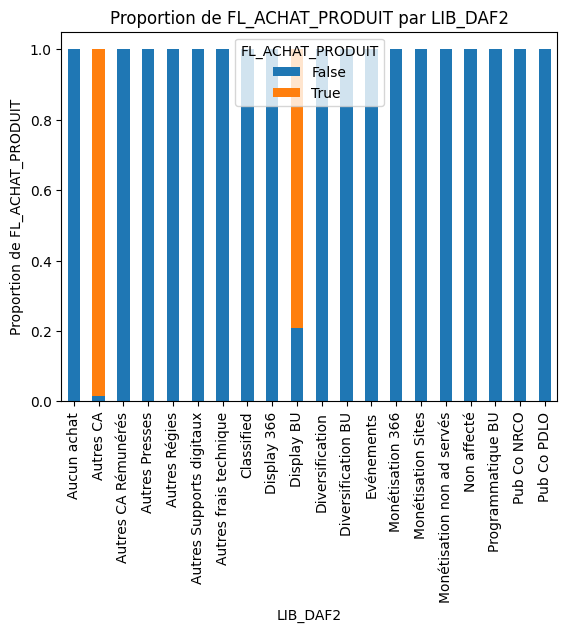


FL_ACHAT_PRODUIT            False  True 
LIB_DAF2                                
Aucun achat                 48306      0
Autres CA                      36   2274
Autres CA Rémunérés             6      0
Autres Presses                 64      0
Autres Régies                   4      0
Autres Supports digitaux       13      0
Autres frais technique          1      0
Classified                   2205      0
Display 366                    31      0
Display BU                    554   2113
Diversification              1285      0
Diversification BU            199      0
Evénements                    105      0
Monétisation 366               19      0
Monétisation Sites             90      0
Monétisation non ad servés      5      0
Non affecté                     8      0
Programmatique BU             464      0
Pub Co NRCO                    24      0
Pub Co PDLO                 10675      0

Test du Khi-Deux - Chi2 stat: 60569.4223, p-value: 0.0000, df: 19 → Test significatif à 5%
T de 

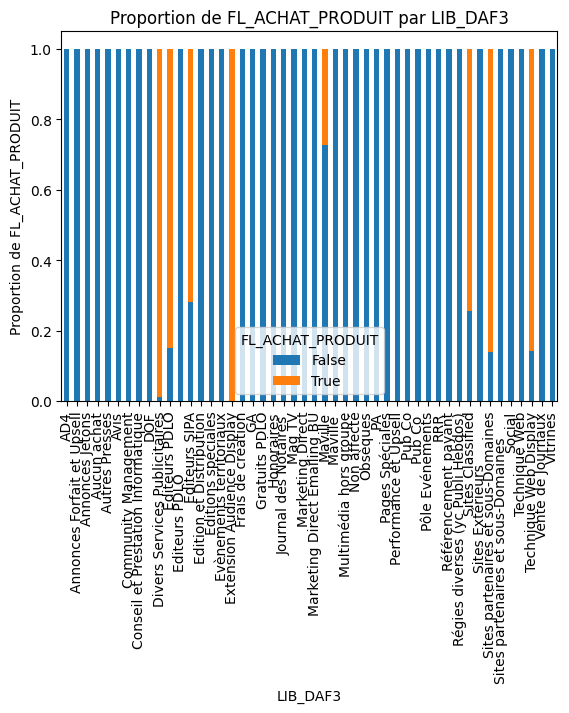


FL_ACHAT_PRODUIT                          False  True 
LIB_DAF3                                              
AD4                                         788      0
Annonces Forfait et Upsell                 1202      0
Annonces Jetons                              83      0
Aucun achat                               48306      0
Autres Presses                               64      0
Avis                                        778      0
Community Management                         51      0
Conseil et Prestation Informatique           76      0
DOF                                         131      0
Divers Services Publicitaires                25   2274
Editeurs PDLO                               238   1354
Editeurs PDLO                                 4      0
Editeurs SIPA                                 9     23
Edition et Distribution                       1      0
Editions spéciales                         1791      0
Evènements territoriaux                       2      0
Extension

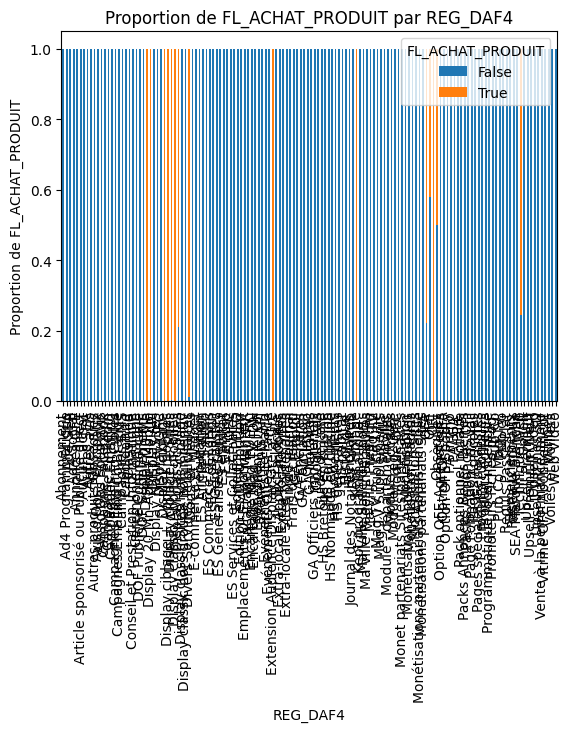


FL_ACHAT_PRODUIT             False  True 
REG_DAF4                                 
Abonnement                       1      0
Ad4 Programmatique             422      0
Ad4 SEA                         21      0
Ad4 Social                     345      0
Annonces OFE                    83      0
...                            ...    ...
Vente à la performance Immo      1      0
Vitrine OFE Abonnement          29      0
Vitrines                        47      0
Voiles et Voiliers               3      0
Web Vidéo                        1      0

[142 rows x 2 columns]

Test exact de Fisher - Stat: 0.0000, p-value: 0.0001 → Test significatif à 5%
Variables non valides pour le calcul de V de Cramer ou T de Tschuprow



------------------------------------------------------------------------------------------
Analyse de la variable 'GAMME_PRODUIT'



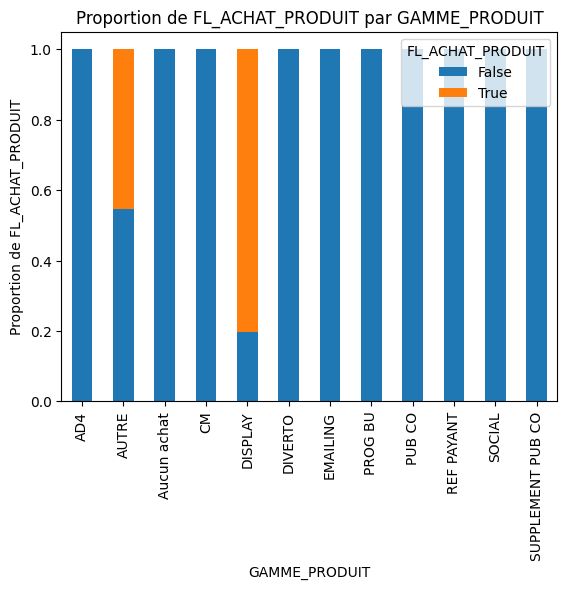


FL_ACHAT_PRODUIT   False  True 
GAMME_PRODUIT                  
AD4                  788      0
AUTRE               2753   2274
Aucun achat        48306      0
CM                    51      0
DISPLAY              523   2113
DIVERTO              878      0
EMAILING              58      0
PROG BU              464      0
PUB CO              7469      0
REF PAYANT           218      0
SOCIAL               234      0
SUPPLEMENT PUB CO   2352      0

Test du Khi-Deux - Chi2 stat: 40718.5372, p-value: 0.0000, df: 11 → Test significatif à 5%
T de Tschuprow : 0.7711
     Relation forte



------------------------------------------------------------------------------------------
Analyse de la variable 'DEPARTEMENT'



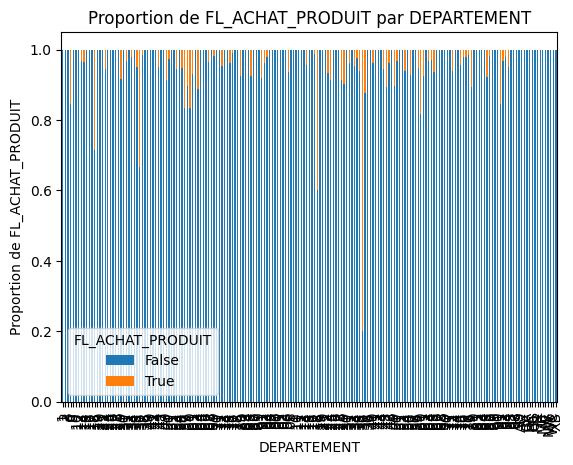


FL_ACHAT_PRODUIT  False  True 
DEPARTEMENT                   
1                     2      0
2                    11      0
3                     3      0
6                    11      2
8                     1      0
...                 ...    ...
N/                    3      0
NW                    7      0
W6                    7      0
WC                    8      0
XB                    4      0

[187 rows x 2 columns]

Test du Khi-Deux - Chi2 stat: 663.2086, p-value: 0.0000, df: 186 → Test significatif à 5%
T de Tschuprow : 0.0984
     Relation faible



------------------------------------------------------------------------------------------
Analyse de la variable 'CODE_POSTAL'



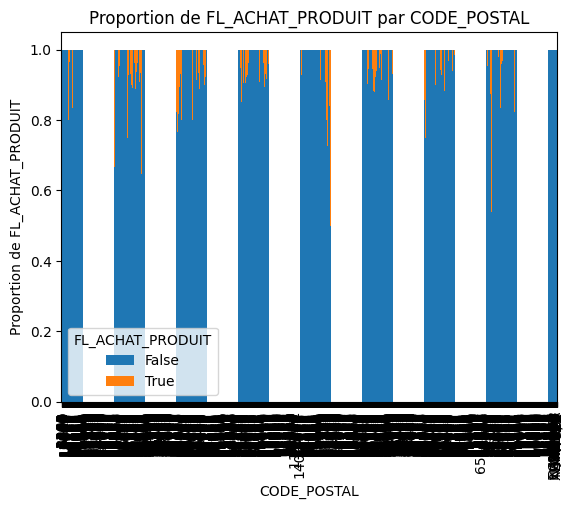


FL_ACHAT_PRODUIT  False  True 
CODE_POSTAL                   
35                    1      0
1100                  2      0
2000                  2      0
2260                  2      0
2300                  2      0
...                 ...    ...
N/D                   3      0
NW1 2FD               7      0
W6 7A                 7      0
WC2E                  8      0
XBX 1425              4      0

[2488 rows x 2 columns]

Test exact de Fisher - Stat: 0.0000, p-value: 1.0000 → Test non significatif à 5%
Variables non valides pour le calcul de V de Cramer ou T de Tschuprow



------------------------------------------------------------------------------------------
Analyse de la variable 'STATUT_SOCIETE'



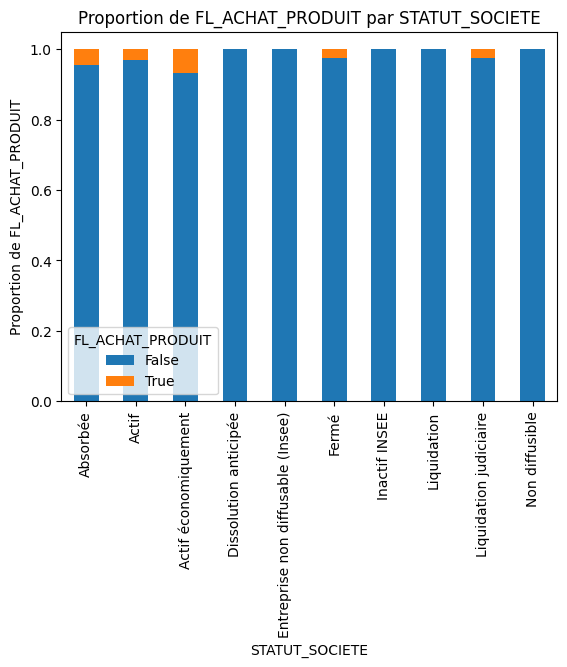


FL_ACHAT_PRODUIT                   False  True 
STATUT_SOCIETE                                 
Absorbée                              66      3
Actif                                123      4
Actif économiquement               57515   4217
Dissolution anticipée                125      0
Entreprise non diffusable (Insee)     27      0
Fermé                               4993    135
Inactif INSEE                          1      0
Liquidation                          146      0
Liquidation judiciaire              1095     28
Non diffusible                         3      0

Test du Khi-Deux - Chi2 stat: 192.4641, p-value: 0.0000, df: 9 → Test significatif à 5%
T de Tschuprow : 0.0530
     Relation faible



------------------------------------------------------------------------------------------
Analyse de la variable 'TYPE_FACTURE'



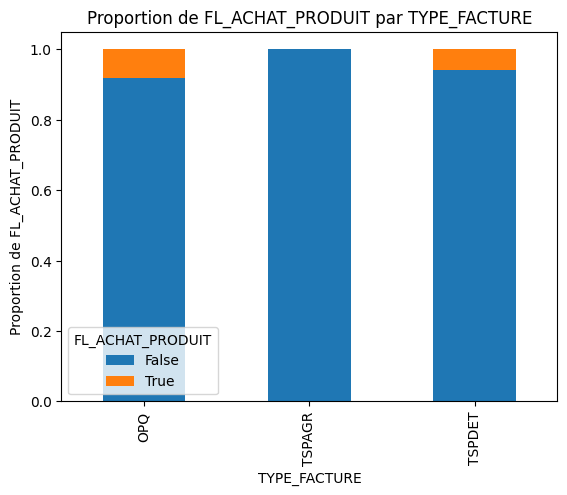


FL_ACHAT_PRODUIT  False  True 
TYPE_FACTURE                  
OPQ               14386   1263
TSPAGR               29      0
TSPDET            49679   3124

Test du Khi-Deux - Chi2 stat: 95.4394, p-value: 0.0000, df: 2 → Test significatif à 5%
T de Tschuprow : 0.0373
     Relation faible



------------------------------------------------------------------------------------------
Analyse de la variable 'MODE_PAIEMENT'



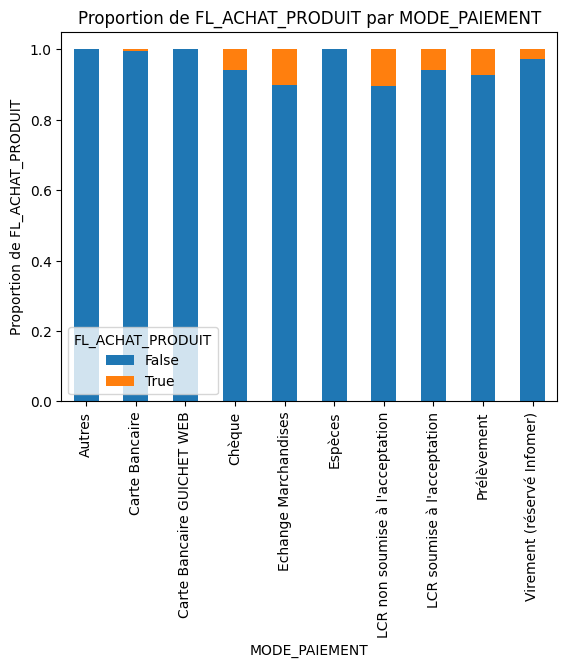


FL_ACHAT_PRODUIT                 False  True 
MODE_PAIEMENT                                
Autres                              56      0
Carte Bancaire                     247      1
Carte Bancaire GUICHET WEB           3      0
Chèque                           46163   2856
Echange Marchandises                 9      1
Espèces                             12      0
LCR non soumise à l'acceptation   5280    623
LCR soumise à l'acceptation        130      8
Prélèvement                      10639    853
Virement (réservé Infomer)        1555     45

Test du Khi-Deux - Chi2 stat: 271.1972, p-value: 0.0000, df: 9 → Test significatif à 5%
T de Tschuprow : 0.0629
     Relation faible



------------------------------------------------------------------------------------------
Analyse de la variable 'FREQUENCE_FACTURATION'



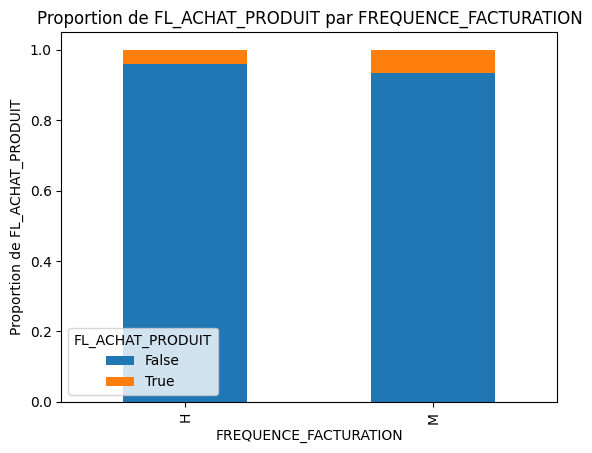


FL_ACHAT_PRODUIT       False  True 
FREQUENCE_FACTURATION              
H                       2843    117
M                      61251   4270

Test exact de Fisher - Stat: 1.6940, p-value: 0.0000 → Test significatif à 5%
Variables non valides pour le calcul de V de Cramer ou T de Tschuprow



------------------------------------------------------------------------------------------
Analyse de la variable 'DELAI_PAIEMENT'



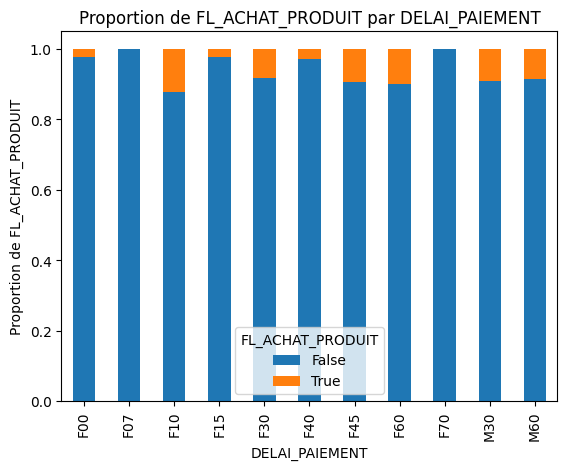


FL_ACHAT_PRODUIT  False  True 
DELAI_PAIEMENT                
F00                 859     19
F07                  56      0
F10                 114     16
F15               21084    484
F30               34318   3111
F40                  36      1
F45                1211    126
F60                 581     63
F70                  58      0
M30                5712    561
M60                  65      6

Test du Khi-Deux - Chi2 stat: 992.7654, p-value: 0.0000, df: 10 → Test significatif à 5%
T de Tschuprow : 0.1204
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'SOURCE_CREATION'



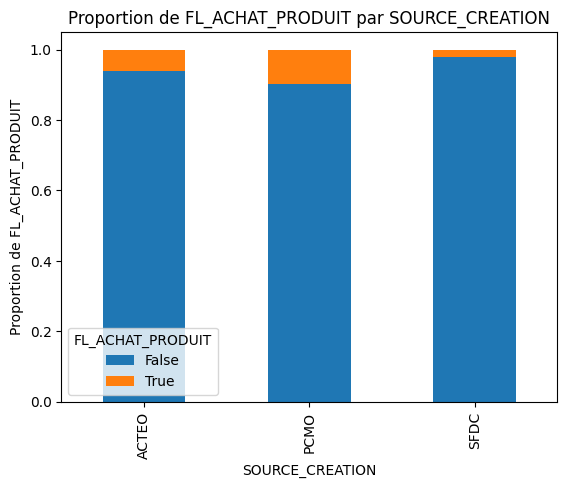


FL_ACHAT_PRODUIT  False  True 
SOURCE_CREATION               
ACTEO             15491   1015
PCMO              26877   2923
SFDC              21726    449

Test du Khi-Deux - Chi2 stat: 1287.1994, p-value: 0.0000, df: 2 → Test significatif à 5%
T de Tschuprow : 0.1371
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'PROCEDURE_COLLECTIVE'



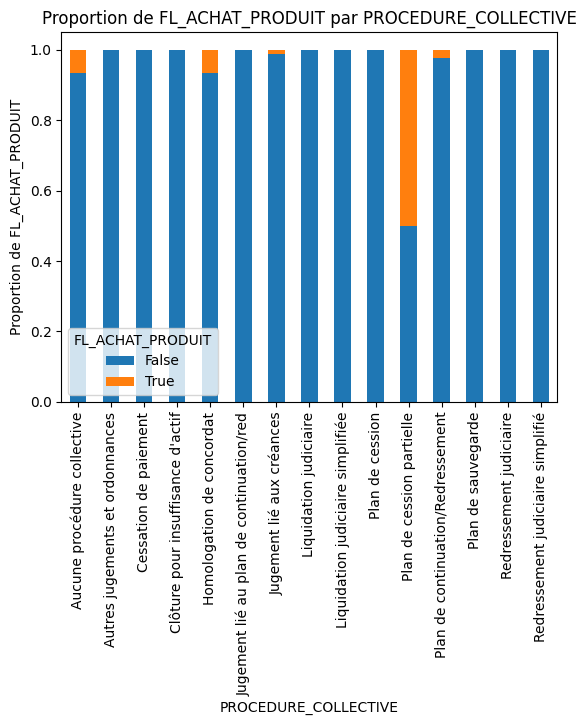


FL_ACHAT_PRODUIT                          False  True 
PROCEDURE_COLLECTIVE                                  
Aucune procédure collective               63343   4375
Autres jugements et ordonnances              39      0
Cessation de paiement                         5      0
Clôture pour insuffisance d'actif           136      0
Homologation de concordat                    57      4
Jugement lié au plan de continuation/red     39      0
Jugement lié aux créances                    85      1
Liquidation judiciaire                      106      0
Liquidation judiciaire simplifiée           102      0
Plan de cession                              54      0
Plan de cession partielle                     5      5
Plan de continuation/Redressement            82      2
Plan de sauvegarde                           14      0
Redressement judiciaire                      26      0
Redressement judiciaire simplifié             1      0

Test du Khi-Deux - Chi2 stat: 73.9757, p-value: 0.0000, df: 14 

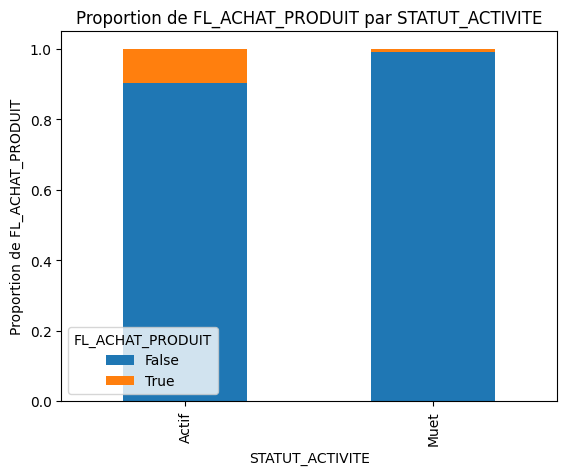


FL_ACHAT_PRODUIT  False  True 
STATUT_ACTIVITE               
Actif             39239   4193
Muet              24855    194

Test exact de Fisher - Stat: 0.0730, p-value: 0.0000 → Test significatif à 5%
Variables non valides pour le calcul de V de Cramer ou T de Tschuprow



------------------------------------------------------------------------------------------
Analyse de la variable 'STATUT_BENEFICIAIRE'



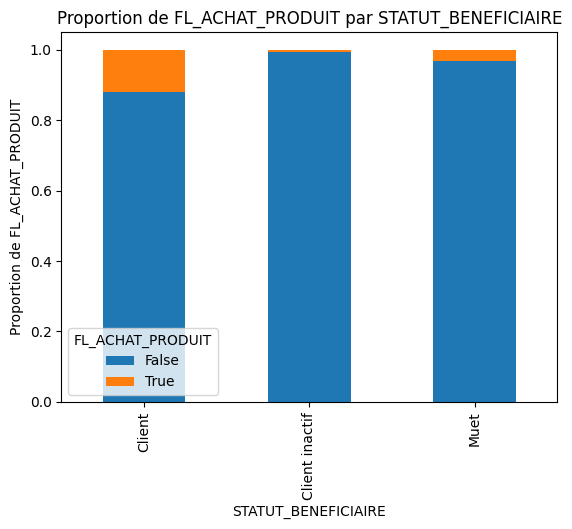


FL_ACHAT_PRODUIT     False  True 
STATUT_BENEFICIAIRE              
Client               28951   3916
Client inactif       25776    162
Muet                  9367    309

Test du Khi-Deux - Chi2 stat: 3275.9882, p-value: 0.0000, df: 2 → Test significatif à 5%
T de Tschuprow : 0.2187
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'PROFIL_CLIENT'



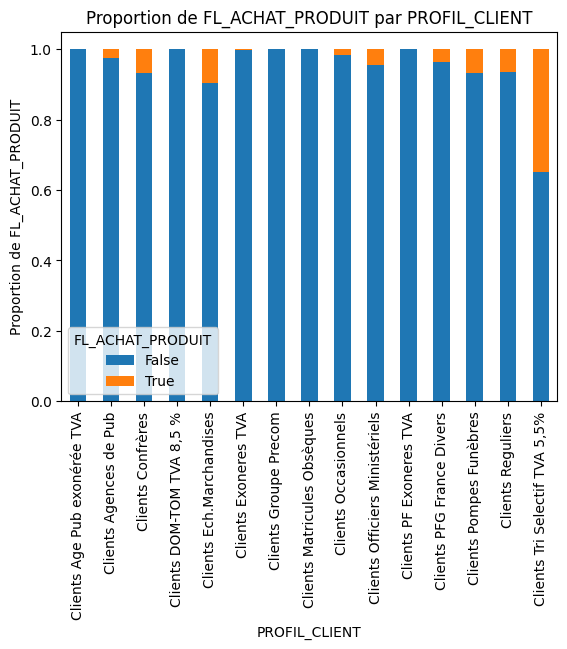


FL_ACHAT_PRODUIT                False  True 
PROFIL_CLIENT                               
Clients Age Pub exonérée TVA       16      0
Clients Agences de Pub            521     13
Clients Confrères                 168     12
Clients DOM-TOM TVA 8,5 %           9      0
Clients Ech.Marchandises           28      3
Clients Exoneres TVA              335      1
Clients Groupe Precom              59      0
Clients Matricules Obsèques         3      0
Clients Occasionnels             1770     28
Clients Officiers Ministériels    230     11
Clients PF Exoneres TVA            13      0
Clients PFG France Divers          27      1
Clients Pompes Funèbres          1038     76
Clients Reguliers               59862   4234
Clients Tri Selectif TVA 5,5%      15      8

Test du Khi-Deux - Chi2 stat: 150.0906, p-value: 0.0000, df: 14 → Test significatif à 5%
T de Tschuprow : 0.0468
     Relation faible



------------------------------------------------------------------------------------------
Analy

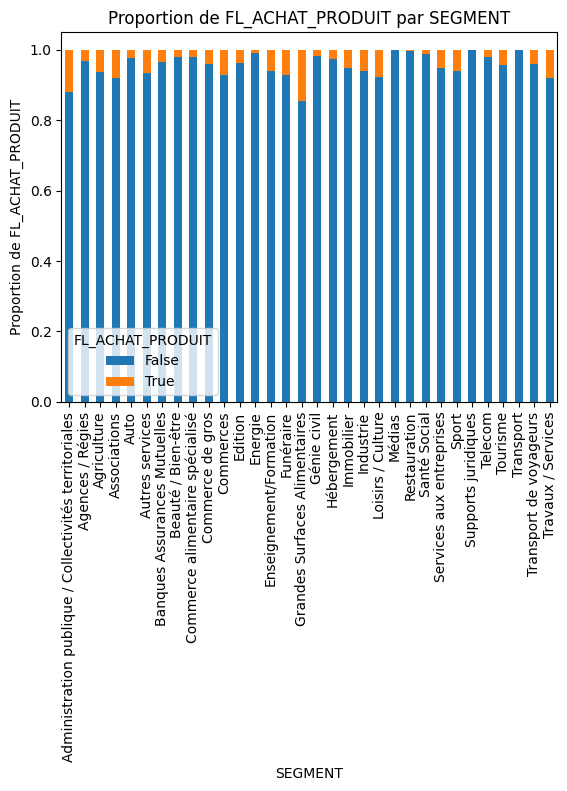


FL_ACHAT_PRODUIT                                    False  True 
SEGMENT                                                         
Administration publique / Collectivités territo...   2250    304
Agences / Régies                                      784     25
Agriculture                                          4032    273
Associations                                          753     65
Auto                                                  448     10
Autres services                                      1977    136
Banques Assurances Mutuelles                          800     29
Beauté / Bien-être                                    866     17
Commerce alimentaire spécialisé                      2053     44
Commerce de gros                                      762     33
Commerces                                           13299   1018
Edition                                               236      9
Energie                                               114      1
Enseignement/Formation  

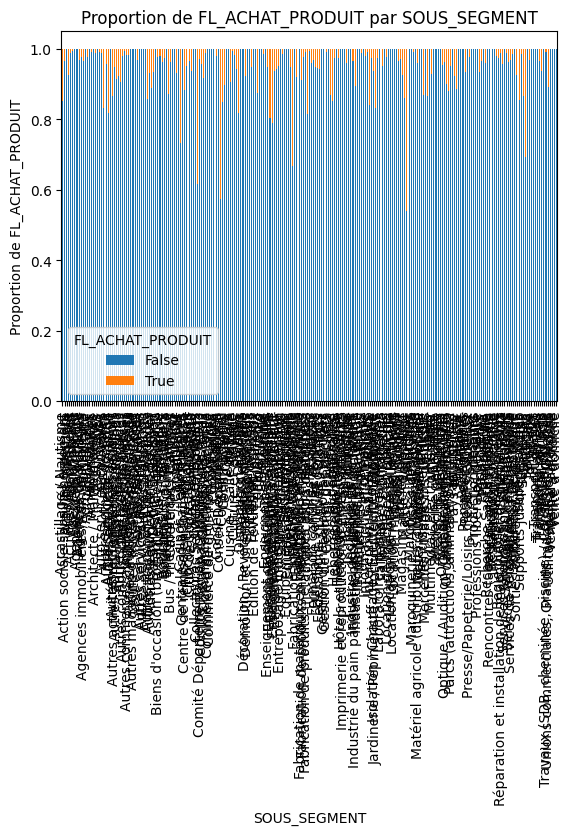


FL_ACHAT_PRODUIT                                  False  True 
SOUS_SEGMENT                                                  
Accastillage / Nautisme                              97     17
Action sociale sans hébergement                     172      6
Activité forestière                                  24      0
Activité maritime                                    37      3
Activités hospitalières                             192      2
...                                                 ...    ...
Unions commerciales, Grands magasins et Galeries    578     70
Utilitaires et poids lourds                           2      0
Vente par automate                                    3      0
Vente à distance                                     50      0
Vente à domicile                                      9      0

[239 rows x 2 columns]

Test du Khi-Deux - Chi2 stat: 3040.2437, p-value: 0.0000, df: 238 → Test significatif à 5%
T de Tschuprow : 0.2107
     Relation modérée



---------------

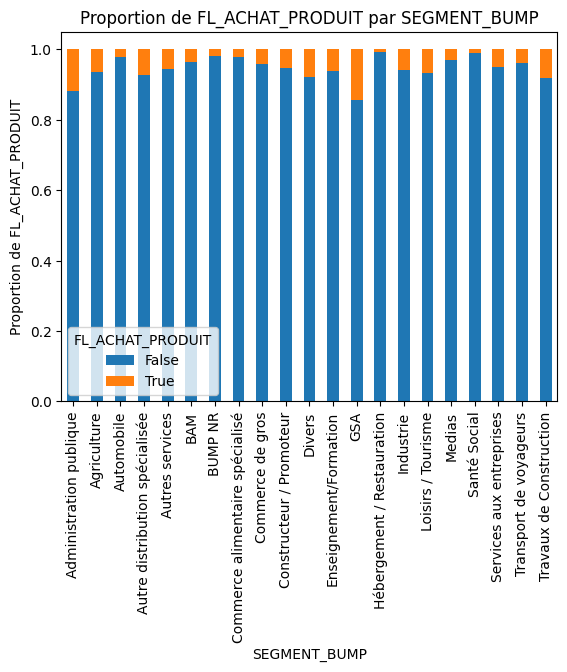


FL_ACHAT_PRODUIT                 False  True 
SEGMENT_BUMP                                 
Administration publique           2250    304
Agriculture                       4032    273
Automobile                         448     10
Autre distribution spécialisée   13105   1018
Autres services                   4200    249
BAM                                800     29
BUMP NR                            744     13
Commerce alimentaire spécialisé   2053     44
Commerce de gros                   762     33
Constructeur / Promoteur          7462    416
Divers                             753     65
Enseignement/Formation            3024    196
GSA                               2879    486
Hébergement / Restauration        2139     16
Industrie                         3061    193
Loisirs / Tourisme                4673    337
Medias                             784     25
Santé Social                      2176     24
Services aux entreprises          2686    140
Transport de voyageurs           

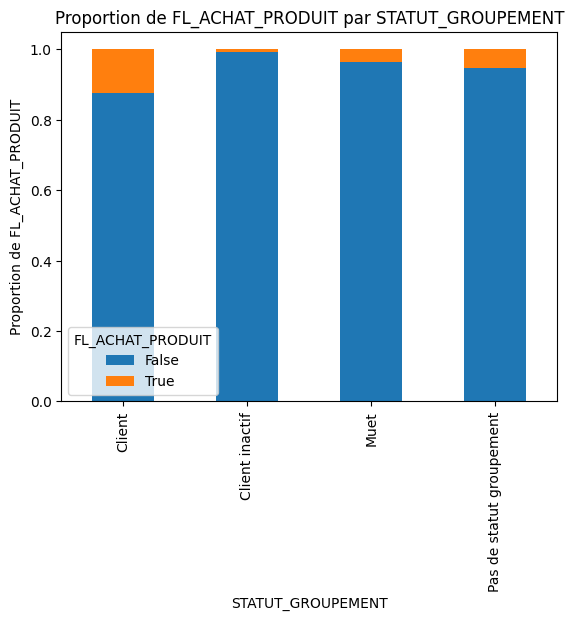


FL_ACHAT_PRODUIT          False  True 
STATUT_GROUPEMENT                     
Client                    10451   1473
Client inactif             1769     15
Muet                       1234     45
Pas de statut groupement  50640   2854

Test du Khi-Deux - Chi2 stat: 915.6535, p-value: 0.0000, df: 3 → Test significatif à 5%
T de Tschuprow : 0.1156
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'GROUPEMENT'



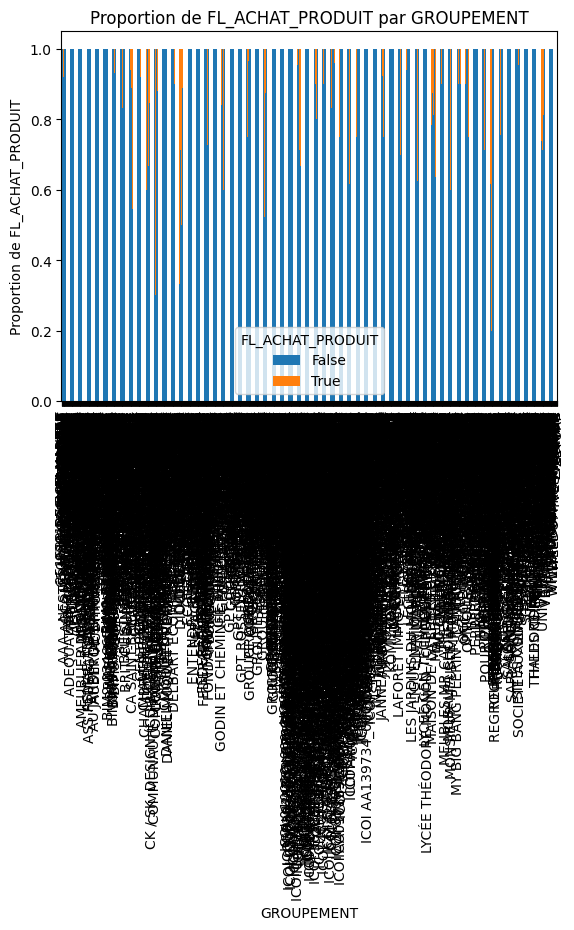


FL_ACHAT_PRODUIT       False  True 
GROUPEMENT                         
030127-BATI NANTES        23      0
228145                     7      2
251630 DESIGN HABITAT      4      0
5 MENHIRS                  4      0
650899 GROUPE LAUNAY      20     12
...                      ...    ...
YVES ROCHER                8      0
YVON                       3      0
YVONNOU                    6      1
Z COMME                    3      0
ZETURF                    10      0

[1547 rows x 2 columns]

Test exact de Fisher - Stat: 0.0000, p-value: 1.0000 → Test non significatif à 5%
Variables non valides pour le calcul de V de Cramer ou T de Tschuprow



------------------------------------------------------------------------------------------
Analyse de la variable 'RECORD_TYPE_NAME'



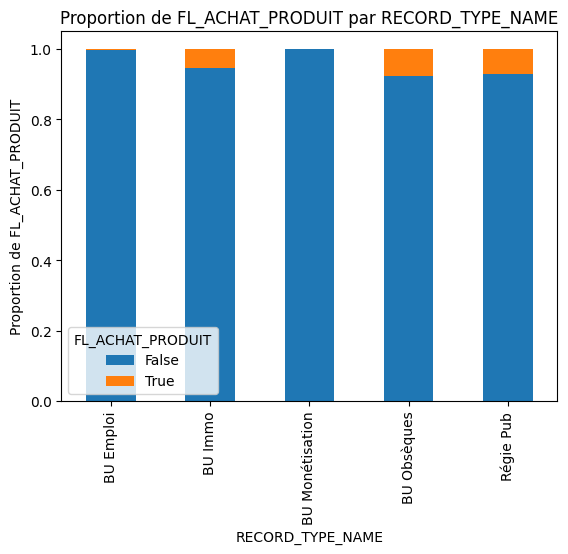


FL_ACHAT_PRODUIT  False  True 
RECORD_TYPE_NAME              
BU Emploi          3532     11
BU Immo            7205    418
BU Monétisation     511      0
BU Obsèques        1489    123
Régie Pub         51357   3835

Test du Khi-Deux - Chi2 stat: 296.4723, p-value: 0.0000, df: 4 → Test significatif à 5%
T de Tschuprow : 0.0658
     Relation faible



------------------------------------------------------------------------------------------
Analyse de la variable 'ETAPE_OPPORTUNITE'



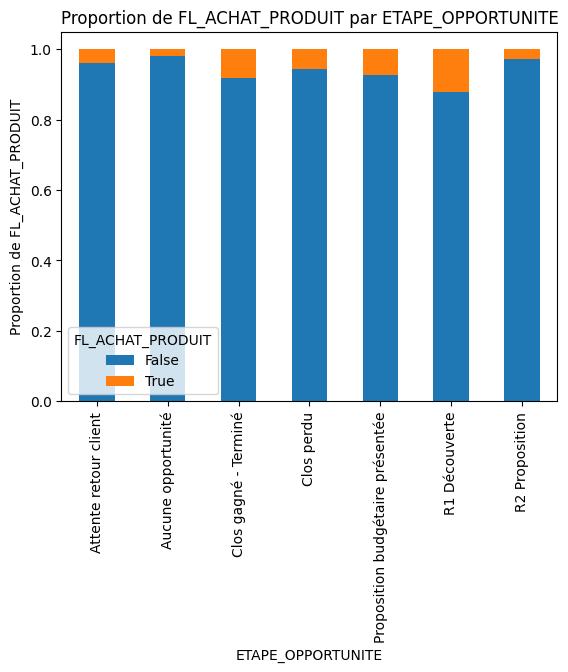


FL_ACHAT_PRODUIT                  False  True 
ETAPE_OPPORTUNITE                             
Attente retour client                76      3
Aucune opportunité                 9749    178
Clos gagné - Terminé              29894   2662
Clos perdu                        22669   1330
Proposition budgétaire présentée    142     11
R1 Découverte                      1455    200
R2 Proposition                      109      3

Test du Khi-Deux - Chi2 stat: 645.0949, p-value: 0.0000, df: 6 → Test significatif à 5%
T de Tschuprow : 0.0971
     Relation faible



------------------------------------------------------------------------------------------
Analyse de la variable 'TYPE_PRODUIT_OPPORTUNITE'



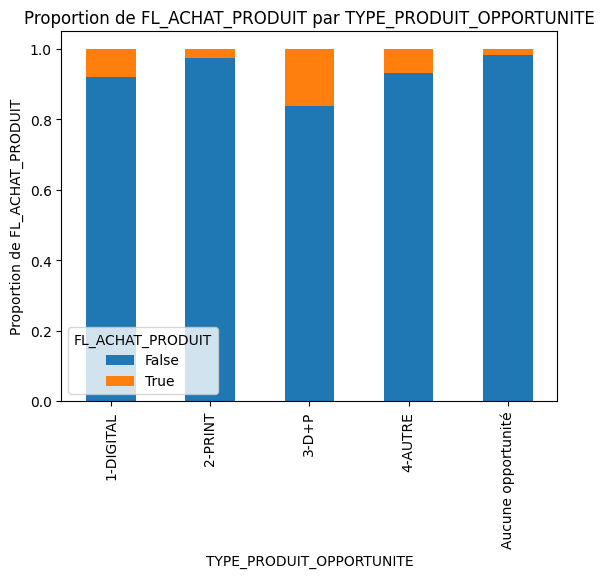


FL_ACHAT_PRODUIT          False  True 
TYPE_PRODUIT_OPPORTUNITE              
1-DIGITAL                  8549    729
2-PRINT                   26781    722
3-D+P                     11431   2198
4-AUTRE                    7584    560
Aucune opportunité         9749    178

Test du Khi-Deux - Chi2 stat: 3191.8115, p-value: 0.0000, df: 4 → Test significatif à 5%
T de Tschuprow : 0.2159
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'STATUT_DETAIL_PERE'



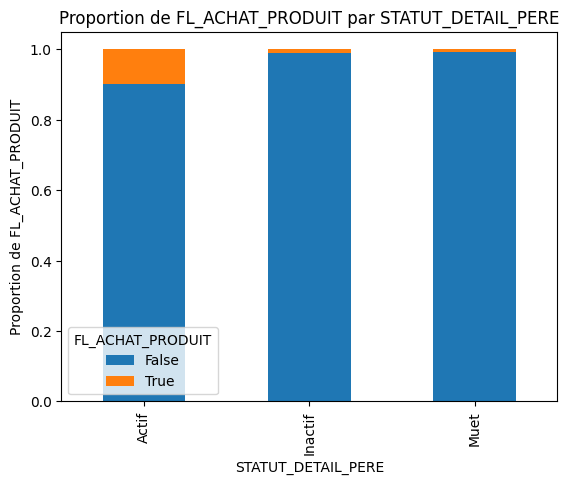


FL_ACHAT_PRODUIT    False  True 
STATUT_DETAIL_PERE              
Actif               38198   4222
Inactif              1391     13
Muet                24505    152

Test du Khi-Deux - Chi2 stat: 2338.7951, p-value: 0.0000, df: 2 → Test significatif à 5%
T de Tschuprow : 0.1848
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'DETAIL_TYPE_SUPPORT'



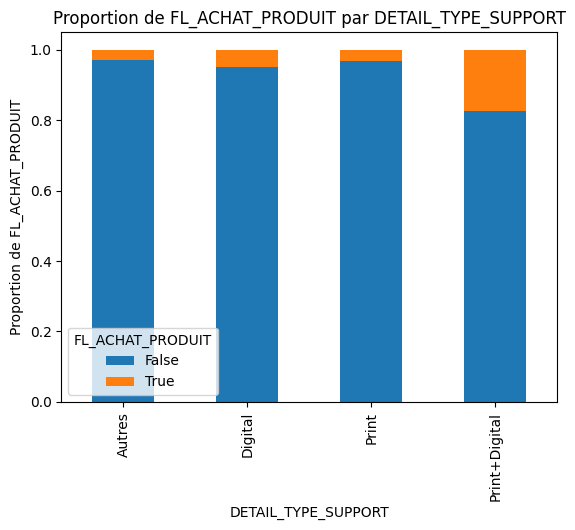


FL_ACHAT_PRODUIT     False  True 
DETAIL_TYPE_SUPPORT              
Autres                1666     51
Digital              14611    752
Print                36271   1165
Print+Digital        11546   2419

Test du Khi-Deux - Chi2 stat: 3545.1166, p-value: 0.0000, df: 3 → Test significatif à 5%
T de Tschuprow : 0.2275
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'DETAIL_TYPE_PRODUIT'



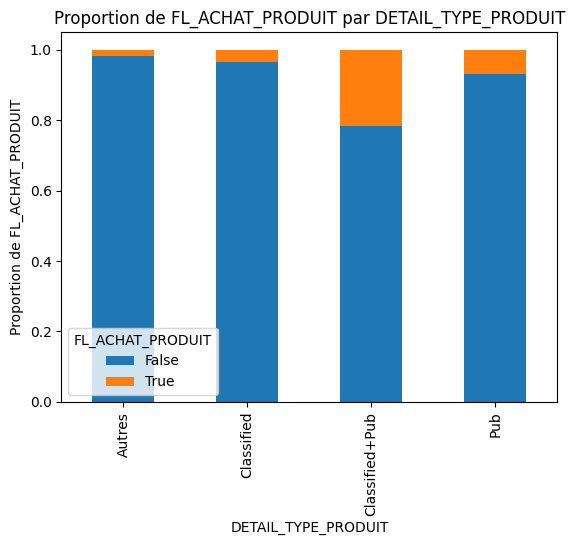


FL_ACHAT_PRODUIT     False  True 
DETAIL_TYPE_PRODUIT              
Autres                 942     18
Classified            8181    287
Classified+Pub         396    110
Pub                  54575   3972

Test du Khi-Deux - Chi2 stat: 373.7914, p-value: 0.0000, df: 3 → Test significatif à 5%
T de Tschuprow : 0.0739
     Relation faible



------------------------------------------------------------------------------------------
Analyse de la variable 'ACHAT_PRODUIT'



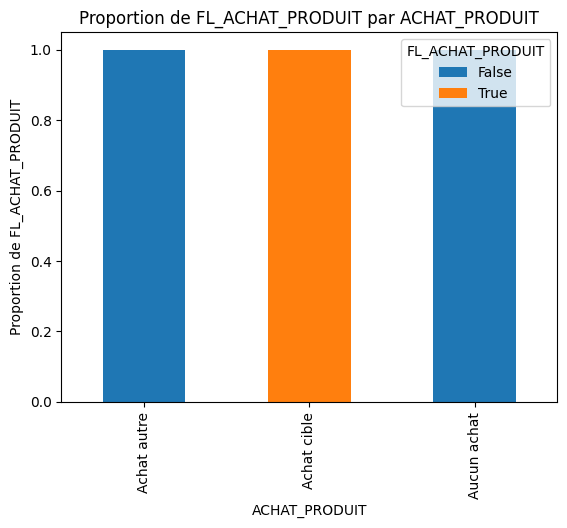


FL_ACHAT_PRODUIT  False  True 
ACHAT_PRODUIT                 
Achat autre       15788      0
Achat cible           0   4387
Aucun achat       48306      0

Test du Khi-Deux - Chi2 stat: 68481.0000, p-value: 0.0000, df: 2 → Test significatif à 5%
T de Tschuprow : 1.0000
     Relation forte



------------------------------------------------------------------------------------------
Analyse de la variable 'FORME_JURIDIQUE_MISSING'



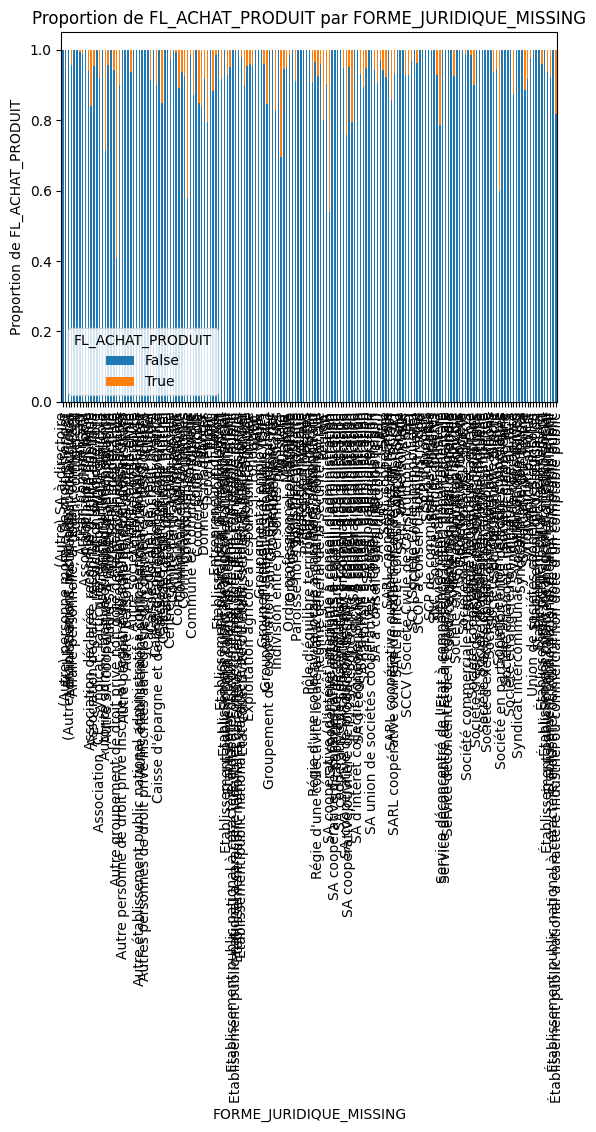


FL_ACHAT_PRODUIT                                    False  True 
FORME_JURIDIQUE_MISSING                                         
(Autre) SA à directoire                                13      0
(Autre) personne morale de droit étranger               2      0
(Autre) Établissement public administratif local        5      0
Administrations, institutions, collectivités           90      4
Affaire personnelle, artisan, commercant               46      0
...                                                   ...    ...
Établissement public local social et médico-social     15      0
Établissement public local à caractère industri...    135      9
Établissement public national à caractère admin...     47      4
Établissement public national à caractère indus...      3      0
Établissement public national à caractère indus...     18      4

[175 rows x 2 columns]

Test du Khi-Deux - Chi2 stat: 794.5152, p-value: 0.0000, df: 174 → Test significatif à 5%
T de Tschuprow : 0.1077
     Relation m

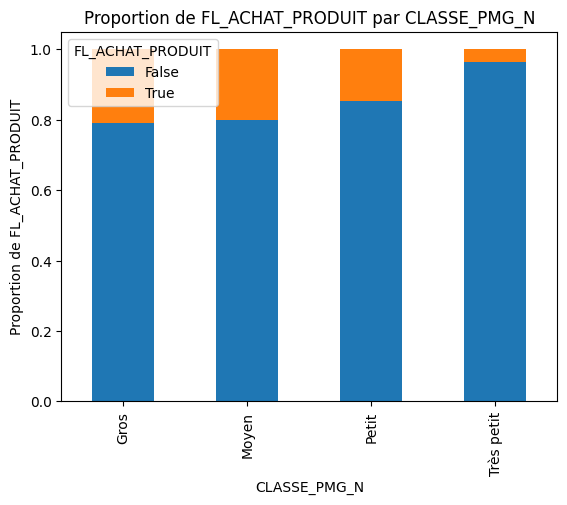


FL_ACHAT_PRODUIT  False  True 
CLASSE_PMG_N                  
Gros                776    204
Moyen              2027    510
Petit             10567   1796
Très petit        50724   1877

Test du Khi-Deux - Chi2 stat: 3199.5416, p-value: 0.0000, df: 3 → Test significatif à 5%
T de Tschuprow : 0.2162
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'CLASSE_PMG_N1'



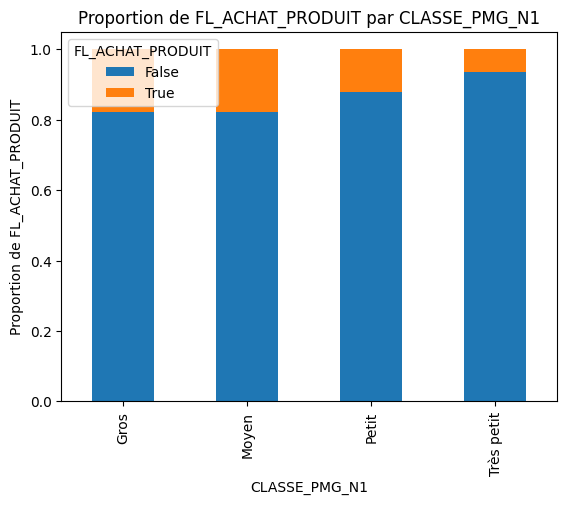


FL_ACHAT_PRODUIT  False  True 
CLASSE_PMG_N1                 
Gros                861    187
Moyen              2150    466
Petit             11915   1632
Très petit        22754   1577

Test du Khi-Deux - Chi2 stat: 666.0227, p-value: 0.0000, df: 3 → Test significatif à 5%
T de Tschuprow : 0.1266
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'INDICATEUR_RF'



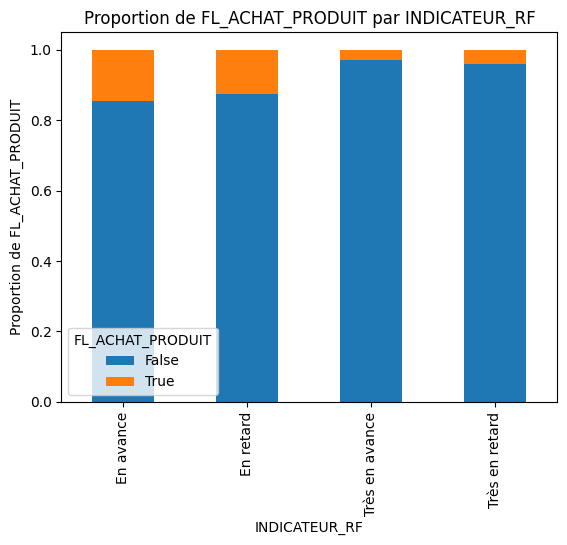


FL_ACHAT_PRODUIT  False  True 
INDICATEUR_RF                 
En avance          2800    480
En retard         18942   2712
Très en avance      102      3
Très en retard    26916   1120

Test du Khi-Deux - Chi2 stat: 1391.3432, p-value: 0.0000, df: 3 → Test significatif à 5%
T de Tschuprow : 0.1619
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'INDICATEUR_MONTANT'



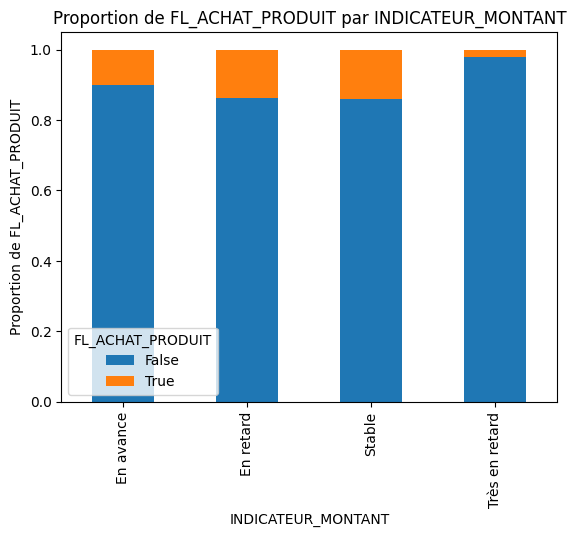


FL_ACHAT_PRODUIT    False  True 
INDICATEUR_MONTANT              
En avance           20691   2342
En retard            3012    479
Stable               5207    844
Très en retard      35184    722

Test du Khi-Deux - Chi2 stat: 2586.1668, p-value: 0.0000, df: 3 → Test significatif à 5%
T de Tschuprow : 0.1943
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'INDICATEUR_RFM'



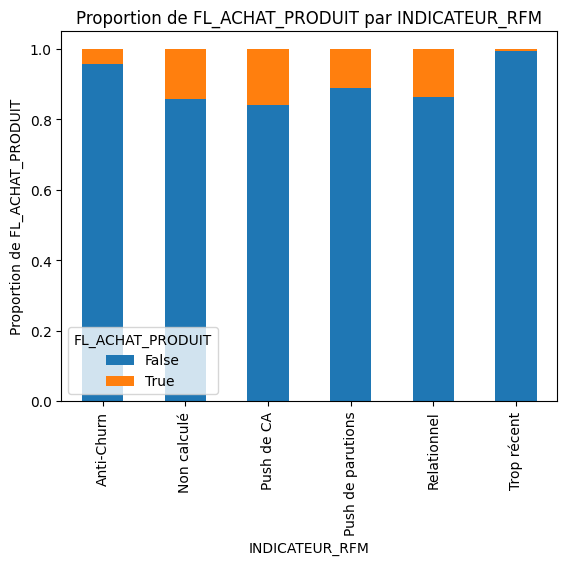


FL_ACHAT_PRODUIT   False  True 
INDICATEUR_RFM                 
Anti-Churn         23446   1026
Non calculé          473     79
Push de CA           578    109
Push de parutions  22412   2806
Relationnel         1851    295
Trop récent        15334     72

Test du Khi-Deux - Chi2 stat: 2396.5099, p-value: 0.0000, df: 5 → Test significatif à 5%
T de Tschuprow : 0.1871
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'INDICATEUR_RF_GP_DIVERTO'



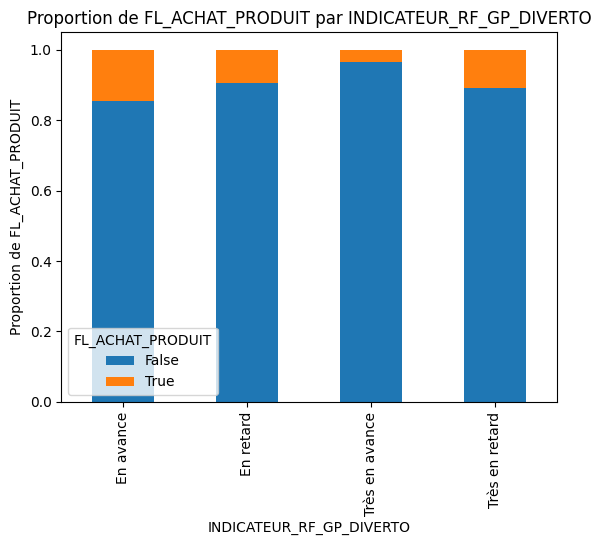


FL_ACHAT_PRODUIT          False  True 
INDICATEUR_RF_GP_DIVERTO              
En avance                 10078   1699
En retard                  1436    151
Très en avance            44918   1594
Très en retard             7662    943

Test du Khi-Deux - Chi2 stat: 2274.9834, p-value: 0.0000, df: 3 → Test significatif à 5%
T de Tschuprow : 0.1823
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'INDICATEUR_RF_GP_AUTRE'



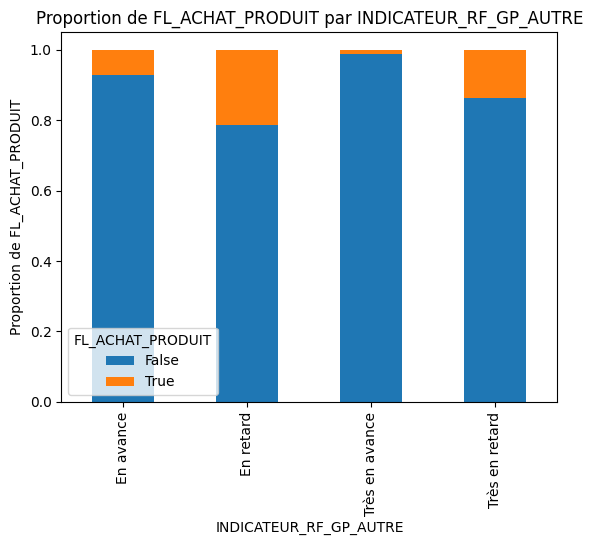


FL_ACHAT_PRODUIT        False  True 
INDICATEUR_RF_GP_AUTRE              
En avance                6856    537
En retard                3366    909
Très en avance          38078    416
Très en retard          15794   2525

Test du Khi-Deux - Chi2 stat: 5066.5540, p-value: 0.0000, df: 3 → Test significatif à 5%
T de Tschuprow : 0.2720
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'INDICATEUR_RF_GP_PUB_CO'



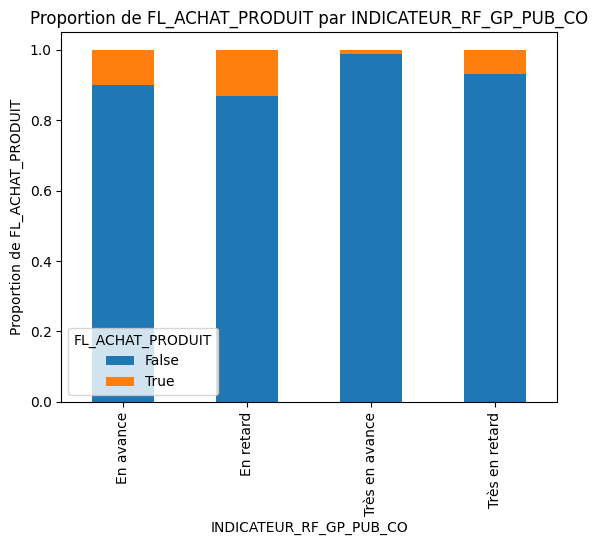


FL_ACHAT_PRODUIT         False  True 
INDICATEUR_RF_GP_PUB_CO              
En avance                 5387    603
En retard                 8348   1270
Très en avance           18960    237
Très en retard           31399   2277

Test du Khi-Deux - Chi2 stat: 1738.6541, p-value: 0.0000, df: 3 → Test significatif à 5%
T de Tschuprow : 0.1593
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'INDICATEUR_RF_GP_DISPLAY'



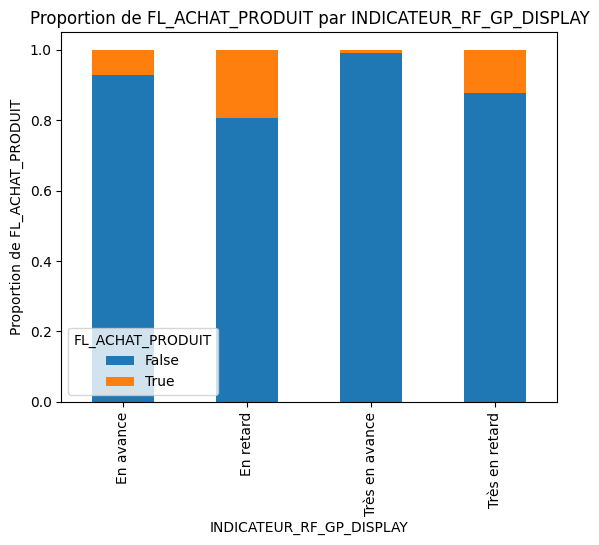


FL_ACHAT_PRODUIT          False  True 
INDICATEUR_RF_GP_DISPLAY              
En avance                  6677    523
En retard                  4086    982
Très en avance            35280    368
Très en retard            18051   2514

Test du Khi-Deux - Chi2 stat: 4308.9692, p-value: 0.0000, df: 3 → Test significatif à 5%
T de Tschuprow : 0.2508
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'INDICATEUR_RF_GP_SUPPLEMENT_PUB_CO'



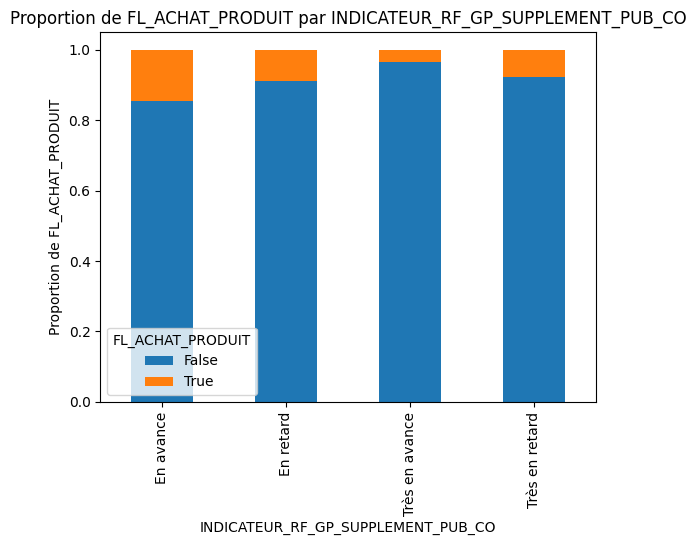


FL_ACHAT_PRODUIT                    False  True 
INDICATEUR_RF_GP_SUPPLEMENT_PUB_CO              
En avance                            8317   1410
En retard                            3099    298
Très en avance                      37426   1379
Très en retard                      15252   1300

Test du Khi-Deux - Chi2 stat: 1677.8695, p-value: 0.0000, df: 3 → Test significatif à 5%
T de Tschuprow : 0.1565
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'INDICATEUR_RF_GP_PROG_BU'



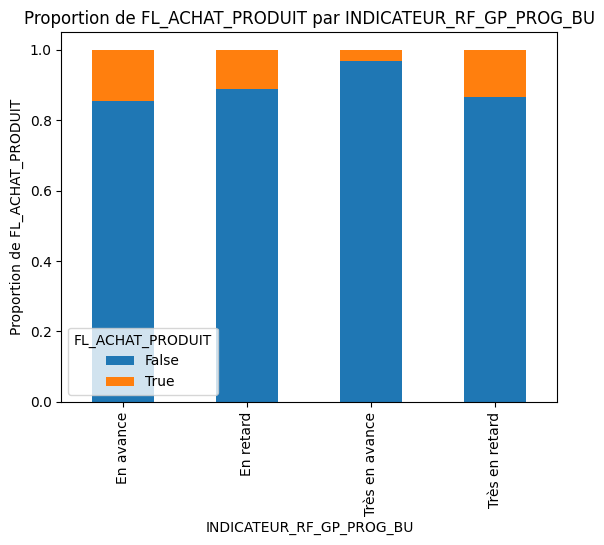


FL_ACHAT_PRODUIT          False  True 
INDICATEUR_RF_GP_PROG_BU              
En avance                 10514   1795
En retard                  1742    216
Très en avance            46512   1557
Très en retard             5326    819

Test du Khi-Deux - Chi2 stat: 2737.6025, p-value: 0.0000, df: 3 → Test significatif à 5%
T de Tschuprow : 0.1999
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'INDICATEUR_RF_GP_REF_PAYANT'



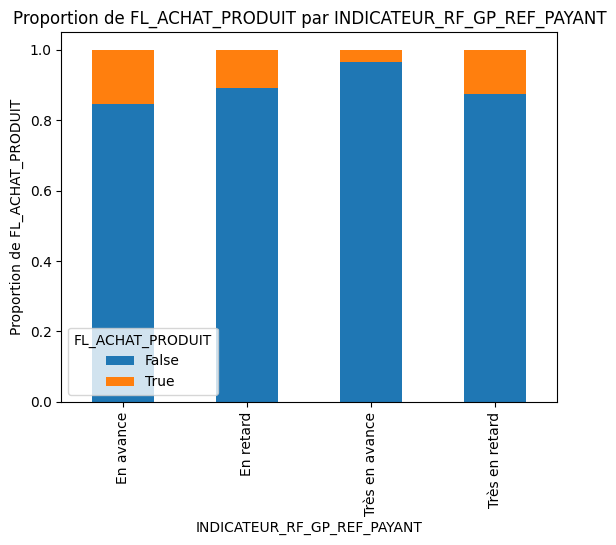


FL_ACHAT_PRODUIT             False  True 
INDICATEUR_RF_GP_REF_PAYANT              
En avance                    12647   2324
En retard                      340     41
Très en avance               49650   1810
Très en retard                1457    212

Test du Khi-Deux - Chi2 stat: 2914.1933, p-value: 0.0000, df: 3 → Test significatif à 5%
T de Tschuprow : 0.2063
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'INDICATEUR_RF_GP_EMAILING'



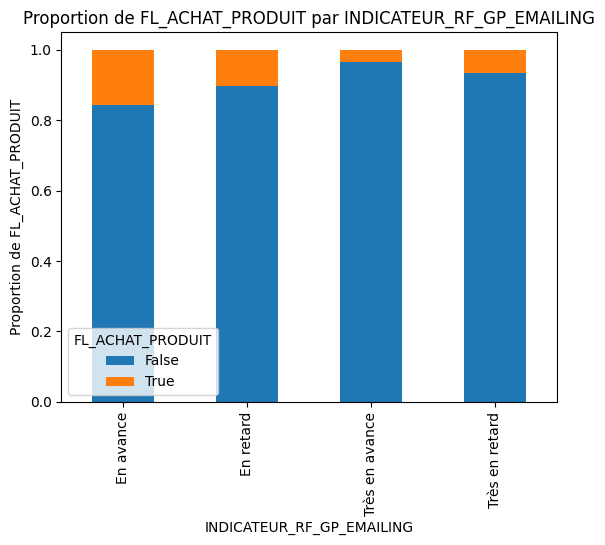


FL_ACHAT_PRODUIT           False  True 
INDICATEUR_RF_GP_EMAILING              
En avance                  13087   2448
En retard                    132     15
Très en avance             50081   1867
Très en retard               794     57

Test du Khi-Deux - Chi2 stat: 2954.8337, p-value: 0.0000, df: 3 → Test significatif à 5%
T de Tschuprow : 0.2077
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'INDICATEUR_RF_GP_AD4'



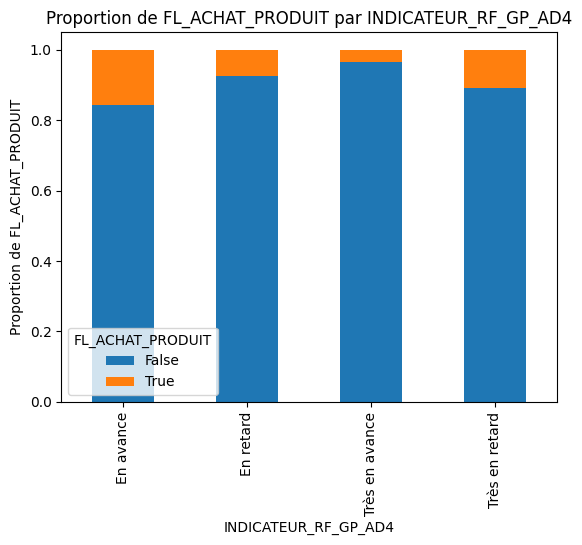


FL_ACHAT_PRODUIT      False  True 
INDICATEUR_RF_GP_AD4              
En avance             12235   2274
En retard              1100     89
Très en avance        48962   1802
Très en retard         1797    222

Test du Khi-Deux - Chi2 stat: 2842.0930, p-value: 0.0000, df: 3 → Test significatif à 5%
T de Tschuprow : 0.2037
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'INDICATEUR_RF_GP_SOCIAL'



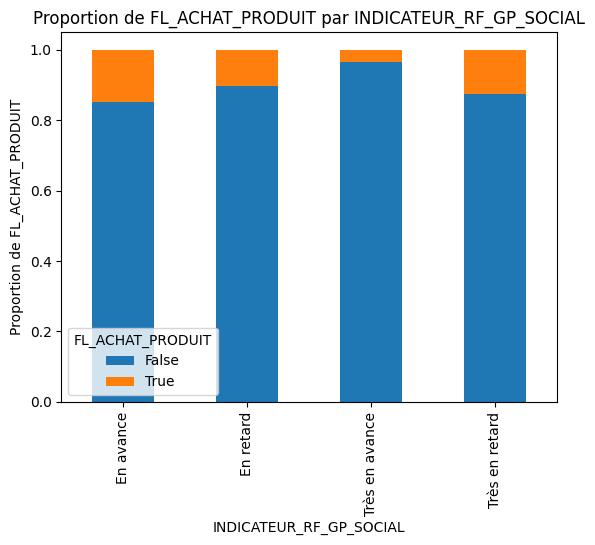


FL_ACHAT_PRODUIT         False  True 
INDICATEUR_RF_GP_SOCIAL              
En avance                11603   2028
En retard                  787     90
Très en avance           48180   1757
Très en retard            3524    512

Test du Khi-Deux - Chi2 stat: 2613.3615, p-value: 0.0000, df: 3 → Test significatif à 5%
T de Tschuprow : 0.1954
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'INDICATEUR_RF_GP_CM'



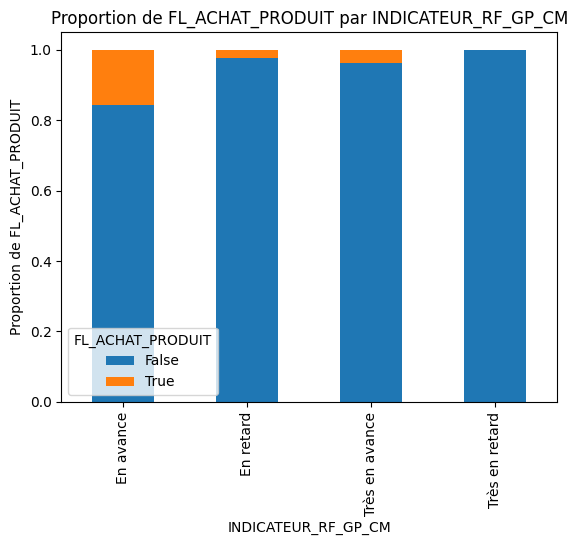


FL_ACHAT_PRODUIT     False  True 
INDICATEUR_RF_GP_CM              
En avance            13335   2506
En retard              123      3
Très en avance       47839   1875
Très en retard        2797      3

Test du Khi-Deux - Chi2 stat: 3105.4479, p-value: 0.0000, df: 3 → Test significatif à 5%
T de Tschuprow : 0.2129
     Relation modérée



------------------------------------------------------------------------------------------
Analyse de la variable 'CD_DEPARTEMENT'



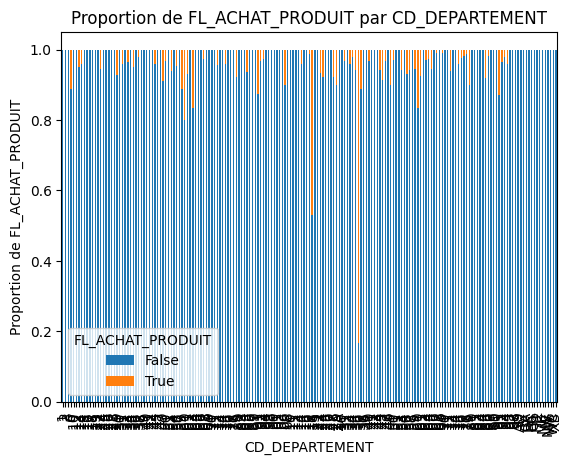


FL_ACHAT_PRODUIT  False  True 
CD_DEPARTEMENT                
1                     2      0
2                     6      0
3                     1      0
6                     8      1
10                    1      0
...                 ...    ...
N/                    3      0
NW                    7      0
W6                    7      0
WC                    8      0
XB                    4      0

[183 rows x 2 columns]

Test exact de Fisher - Stat: 0.0000, p-value: 0.0001 → Test significatif à 5%
Variables non valides pour le calcul de V de Cramer ou T de Tschuprow



------------------------------------------------------------------------------------------
Analyse de la variable 'REGION'



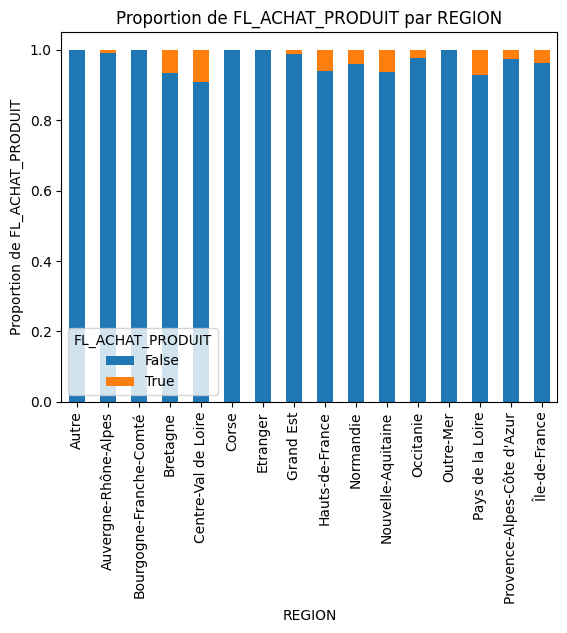


FL_ACHAT_PRODUIT            False  True 
REGION                                  
Autre                          97      0
Auvergne-Rhône-Alpes          403      4
Bourgogne-Franche-Comté       111      0
Bretagne                    25026   1775
Centre-Val de Loire           453     45
Corse                           7      0
Etranger                       18      0
Grand Est                     269      3
Hauts-de-France               337     22
Normandie                    5942    247
Nouvelle-Aquitaine           1262     86
Occitanie                     387      9
Outre-Mer                      20      0
Pays de la Loire            26884   2084
Provence-Alpes-Côte d'Azur    157      4
Île-de-France                2721    108

Test du Khi-Deux - Chi2 stat: 195.1750, p-value: 0.0000, df: 15 → Test significatif à 5%
T de Tschuprow : 0.0534
     Relation faible



------------------------------------------------------------------------------------------
Analyse de la variable 'SAISON'


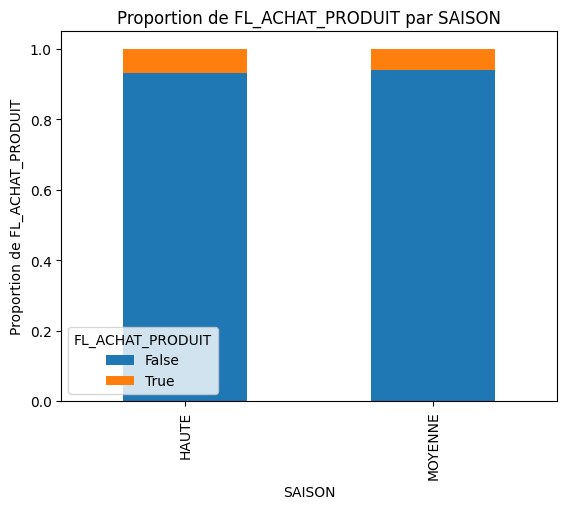


FL_ACHAT_PRODUIT  False  True 
SAISON                        
HAUTE             25339   1879
MOYENNE           38755   2508

Test exact de Fisher - Stat: 0.8727, p-value: 0.0000 → Test significatif à 5%
Variables non valides pour le calcul de V de Cramer ou T de Tschuprow





In [ ]:
columns_to_exclude = ['ID_COMPTE', '_ID_', '_DATE_ETUDE_'] + [col for col in dt.columns if col.startswith('DT_')]

columns_quali = dt.drop(columns_to_exclude, axis=1).select_dtypes(include=['category', 'object']).columns
resultats = {}

for column in columns_quali:
    df = dt.copy()
    print('---'*30)
    print(f"Analyse de la variable '{column}'")
    print()
    
    # Supprimer les lignes avec des NaN dans la colonne
    df = df.dropna(subset=[column]) # Mais on est pas sensé avoir de NaN
    
    # Vérification des effectifs
    nb_modalites = df[column].nunique()
    nb_modalite_valide = (df[column].value_counts() >= 5).sum()
    eff_modalites = bool(nb_modalite_valide/nb_modalites >= 0.8)
    
    # Etude bivariée
    contingency_table = pd.crosstab(df[column], df['FL_ACHAT_PRODUIT'])
    ## Diagramme en bâtons
    contingency_table_percentage = contingency_table.div(contingency_table.sum(axis=1), axis=0)
    contingency_table_percentage.plot(kind='bar', stacked=True)
    plt.title(f'Proportion de FL_ACHAT_PRODUIT par {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Proportion de FL_ACHAT_PRODUIT')
    plt.show()
    print()
    
    ## Tableau croisé
    print(contingency_table)
    print()

    if nb_modalites == 2 or eff_modalites == False:
        ## Test exact de Fisher
        oddsratio, fisher_p = stats.fisher_exact(contingency_table)
        significatif_fisher = "significatif" if fisher_p < 0.05 else "non significatif"
        print(f'Test exact de Fisher - Stat: {oddsratio:.4f}, p-value: {fisher_p:.4f} → Test {significatif_fisher} à 5%')
    else:
        ## Test du Khi-Deux
        chi2_stat, chi2_p, dof, ex = stats.chi2_contingency(contingency_table)
        significatif_chi2 = "significatif" if chi2_p < 0.05 else "non significatif"
        print(f'Test du Khi-Deux - Chi2 stat: {chi2_stat:.4f}, p-value: {chi2_p:.4f}, df: {dof} → Test {significatif_chi2} à 5%')
    
    cramers_v_stat, tschuprow_t = calcul_cramersV_tschuprowT(contingency_table, contingency_table)
    if nb_modalites == 2 and eff_modalites == False:
        ## V de Cramer
        print(f"V de Cramer : {cramers_v_stat:.4f}")
        if cramers_v_stat < 0.1: print("     Relation faible")
        elif 0.1 <= cramers_v_stat < 0.3: print("     Relation modérée")
        else: print("     Relation forte")
        metric = cramers_v_stat
    elif nb_modalites > 2 and eff_modalites == True:
        ## T de Tschuprow
        print(f"T de Tschuprow : {tschuprow_t:.4f}")
        if tschuprow_t < 0.1: print("     Relation faible")
        elif 0.1 <= tschuprow_t < 0.3: print("     Relation modérée")
        else: print("     Relation forte")
        metric = tschuprow_t
    else:
        print("Variables non valides pour le calcul de V de Cramer ou T de Tschuprow")
        metric = None


    # Sauvergarde des résultats
    resultats[column] = {'stat': metric}
    print('\n\n')